
# Vegetation clustering — final tables and figures

This notebook is the reporting/reproducibility companion to the exploratory vegetation-clustering notebook.

It **does not re-select the architecture**. The final architecture is treated as fixed:

- parent fuzzy c-means: **K = 8**
- selected fuzzifier: **m = 1.33**
- parent FCM fit on the 10 functional-group variables after row closure and Hellinger transformation
- reference/core threshold for species subclustering: **max parent membership ≥ 0.60**
- species subclustering is fit within the selected parent clusters using Hellinger-transformed species composition
- final vegetation hierarchy: **19 vegetation states**
- zero-species rows are retained as a separate nonvegetated **BG** class rather than treated as a vegetation state

Final requested outputs:

1. **Table 1** — K=8 sensitivity sweep for m=1.25…1.40 by 0.01
2. **Table 2** — parent-cluster functional-group composition and fuzzy-membership summary
3. **Table 3** — final subcluster/state functional-group composition
4. **Figure 1** — line-only Tufte ridge atlas for parent clusters
5. **Figure 2** — line-only Tufte ridge atlas for vegetation substates

The Tufte ridges use the positive-cover distribution for the density curve and display zero mass separately. They have **no density fill**. Mean lines rise from the row baseline to the height of their own density curve.

All outputs are written beneath:

`C:\NCA_DATA\Vegetation Data\Clustering_Veg`


In [18]:

# =============================================================================
# 1. IMPORTS, PATHS, AND FIXED REPORTING SETTINGS
# =============================================================================

from __future__ import annotations

import os
os.environ.setdefault("OMP_NUM_THREADS", "1")

from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist, pdist, squareform
from scipy.stats import gaussian_kde

from sklearn.cluster import KMeans
from matplotlib.backends.backend_pdf import PdfPages

pd.set_option("display.max_columns", 150)
pd.set_option("display.width", 220)

# -----------------------------------------------------------------------------
# Input and output locations
# -----------------------------------------------------------------------------

COMBINED_PATH = Path(
    r"C:\NCA_DATA\Vegetation Data\NCA_Master_Aligned_spp_fg_through2026.csv"
)

CLUSTER_DIR = COMBINED_PATH.parent / "Clustering_Veg"
TABLE_DIR = CLUSTER_DIR / "Tables"
FIG_DIR = CLUSTER_DIR / "Figures"
DERIVED_DIR = CLUSTER_DIR / "Derived"

for d in [CLUSTER_DIR, TABLE_DIR, FIG_DIR, DERIVED_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# -----------------------------------------------------------------------------
# Fixed parent architecture
# -----------------------------------------------------------------------------

K_PARENT = 8
M_SELECTED = 1.33
M_SWEEP = np.round(np.arange(1.3, 1.35, 0.01), 2)

N_STARTS = 20
RANDOM_STATE = 42
MAX_ITER = 300
TOL = 1e-5

CORE_MEMBERSHIP = 0.60

# -----------------------------------------------------------------------------
# Functional-group columns used in parent FCM
# -----------------------------------------------------------------------------

FG_ALL = [
    "ARTR_FG",
    "SHRUB_FG",
    "PBG_FG",
    "EAG_FG",
    "EF_FG",
    "BAREGROUND_FG",
    "BIOCRUST_FG",
    "LITTER_FG",
    "OTHER_FG",
    "NPF_FG",
]

# The ridgeline figures omit OTHER and NPF because they contribute little
# graphical information and overload the eight-color categorical palette.
RIDGE_FGS = [
    "ARTR_FG",
    "SHRUB_FG",
    "PBG_FG",
    "EAG_FG",
    "EF_FG",
    "BAREGROUND_FG",
    "BIOCRUST_FG",
    "LITTER_FG",
]

FG_LABELS = {
    "ARTR_FG": "ARTR",
    "SHRUB_FG": "Shrub",
    "PBG_FG": "PBG",
    "EAG_FG": "EAG",
    "EF_FG": "EF",
    "BAREGROUND_FG": "Bare",
    "BIOCRUST_FG": "Biocrust",
    "LITTER_FG": "Litter",
    "OTHER_FG": "Other",
    "NPF_FG": "NPF",
}

# Okabe-Ito palette
FG_COLORS = {
    "ARTR_FG": "#0072B2",
    "SHRUB_FG": "#009E73",
    "PBG_FG": "#56B4E9",
    "EAG_FG": "#D55E00",
    "EF_FG": "#CC79A7",
    "BAREGROUND_FG": "#E69F00",
    "BIOCRUST_FG": "#F0E442",
    "LITTER_FG": "#000000",
}

# Yellow needs a darker stroke on white.
FG_LINE_COLORS = FG_COLORS.copy()
FG_LINE_COLORS["BIOCRUST_FG"] = "#9A8700"

# -----------------------------------------------------------------------------
# Canonical ecological labels for the final K=8 parent solution
# -----------------------------------------------------------------------------

PARENT_LABELS = {
    1: "BRTE annual-grass / shrub-bare mix",
    2: "Non-ARTR shrub",
    3: "EF-bare annual-forb",
    4: "Extreme BRTE / EAG",
    5: "Open perennial bunchgrass",
    6: "BRTE-PBG codominant",
    7: "ARTR shrub-steppe",
    8: "EF-PBG codominant",
}

# Approximate selected-solution centroids used ONLY to stabilize arbitrary
# FCM cluster numbering after refitting. They do not enter the fit itself.
PARENT_TEMPLATE_PCT = {
    1: {"ARTR_FG": 0.8, "SHRUB_FG": 6.5, "PBG_FG": 0.7, "EAG_FG": 44.8,
        "EF_FG": 0.8, "BAREGROUND_FG": 27.5, "BIOCRUST_FG": 2.3,
        "LITTER_FG": 16.4, "OTHER_FG": 0.1, "NPF_FG": 0.0},
    2: {"ARTR_FG": 0.1, "SHRUB_FG": 33.8, "PBG_FG": 6.7, "EAG_FG": 3.8,
        "EF_FG": 1.3, "BAREGROUND_FG": 18.1, "BIOCRUST_FG": 19.4,
        "LITTER_FG": 16.4, "OTHER_FG": 0.4, "NPF_FG": 0.0},
    3: {"ARTR_FG": 0.0, "SHRUB_FG": 0.1, "PBG_FG": 0.9, "EAG_FG": 0.9,
        "EF_FG": 35.0, "BAREGROUND_FG": 37.0, "BIOCRUST_FG": 11.8,
        "LITTER_FG": 14.1, "OTHER_FG": 0.2, "NPF_FG": 0.0},
    4: {"ARTR_FG": 0.1, "SHRUB_FG": 0.2, "PBG_FG": 1.1, "EAG_FG": 86.8,
        "EF_FG": 1.4, "BAREGROUND_FG": 2.8, "BIOCRUST_FG": 0.3,
        "LITTER_FG": 7.4, "OTHER_FG": 0.0, "NPF_FG": 0.0},
    5: {"ARTR_FG": 0.1, "SHRUB_FG": 0.6, "PBG_FG": 44.3, "EAG_FG": 3.0,
        "EF_FG": 1.0, "BAREGROUND_FG": 30.4, "BIOCRUST_FG": 8.9,
        "LITTER_FG": 11.1, "OTHER_FG": 0.6, "NPF_FG": 0.0},
    6: {"ARTR_FG": 0.1, "SHRUB_FG": 0.2, "PBG_FG": 30.0, "EAG_FG": 43.5,
        "EF_FG": 1.5, "BAREGROUND_FG": 9.9, "BIOCRUST_FG": 3.3,
        "LITTER_FG": 11.3, "OTHER_FG": 0.2, "NPF_FG": 0.0},
    7: {"ARTR_FG": 31.3, "SHRUB_FG": 1.0, "PBG_FG": 12.4, "EAG_FG": 5.9,
        "EF_FG": 1.1, "BAREGROUND_FG": 11.3, "BIOCRUST_FG": 23.7,
        "LITTER_FG": 13.0, "OTHER_FG": 0.3, "NPF_FG": 0.0},
    8: {"ARTR_FG": 0.3, "SHRUB_FG": 0.0, "PBG_FG": 26.1, "EAG_FG": 4.5,
        "EF_FG": 40.3, "BAREGROUND_FG": 4.6, "BIOCRUST_FG": 9.4,
        "LITTER_FG": 14.8, "OTHER_FG": 0.0, "NPF_FG": 0.0},
}

# -----------------------------------------------------------------------------
# Final species-subcluster architecture
# -----------------------------------------------------------------------------

SUBCLUSTER_K = {
    1: 1,
    2: 3,
    3: 5,
    4: 1,
    5: 3,
    6: 3,
    7: 1,
    8: 3,  # fitted as 3; raw clusters 1+2 collapse into final state 8.1
}

STATE_LABELS = {
    "1.1": "BRTE-dominated mixed annual grass",
    "2.1": "CHVI8 shrub",
    "2.2": "KRLA2 shrub",
    "2.3": "ATCO shrub",
    "3.1": "BRASS annual forb",
    "3.2": "BAPR5 annual forb",
    "3.3": "CETE5 annual forb",
    "3.4": "SATR12-SIAL2 annual forb",
    "3.5": "LEPE2 annual forb",
    "4.1": "BRTE endmember",
    "5.1": "Mixed PBG-PSSP6-ACTH7",
    "5.2": "POSE perennial grass",
    "5.3": "AGCR perennial grass",
    "6.1": "BRTE-PSSP6/PBG",
    "6.2": "BRTE-AGCR",
    "6.3": "BRTE-POSE",
    "7.1": "ARTR2-POSE shrub-steppe",
    "8.1": "POSE-mustard/annual-forb",
    "8.2": "POSE-BAPR5",
}

# Prototype species used ONLY to stabilize arbitrary KMeans label numbering.
SUBCLUSTER_PROTOTYPES = {
    2: {
        1: {"CHVI8": 1.0},
        2: {"KRLA2": 1.0},
        3: {"ATCO": 1.0},
    },
    3: {
        1: {"BRASS": 1.0},
        2: {"BAPR5": 1.0},
        3: {"CETE5": 1.0},
        4: {"SATR12": 1.0, "SIAL2": 1.0},
        5: {"LEPE2": 1.0},
    },
    5: {
        1: {"PBG": 1.0, "PSSP6": 1.0, "ACTH7": 1.0},
        2: {"POSE": 1.0},
        3: {"AGCR": 1.0},
    },
    6: {
        1: {"PSSP6": 1.0, "PBG": 1.0},
        2: {"AGCR": 1.0},
        3: {"POSE": 1.0},
    },
    8: {
        1: {"BRASS": 1.0, "SATR12": 1.0, "LEPE2": 1.0},
        2: {"SIAL2": 1.0, "CETE5": 1.0},
        3: {"BAPR5": 1.0},
    },
}

# -----------------------------------------------------------------------------
# Figure settings
# -----------------------------------------------------------------------------

RIDGE_MEAN_THRESHOLD = 10.0   # set to None to show all 8 plotted FGs
RIDGE_BW = 0.25
N_PLACEMENT_PARENT = "upper_right"      # "upper_right", "title", or "none"
N_PLACEMENT_SUBCLUSTER = "upper_right"  # "upper_right", "title", or "none"

print("Input:", COMBINED_PATH)
print("Outputs:", CLUSTER_DIR)


Input: C:\NCA_DATA\Vegetation Data\NCA_Master_Aligned_spp_fg_through2026.csv
Outputs: C:\NCA_DATA\Vegetation Data\Clustering_Veg


In [23]:

# =============================================================================
# 2. LOAD AND VALIDATE THE COMBINED VEGETATION MASTER
# =============================================================================

if not COMBINED_PATH.exists():
    raise FileNotFoundError(COMBINED_PATH)

master = pd.read_csv(COMBINED_PATH, low_memory=False)
master = master.drop(columns=[c for c in master.columns if c.startswith("Unnamed:")], errors="ignore")

missing_fg = [c for c in FG_ALL if c not in master.columns]
if missing_fg:
    raise ValueError(f"Combined master is missing parent FG columns: {missing_fg}")

fg_raw = (
    master[FG_ALL]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0.0)
)

fg_row_sum = fg_raw.sum(axis=1).to_numpy()
keep_parent = fg_row_sum > 0

if not np.all(keep_parent):
    warnings.warn(
        f"{np.sum(~keep_parent)} rows have zero total FG cover and cannot enter parent FCM."
    )

master_parent = master.loc[keep_parent].copy().reset_index(drop=True)
fg_raw = fg_raw.loc[keep_parent].reset_index(drop=True)

# Parent clustering uses row closure followed by Hellinger transformation.
X_prop = fg_raw.to_numpy() / fg_raw.sum(axis=1).to_numpy()[:, None]
X_parent = np.sqrt(X_prop)

closure_summary = fg_raw.sum(axis=1).describe()

print(f"Rows in combined master: {len(master):,}")
print(f"Rows entering parent FCM: {len(master_parent):,}")
print(f"Parent dimensionality:    {len(FG_ALL)}")
print("\nRaw FG row-sum summary:")
display(closure_summary.to_frame("FG row sum").T)

if len(master) != 1171:
    warnings.warn(
        f"Expected 1,171 rows from the finalized 2016/2018/2025/2026 master; found {len(master):,}."
    )


Rows in combined master: 1,171
Rows entering parent FCM: 1,171
Parent dimensionality:    10

Raw FG row-sum summary:


,count,mean,std,min,25%,50%,75%,max
FG row sum,1171.0,99.98883,0.110597,97.95,100.0,100.0,100.0,102.483333


In [24]:
# =============================================================================
# SPECIES / SURFACE COLUMN DETECTION
# =============================================================================

SURFACE_SPECIES_COLUMNS = {
    "BAREGROUND",
    "BIOCRUST",
    "LITTER",
    "ROCK",
    "SHIT",
    "TRASH",
}

NON_SPECIES_COLUMNS = {
    "X",
    "Plot",
    "Year",
    "total_cover",
    "total_cover_fg",
    "SHRUB_total",
    *FG_ALL,
}

# All composition columns regardless of their physical location in the CSV
species_surface_cols = [
    c for c in veg_parent.columns
    if c not in NON_SPECIES_COLUMNS
    and not c.startswith("membership_")
    and not c.endswith("_total")
    and c not in {
        "parent_cluster",
        "parent_label",
        "max_membership",
        "second_membership",
        "membership_margin",
        "is_reference",
    }
]

species_cols = [
    c for c in species_surface_cols
    if c not in SURFACE_SPECIES_COLUMNS
]

print(
    f"Species/surface columns in schema: "
    f"{len(species_surface_cols)}"
)

print(
    f"Vegetation/species columns used for taxonomic subclustering: "
    f"{len(species_cols)}"
)

print("\nSurface columns excluded:")
print(sorted(set(species_surface_cols) & SURFACE_SPECIES_COLUMNS))

Species/surface columns in schema: 86
Vegetation/species columns used for taxonomic subclustering: 80

Surface columns excluded:
['BAREGROUND', 'BIOCRUST', 'LITTER', 'ROCK', 'SHIT', 'TRASH']


In [14]:
assert len(species_surface_cols) == 86, (
    f"Expected 86 species/surface columns, "
    f"found {len(species_surface_cols)}"
)

assert len(species_cols) == 80, (
    f"Expected 80 vegetation/species columns, "
    f"found {len(species_cols)}"
)

In [15]:
assert len(veg_states) == 1171

assert (
    veg_states["state_type"] == "vegetation_state"
).sum() == 1167

assert (
    veg_states["state_type"] == "nonvegetated"
).sum() == 4

AssertionError: 


## Parent fuzzy c-means helpers

The sensitivity table varies only \(m\) while holding \(K=8\) fixed. Each \((K,m)\) fit uses 20 starts and retains the solution with the smallest FCM objective.

Reported sensitivity statistics:

- **PC** — partition coefficient
- **MPC** — modified partition coefficient
- **PE** — partition entropy
- **XB** — Xie–Beni index
- **MCD** — minimum centroid distance
- mean and median maximum membership
- mean winner–runner-up membership margin

These metrics are retained as distinct diagnostics; they are not treated as votes for a single optimum.


In [25]:

# =============================================================================
# 3. FUZZY C-MEANS + SENSITIVITY METRICS
# =============================================================================

def init_membership(n: int, k: int, seed: int) -> np.ndarray:
    rng = np.random.default_rng(seed)
    U = rng.random((n, k))
    return U / U.sum(axis=1, keepdims=True)


def fuzzy_cmeans(
    X: np.ndarray,
    k: int,
    m: float,
    *,
    max_iter: int = 300,
    tol: float = 1e-5,
    seed: int = 42,
):
    if m <= 1:
        raise ValueError("FCM requires m > 1.")

    n = X.shape[0]
    eps = 1e-12
    U = init_membership(n, k, seed)

    converged = False

    for iteration in range(1, max_iter + 1):
        U_old = U.copy()

        Um = U ** m
        centers = (Um.T @ X) / (Um.sum(axis=0)[:, None] + eps)

        D = np.maximum(cdist(X, centers, metric="euclidean"), eps)

        power = -2.0 / (m - 1.0)
        W = D ** power
        U = W / W.sum(axis=1, keepdims=True)

        if np.max(np.abs(U - U_old)) < tol:
            converged = True
            break

    # Recompute centers/distances from the final membership matrix.
    Um = U ** m
    centers = (Um.T @ X) / (Um.sum(axis=0)[:, None] + eps)
    D = np.maximum(cdist(X, centers, metric="euclidean"), eps)
    objective = float(np.sum((U ** m) * (D ** 2)))

    return {
        "centers": centers,
        "U": U,
        "objective": objective,
        "iterations": iteration,
        "converged": converged,
        "seed": seed,
    }


def fit_fcm_best_of_n(
    X: np.ndarray,
    k: int,
    m: float,
    *,
    n_starts: int = 20,
    random_state: int = 42,
    max_iter: int = 300,
    tol: float = 1e-5,
):
    fits = []

    for seed in range(random_state, random_state + n_starts):
        fit = fuzzy_cmeans(
            X,
            k,
            m,
            max_iter=max_iter,
            tol=tol,
            seed=seed,
        )
        fits.append(fit)

    return min(fits, key=lambda z: z["objective"])


def fcm_metrics(fit: dict) -> dict:
    U = fit["U"]
    centers = fit["centers"]

    n, k = U.shape
    eps = 1e-12

    pc = float(np.sum(U ** 2) / n)
    mpc = float((pc - (1.0 / k)) / (1.0 - (1.0 / k)))
    pe = float(-np.sum(U * np.log(np.maximum(U, eps))) / n)

    center_distances = pdist(centers, metric="euclidean")
    mcd = float(center_distances.min())

    xb = float(
        fit["objective"]
        / (n * max(mcd ** 2, eps))
    )

    sorted_u = np.sort(U, axis=1)
    max_u = sorted_u[:, -1]
    margin = sorted_u[:, -1] - sorted_u[:, -2]

    return {
        "PC": pc,
        "MPC": mpc,
        "PE": pe,
        "XB": xb,
        "MCD": mcd,
        "mean_max_membership": float(max_u.mean()),
        "median_max_membership": float(np.median(max_u)),
        "mean_membership_margin": float(margin.mean()),
    }


def backtransform_fcm_centers(centers: np.ndarray) -> np.ndarray:
    """
    Convert Hellinger-space FCM centers to a closed percent composition
    for ecological interpretation.
    """
    sq = centers ** 2
    return 100.0 * sq / sq.sum(axis=1, keepdims=True)


def canonicalize_parent_solution(fit: dict):
    """
    FCM labels are arbitrary. Match fitted centroids to the fixed ecological
    parent numbering using the selected-solution centroid template.
    This changes labels/order only; it does not alter memberships or the fit.
    """
    fitted_pct = backtransform_fcm_centers(fit["centers"])

    template = pd.DataFrame.from_dict(
        PARENT_TEMPLATE_PCT,
        orient="index"
    )[FG_ALL].sort_index()

    template_arr = template.to_numpy(dtype=float)
    template_arr = 100.0 * template_arr / template_arr.sum(axis=1, keepdims=True)

    cost = cdist(fitted_pct, template_arr, metric="euclidean")
    fit_rows, canonical_cols = linear_sum_assignment(cost)

    # fit_for_canonical[j] gives fitted cluster row corresponding to canonical j.
    fit_for_canonical = np.empty(K_PARENT, dtype=int)
    for fit_row, canonical_col in zip(fit_rows, canonical_cols):
        fit_for_canonical[canonical_col] = fit_row

    out = fit.copy()
    out["centers"] = fit["centers"][fit_for_canonical]
    out["U"] = fit["U"][:, fit_for_canonical]
    out["canonical_match_distance"] = cost[fit_for_canonical, np.arange(K_PARENT)]

    return out


## Table 1 — K=8 fuzzifier sensitivity sweep

In [26]:

# =============================================================================
# 4. TABLE 1 — K=8, m=1.25..1.40 BY 0.01
# =============================================================================

sweep_rows = []
selected_raw_fit = None

for m in M_SWEEP:
    fit = fit_fcm_best_of_n(
        X_parent,
        k=K_PARENT,
        m=float(m),
        n_starts=N_STARTS,
        random_state=RANDOM_STATE,
        max_iter=MAX_ITER,
        tol=TOL,
    )

    metrics = fcm_metrics(fit)

    sweep_rows.append({
        "K": K_PARENT,
        "m": float(m),
        "best_seed": fit["seed"],
        "objective": fit["objective"],
        "iterations": fit["iterations"],
        "converged": fit["converged"],
        **metrics,
    })

    if np.isclose(m, M_SELECTED):
        selected_raw_fit = fit

table_01 = pd.DataFrame(sweep_rows)

TABLE_01_PATH = TABLE_DIR / "Table_01_K8_m_sensitivity_1p25_1p40.csv"
table_01.to_csv(TABLE_01_PATH, index=False)

display(
    table_01.style
    .format({
        "m": "{:.2f}",
        "objective": "{:.6f}",
        "PC": "{:.4f}",
        "MPC": "{:.4f}",
        "PE": "{:.4f}",
        "XB": "{:.4f}",
        "MCD": "{:.4f}",
        "mean_max_membership": "{:.4f}",
        "median_max_membership": "{:.4f}",
        "mean_membership_margin": "{:.4f}",
    })
    .hide(axis="index")
)

print("Wrote:", TABLE_01_PATH)


K,m,best_seed,objective,iterations,converged,PC,MPC,PE,XB,MCD,mean_max_membership,median_max_membership,mean_membership_margin
8,1.30,54,179.898106,203,True,0.7003,0.6574,0.6356,0.6463,0.4875,0.7899,0.8554,0.6698
8,1.31,51,178.364611,173,True,0.6881,0.6436,0.6649,0.6446,0.4861,0.7811,0.8436,0.6588
8,1.32,59,176.789925,296,True,0.6759,0.6297,0.6943,0.6429,0.4846,0.7723,0.8314,0.6478
8,1.33,48,175.176128,165,True,0.6637,0.6157,0.7238,0.6412,0.4830,0.7634,0.8184,0.6368
8,1.34,51,173.525327,202,True,0.6515,0.6018,0.7533,0.6394,0.4814,0.7545,0.8050,0.6258
8,1.35,54,171.839647,158,True,0.6393,0.5878,0.7827,0.6377,0.4797,0.7456,0.7899,0.6150


Wrote: C:\NCA_DATA\Vegetation Data\Clustering_Veg\Tables\Table_01_K8_m_sensitivity_1p25_1p40.csv



## Selected parent solution and Table 2

The selected \(m=1.33\) solution is canonically relabeled to the fixed ecological parent numbering. The relabeling is only a permutation of FCM columns.

**Table 2 uses the back-transformed FCM centroid composition** as the parent functional-group composition. These values represent the model-defined parent centers, not simple arithmetic means of hard-assigned observations.


In [27]:

# =============================================================================
# 5. SELECTED K=8, m=1.33 PARENT SOLUTION + TABLE 2
# =============================================================================

if selected_raw_fit is None:
    selected_raw_fit = fit_fcm_best_of_n(
        X_parent,
        k=K_PARENT,
        m=M_SELECTED,
        n_starts=N_STARTS,
        random_state=RANDOM_STATE,
        max_iter=MAX_ITER,
        tol=TOL,
    )

parent_fit = canonicalize_parent_solution(selected_raw_fit)
parent_U = parent_fit["U"]
parent_centers_pct = backtransform_fcm_centers(parent_fit["centers"])

parent_cluster = np.argmax(parent_U, axis=1) + 1
sorted_u = np.sort(parent_U, axis=1)
max_membership = sorted_u[:, -1]
second_membership = sorted_u[:, -2]
membership_margin = max_membership - second_membership

veg_parent = master_parent.copy()
veg_parent["parent_cluster"] = parent_cluster
veg_parent["parent_label"] = veg_parent["parent_cluster"].map(PARENT_LABELS)
veg_parent["max_membership"] = max_membership
veg_parent["second_membership"] = second_membership
veg_parent["membership_margin"] = membership_margin
veg_parent["is_reference"] = veg_parent["max_membership"] >= CORE_MEMBERSHIP

for j in range(K_PARENT):
    veg_parent[f"membership_{j+1}"] = parent_U[:, j]

# Point-level parent checkpoint
PARENT_ASSIGNMENTS_PATH = DERIVED_DIR / "NCA_FCM_K8_m1p33_parent_assignments.csv"
veg_parent.to_csv(PARENT_ASSIGNMENTS_PATH, index=False)

# Table 2
rows = []

for parent in range(1, K_PARENT + 1):
    g = veg_parent[veg_parent["parent_cluster"] == parent]
    ref_n = int(g["is_reference"].sum())

    row = {
        "parent_cluster": parent,
        "parent_label": PARENT_LABELS[parent],
        "n_hard": len(g),
        "n_reference": ref_n,
        "reference_pct": 100.0 * ref_n / len(g),
        "mean_max_membership": g["max_membership"].mean(),
        "median_max_membership": g["max_membership"].median(),
        "mean_membership_margin": g["membership_margin"].mean(),
    }

    for fg_i, fg in enumerate(FG_ALL):
        row[FG_LABELS[fg]] = parent_centers_pct[parent - 1, fg_i]

    rows.append(row)

table_02 = pd.DataFrame(rows)

TABLE_02_PATH = TABLE_DIR / "Table_02_Parent_FG_membership.csv"
table_02.to_csv(TABLE_02_PATH, index=False)

display(
    table_02.style
    .format({
        "reference_pct": "{:.1f}",
        "mean_max_membership": "{:.3f}",
        "median_max_membership": "{:.3f}",
        "mean_membership_margin": "{:.3f}",
        **{FG_LABELS[fg]: "{:.1f}" for fg in FG_ALL},
    })
    .hide(axis="index")
)

print("Selected fit")
print(f"  K:          {K_PARENT}")
print(f"  m:          {M_SELECTED:.2f}")
print(f"  best seed:  {parent_fit['seed']}")
print(f"  objective:  {parent_fit['objective']:.6f}")
print(f"  iterations: {parent_fit['iterations']}")
print()
print("Canonical centroid-match distances:")
for i, d in enumerate(parent_fit["canonical_match_distance"], start=1):
    print(f"  Parent {i}: {d:.3f}")

print("\nWrote:")
print(" ", TABLE_02_PATH)
print(" ", PARENT_ASSIGNMENTS_PATH)


parent_cluster,parent_label,n_hard,n_reference,reference_pct,mean_max_membership,median_max_membership,mean_membership_margin,ARTR,Shrub,PBG,EAG,EF,Bare,Biocrust,Litter,Other,NPF
1,BRTE annual-grass / shrub-bare mix,178,114,64.0,0.687,0.696,0.514,0.8,6.5,0.7,44.8,0.8,27.5,2.3,16.4,0.1,0.0
2,Non-ARTR shrub,139,113,81.3,0.795,0.866,0.700,0.1,33.8,6.7,3.8,1.3,18.1,19.4,16.4,0.4,0.0
3,EF-bare annual-forb,128,91,71.1,0.759,0.853,0.637,0.0,0.1,0.9,0.9,35.0,37.0,11.8,14.1,0.3,0.0
4,Extreme BRTE / EAG,220,187,85.0,0.850,0.949,0.752,0.1,0.2,1.1,86.8,1.4,2.8,0.3,7.4,0.1,0.0
5,Open perennial bunchgrass,146,106,72.6,0.752,0.792,0.627,0.1,0.6,44.3,3.0,1.0,30.4,8.9,11.1,0.7,0.0
6,BRTE-PBG codominant,129,97,75.2,0.754,0.789,0.608,0.1,0.2,30.0,43.5,1.5,9.9,3.3,11.3,0.2,0.0
7,ARTR shrub-steppe,124,91,73.4,0.738,0.786,0.621,31.3,1.0,12.4,5.9,1.1,11.3,23.7,13.0,0.3,0.0
8,EF-PBG codominant,107,75,70.1,0.733,0.746,0.589,0.3,0.0,26.1,4.5,40.3,4.6,9.4,14.8,0.1,0.0


Selected fit
  K:          8
  m:          1.33
  best seed:  48
  objective:  175.176128
  iterations: 165

Canonical centroid-match distances:
  Parent 1: 0.075
  Parent 2: 0.098
  Parent 3: 0.157
  Parent 4: 0.128
  Parent 5: 0.104
  Parent 6: 0.093
  Parent 7: 0.109
  Parent 8: 0.116

Wrote:
  C:\NCA_DATA\Vegetation Data\Clustering_Veg\Tables\Table_02_Parent_FG_membership.csv
  C:\NCA_DATA\Vegetation Data\Clustering_Veg\Derived\NCA_FCM_K8_m1p33_parent_assignments.csv



## Final species hierarchy

Only high-parent-membership observations (\(u_{\max}\ge0.60\)) define the species-level reference library. The fitted taxonomic KMeans models are then projected to all observations whose dominant parent is the corresponding parent cluster.

The fixed final subcluster architecture is:

- P1: no taxonomic split
- P2: 3 states
- P3: 5 states
- P4: no taxonomic split
- P5: 3 states
- P6: 3 states
- P7: no taxonomic split
- P8: fit K=3, then collapse raw taxonomic clusters 1 and 2 into final state 8.1; raw cluster 3 remains 8.2

KMeans labels are arbitrary, so the reporting notebook canonically relabels them using the already-selected diagnostic species signatures. This is label stabilization, not a new model-selection step.


In [29]:
# =============================================================================
# 6. BUILD THE FINAL SPECIES HIERARCHY
# =============================================================================

SURFACE_SPECIES_COLUMNS = {
    "BAREGROUND",
    "BIOCRUST",
    "LITTER",
    "ROCK",
    "SHIT",
    "TRASH",
}

# -----------------------------------------------------------------------------
# Species/surface schema
#
# Historical master contains 70 species/surface columns between Year and
# total_cover. The 2026 append introduced 16 additional columns which may occur
# elsewhere in the final combined dataframe, so they must be added explicitly.
# -----------------------------------------------------------------------------

NEW_2026_SPECIES_SURFACE = [
    "AMAC2",
    "ARAR8",
    "CADR",
    "CICY",
    "DISP",
    "ERCI6",
    "ERTR13",
    "HAGL",
    "PHHA",
    "PHLO2",
    "PIDE4",
    "PSLA3",
    "ROCK",
    "SHIT",
    "TRASH",
    "VULPI",
]

if "Year" not in veg_parent.columns or "total_cover" not in veg_parent.columns:
    raise ValueError(
        "Expected both 'Year' and 'total_cover' in combined master."
    )

year_idx = veg_parent.columns.get_loc("Year")
total_idx = veg_parent.columns.get_loc("total_cover")

# Historical 70-column composition block
historical_species_surface_cols = list(
    veg_parent.columns[year_idx + 1:total_idx]
)

# Add the genuinely new 2026 columns wherever they occur in the combined schema
new_2026_cols_present = [
    c for c in NEW_2026_SPECIES_SURFACE
    if c in veg_parent.columns
    and c not in historical_species_surface_cols
]

species_surface_cols = (
    historical_species_surface_cols
    + new_2026_cols_present
)

# Exclude explicit nonvegetation surface categories from taxonomic clustering
species_cols = [
    c for c in species_surface_cols
    if c not in SURFACE_SPECIES_COLUMNS
]

print(
    f"Historical species/surface columns: "
    f"{len(historical_species_surface_cols)}"
)

print(
    f"New 2026 species/surface columns: "
    f"{len(new_2026_cols_present)}"
)

print(
    f"Species/surface columns in final matrix: "
    f"{len(species_surface_cols)}"
)

print(
    f"Vegetation/species columns used for taxonomic subclustering: "
    f"{len(species_cols)}"
)

print("\nSurface columns excluded:")
print(
    sorted(
        set(species_surface_cols)
        & SURFACE_SPECIES_COLUMNS
    )
)

# Hard QA: this is the finalized through-2026 schema
assert len(historical_species_surface_cols) == 70
assert len(new_2026_cols_present) == 16
assert len(species_surface_cols) == 86
assert len(species_cols) == 80


missing_prototype_species = sorted({
    sp
    for parent_proto in SUBCLUSTER_PROTOTYPES.values()
    for proto in parent_proto.values()
    for sp in proto
    if sp not in species_cols
})

if missing_prototype_species:
    warnings.warn(
        "Some prototype species are absent from the current species matrix: "
        + ", ".join(missing_prototype_species)
    )
def species_hellinger(frame: pd.DataFrame):
    raw = (
        frame[species_cols]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0.0)
    )

    totals = raw.sum(axis=1).to_numpy()
    keep = totals > 0

    H = np.full((len(frame), len(species_cols)), np.nan, dtype=float)

    if np.any(keep):
        prop = raw.to_numpy()[keep] / totals[keep, None]
        H[keep] = np.sqrt(prop)

    return H, totals, keep


def canonicalize_kmeans_labels(
    parent: int,
    reference_frame: pd.DataFrame,
    raw_labels: np.ndarray,
):
    """
    Map arbitrary KMeans labels onto the fixed taxonomic label numbering using
    reference-sample mean species composition and diagnostic species prototypes.
    """
    prototypes = SUBCLUSTER_PROTOTYPES[parent]
    raw_ids = sorted(np.unique(raw_labels).tolist())
    canonical_ids = sorted(prototypes)

    score = np.zeros((len(raw_ids), len(canonical_ids)), dtype=float)

    for i, raw_id in enumerate(raw_ids):
        g = reference_frame.iloc[np.where(raw_labels == raw_id)[0]]

        means = (
            g[species_cols]
            .apply(pd.to_numeric, errors="coerce")
            .fillna(0.0)
            .mean()
        )

        for j, canonical_id in enumerate(canonical_ids):
            proto = prototypes[canonical_id]
            score[i, j] = sum(
                means.get(sp, 0.0) * weight
                for sp, weight in proto.items()
            )

    raw_rows, canonical_cols = linear_sum_assignment(-score)

    mapping = {
        raw_ids[r]: canonical_ids[c]
        for r, c in zip(raw_rows, canonical_cols)
    }

    return mapping, pd.DataFrame(
        score,
        index=[f"raw_{r}" for r in raw_ids],
        columns=[f"canonical_{c}" for c in canonical_ids],
    )


veg_states = veg_parent.copy()
veg_states["species_total"] = (
    veg_states[species_cols]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0.0)
    .sum(axis=1)
)

veg_states["raw_subcluster"] = pd.Series(pd.NA, index=veg_states.index, dtype="Int64")
veg_states["species_centroid_distance"] = np.nan

subcluster_fits = {}
subcluster_label_scores = {}

for parent in range(1, K_PARENT + 1):
    idx_all = veg_states.index[veg_states["parent_cluster"] == parent]
    idx_ref = veg_states.index[
        (veg_states["parent_cluster"] == parent)
        & (veg_states["is_reference"])
        & (veg_states["species_total"] > 0)
    ]

    k_sub = SUBCLUSTER_K[parent]

    if k_sub == 1:
        # No taxonomic subdivision selected.
        veg_states.loc[idx_all[veg_states.loc[idx_all, "species_total"] > 0], "raw_subcluster"] = 1
        continue

    ref_frame = veg_states.loc[idx_ref].copy()
    H_ref, ref_totals, ref_keep = species_hellinger(ref_frame)

    if not np.all(ref_keep):
        ref_frame = ref_frame.iloc[np.where(ref_keep)[0]].copy()
        H_ref = H_ref[ref_keep]

    km = KMeans(
        n_clusters=k_sub,
        random_state=RANDOM_STATE,
        n_init=20,
        max_iter=1000,
    )
    raw_ref_labels = km.fit_predict(H_ref)

    canonical_map, score_table = canonicalize_kmeans_labels(
        parent,
        ref_frame,
        raw_ref_labels,
    )

    subcluster_label_scores[parent] = score_table

    # Predict every positive-species observation in this parent.
    all_frame = veg_states.loc[idx_all].copy()
    H_all, all_totals, all_keep = species_hellinger(all_frame)

    pred_local = np.full(len(all_frame), -1, dtype=int)
    dist_local = np.full(len(all_frame), np.nan, dtype=float)

    if np.any(all_keep):
        raw_pred = km.predict(H_all[all_keep])
        canonical_pred = np.array(
            [canonical_map[int(r)] for r in raw_pred],
            dtype=int
        )

        pred_local[all_keep] = canonical_pred

        raw_distances = km.transform(H_all[all_keep])
        dist_local[all_keep] = raw_distances[
            np.arange(raw_distances.shape[0]),
            raw_pred
        ]

    positive_global_idx = all_frame.index[all_keep]

    veg_states.loc[positive_global_idx, "raw_subcluster"] = pred_local[all_keep]
    veg_states.loc[positive_global_idx, "species_centroid_distance"] = dist_local[all_keep]

    subcluster_fits[parent] = {
        "model": km,
        "canonical_map": canonical_map,
        "reference_index": ref_frame.index.to_numpy(),
    }


# -----------------------------------------------------------------------------
# Convert parent/raw-subcluster combinations to final state IDs.
# -----------------------------------------------------------------------------

def final_state_id(row):
    if row["species_total"] <= 0:
        return "BG"

    parent = int(row["parent_cluster"])
    raw = int(row["raw_subcluster"])

    if parent == 8:
        return "8.2" if raw == 3 else "8.1"

    return f"{parent}.{raw}"


veg_states["state_id"] = veg_states.apply(final_state_id, axis=1)
veg_states["state_type"] = np.where(
    veg_states["state_id"].eq("BG"),
    "nonvegetated",
    "vegetation_state",
)

veg_states["state_label"] = veg_states["state_id"].map(STATE_LABELS)
veg_states.loc[veg_states["state_id"].eq("BG"), "state_label"] = "Bare ground"

# For the four known zero-species plots, preserve BG as a surface/nonvegetated
# class rather than calling it a twentieth vegetation state.
bg = veg_states[veg_states["state_id"] == "BG"].copy()

if len(bg):
    print("\nZero-species / BG observations:")
    display(
        bg[
            ["Plot", "Year", "parent_cluster", "max_membership", *FG_ALL]
        ]
    )

    if (bg["BAREGROUND_FG"] < 90).any():
        warnings.warn(
            "At least one zero-species row has <90% BAREGROUND_FG. "
            "Inspect before treating every zero-species row as BG."
        )

FINAL_ASSIGNMENTS_PATH = DERIVED_DIR / "NCA_vegetation_states_final.csv"
veg_states.to_csv(FINAL_ASSIGNMENTS_PATH, index=False)

print("\nFinal vegetation-state counts:")
display(
    veg_states.loc[veg_states["state_type"] == "vegetation_state", "state_id"]
    .value_counts()
    .sort_index(
        key=lambda s: s.map(lambda x: tuple(int(v) for v in x.split(".")))
    )
    .rename("n")
    .to_frame()
)

print(f"\nVegetation states: {veg_states.loc[veg_states['state_type']=='vegetation_state', 'state_id'].nunique()}")
print(f"Nonvegetated BG rows: {len(bg)}")
print("Wrote:", FINAL_ASSIGNMENTS_PATH)


Historical species/surface columns: 70
New 2026 species/surface columns: 16
Species/surface columns in final matrix: 86
Vegetation/species columns used for taxonomic subclustering: 80

Surface columns excluded:
['BAREGROUND', 'BIOCRUST', 'LITTER', 'ROCK', 'SHIT', 'TRASH']

Zero-species / BG observations:


,Plot,Year,parent_cluster,max_membership,ARTR_FG,SHRUB_FG,PBG_FG,EAG_FG,EF_FG,BAREGROUND_FG,BIOCRUST_FG,LITTER_FG,OTHER_FG,NPF_FG
77,149,2018,3,0.317028,0.0,0.0,0.0,0.0,0.0,100.000000,0.000000,0.00,0.0,0.0
131,202,2018,3,0.317028,0.0,0.0,0.0,0.0,0.0,100.000000,0.000000,0.00,0.0,0.0
172,225,2018,3,0.379327,0.0,0.0,0.0,0.0,0.0,95.646667,2.733333,1.64,0.0,0.0
264,309,2018,3,0.339041,0.0,0.0,0.0,0.0,0.0,97.920000,0.000000,2.04,0.0,0.0



Final vegetation-state counts:


,n
state_id,
1.1,178
2.1,62
2.2,51
2.3,26
3.1,14
3.2,47
3.3,17
3.4,28
3.5,18



Vegetation states: 19
Nonvegetated BG rows: 4
Wrote: C:\NCA_DATA\Vegetation Data\Clustering_Veg\Derived\NCA_vegetation_states_final.csv



## Table 3 — final subcluster/state functional-group composition

Unlike Table 2, this table reports **observed arithmetic mean FG cover** among all observations assigned to each final vegetation state. It also reports how many of those observations are high-parent-membership reference observations.

This distinction is intentional:

- **Table 2:** model-defined FCM parent centroid composition
- **Table 3:** observed FG composition of the species-defined final states


In [30]:

# =============================================================================
# 7. TABLE 3 — FINAL VEGETATION-STATE / SUBCLUSTER FG COMPOSITION
# =============================================================================

veg_only = veg_states[
    veg_states["state_type"] == "vegetation_state"
].copy()

def state_sort_key(state_id: str):
    return tuple(int(v) for v in state_id.split("."))

rows = []

for state_id in sorted(veg_only["state_id"].unique(), key=state_sort_key):
    g = veg_only[veg_only["state_id"] == state_id].copy()

    parent = int(state_id.split(".")[0])
    n_ref = int(g["is_reference"].sum())

    row = {
        "parent_cluster": parent,
        "parent_label": PARENT_LABELS[parent],
        "state_id": state_id,
        "state_label": STATE_LABELS[state_id],
        "n_all": len(g),
        "n_reference": n_ref,
        "reference_pct": 100.0 * n_ref / len(g),
        "mean_parent_membership": g["max_membership"].mean(),
        "median_parent_membership": g["max_membership"].median(),
        "mean_parent_margin": g["membership_margin"].mean(),
    }

    fg_means = (
        g[FG_ALL]
        .apply(pd.to_numeric, errors="coerce")
        .mean()
    )

    for fg in FG_ALL:
        row[FG_LABELS[fg]] = fg_means[fg]

    rows.append(row)

table_03 = pd.DataFrame(rows)

TABLE_03_PATH = TABLE_DIR / "Table_03_Subcluster_FG_membership.csv"
table_03.to_csv(TABLE_03_PATH, index=False)

display(
    table_03.style
    .format({
        "reference_pct": "{:.1f}",
        "mean_parent_membership": "{:.3f}",
        "median_parent_membership": "{:.3f}",
        "mean_parent_margin": "{:.3f}",
        **{FG_LABELS[fg]: "{:.1f}" for fg in FG_ALL},
    })
    .hide(axis="index")
)

print("Wrote:", TABLE_03_PATH)


parent_cluster,parent_label,state_id,state_label,n_all,n_reference,reference_pct,mean_parent_membership,median_parent_membership,mean_parent_margin,ARTR,Shrub,PBG,EAG,EF,Bare,Biocrust,Litter,Other,NPF
1,BRTE annual-grass / shrub-bare mix,1.1,BRTE-dominated mixed annual grass,178,114,64.0,0.687,0.696,0.514,3.4,10.5,1.4,37.8,1.9,25.1,3.7,15.6,0.5,0.1
2,Non-ARTR shrub,2.1,CHVI8 shrub,62,55,88.7,0.818,0.894,0.729,0.1,33.8,9.6,6.5,1.6,17.2,12.0,18.3,0.9,0.0
2,Non-ARTR shrub,2.2,KRLA2 shrub,51,38,74.5,0.787,0.871,0.694,0.6,26.3,7.7,4.5,3.1,15.7,28.1,13.2,0.3,0.4
2,Non-ARTR shrub,2.3,ATCO shrub,26,20,76.9,0.755,0.823,0.642,2.0,26.3,4.6,5.2,4.4,16.7,27.3,12.3,1.2,0.0
3,EF-bare annual-forb,3.1,BRASS annual forb,14,10,71.4,0.765,0.808,0.608,0.0,0.4,3.0,3.2,39.9,35.0,10.3,7.4,0.8,0.0
3,EF-bare annual-forb,3.2,BAPR5 annual forb,47,37,78.7,0.800,0.926,0.690,0.0,0.2,2.3,2.2,28.9,29.1,22.0,14.5,0.8,0.0
3,EF-bare annual-forb,3.3,CETE5 annual forb,17,12,70.6,0.773,0.830,0.657,1.9,0.6,2.4,1.2,37.0,35.4,10.1,10.6,0.8,0.0
3,EF-bare annual-forb,3.4,SATR12-SIAL2 annual forb,28,19,67.9,0.761,0.856,0.646,0.0,0.4,2.0,2.9,27.9,34.1,12.4,20.1,0.2,0.0
3,EF-bare annual-forb,3.5,LEPE2 annual forb,18,13,72.2,0.727,0.798,0.599,0.0,0.1,2.0,4.6,28.9,38.1,9.9,15.6,0.8,0.0
4,Extreme BRTE / EAG,4.1,BRTE endmember,220,187,85.0,0.850,0.949,0.752,1.3,1.4,2.4,77.0,3.8,3.7,1.1,9.0,0.3,0.0


Wrote: C:\NCA_DATA\Vegetation Data\Clustering_Veg\Tables\Table_03_Subcluster_FG_membership.csv



## Line-only Tufte ridge atlas

Graphical grammar:

- **colored curve:** KDE of positive cover values only
- **vertical mark at 0:** fraction of observations with zero cover
- **vertical mean line:** mean observed cover, extending to the height of that FG's own ridge
- **horizontal segment below baseline:** interquartile range of the complete observed distribution
- **short vertical tick below baseline:** median of the complete observed distribution
- **no density fill**

The density height is normalized within each FG because ridge height is only a shape cue; cover magnitude remains on the common 0–100% x-axis.

`RIDGE_MEAN_THRESHOLD = 10` is a display-only filter: an FG is drawn within a cluster/state only when its observed mean cover exceeds 10%. Set it to `None` to show all eight plotted FGs. This does not alter clustering.

Sample-size placement is deliberately parameterized. Start with `upper_right`; change either setting to `title` or `none` and rerun the corresponding figure cell.


In [31]:

# =============================================================================
# 8. TUFTE RIDGE HELPERS — LINE ONLY, NO FILL
# =============================================================================

def dotted_sort(values):
    def key(v):
        s = str(v)
        if "." in s and all(p.isdigit() for p in s.split(".")):
            return tuple(int(p) for p in s.split("."))
        try:
            return (int(float(s)),)
        except Exception:
            return (10_000, s)
    return sorted(values, key=key)


def _safe_kde(values, x_grid, bw_method):
    if len(values) < 5 or len(np.unique(values)) < 3:
        return None

    try:
        kde = gaussian_kde(values, bw_method=bw_method)
        density = kde(x_grid)
    except np.linalg.LinAlgError:
        return None

    if not np.isfinite(density).all() or density.max() <= 0:
        return None

    return density


def tufte_ridge_atlas(
    data: pd.DataFrame,
    *,
    group_col: str,
    label_col: str,
    fg_cols=RIDGE_FGS,
    mean_threshold=10.0,
    bw_method=0.25,
    ridge_height=0.70,
    ncols=2,
    panels_per_fig=8,
    n_placement="upper_right",
    xlim=(0, 100),
    figure_stem="Tufte_ridges",
    panel_title_prefix="",
    show_iqr=True,
    show_median=True,
    show_mean=True,
    save=True,
):
    """
    Build a paged, line-only Tufte ridge atlas.

    n_placement:
        "upper_right" -> small n inside upper-right panel corner
        "title"       -> append n to the panel title
        "none"        -> omit sample size
    """

    if n_placement not in {"upper_right", "title", "none"}:
        raise ValueError("n_placement must be 'upper_right', 'title', or 'none'.")

    work = data.copy()
    group_vals = dotted_sort(work[group_col].dropna().unique().tolist())

    x_grid = np.linspace(max(0.01, xlim[0]), xlim[1], 700)

    figures = []

    for page_no, start in enumerate(
        range(0, len(group_vals), panels_per_fig),
        start=1
    ):
        current = group_vals[start:start + panels_per_fig]
        n_panels = len(current)
        nrows = math.ceil(n_panels / ncols)

        fig, axes = plt.subplots(
            nrows,
            ncols,
            figsize=(6.6 * ncols, 4.15 * nrows),
            sharex=True,
        )
        axes = np.atleast_1d(axes).ravel()

        for ax, group_val in zip(axes, current):
            g = work[work[group_col] == group_val].copy()
            n_group = len(g)

            means = (
                g[fg_cols]
                .apply(pd.to_numeric, errors="coerce")
                .mean()
            )

            if mean_threshold is None:
                retained = list(fg_cols)
            else:
                retained = [
                    fg for fg in fg_cols
                    if means.get(fg, np.nan) > mean_threshold
                ]

            # Keep deterministic ecological ordering rather than sorting by mean.
            y_positions = np.arange(len(retained), 0, -1)

            for y, fg in zip(y_positions, retained):
                values = (
                    pd.to_numeric(g[fg], errors="coerce")
                    .dropna()
                    .to_numpy(dtype=float)
                )

                if len(values) == 0:
                    continue

                line_color = FG_LINE_COLORS[fg]

                # Thin reference baseline.
                ax.hlines(
                    y, xlim[0], xlim[1],
                    color="0.88",
                    linewidth=0.65,
                    zorder=0,
                )

                positive = values[values > 0]
                density = _safe_kde(positive, x_grid, bw_method)

                ridge = None
                if density is not None:
                    density = density / density.max() * ridge_height
                    ridge = y + density

                    # LINE ONLY — deliberately no fill_between().
                    ax.plot(
                        x_grid,
                        ridge,
                        color=line_color,
                        linewidth=1.35,
                        zorder=3,
                    )

                # Explicit zero mass.
                zero_fraction = np.mean(values == 0)
                if zero_fraction > 0:
                    ax.vlines(
                        0,
                        y,
                        y + ridge_height * zero_fraction,
                        color=line_color,
                        linewidth=2.2,
                        zorder=4,
                    )

                q25, median, q75 = np.quantile(
                    values,
                    [0.25, 0.50, 0.75]
                )

                # IQR sits just below the baseline so it does not obscure the ridge.
                if show_iqr:
                    ax.hlines(
                        y - 0.10,
                        q25,
                        q75,
                        color=line_color,
                        linewidth=1.8,
                        zorder=5,
                    )

                if show_median:
                    ax.vlines(
                        median,
                        y - 0.17,
                        y - 0.03,
                        color=line_color,
                        linewidth=1.3,
                        zorder=5,
                    )

                # Mean line extends to the top of its OWN density curve.
                if show_mean:
                    mean_x = float(np.mean(values))

                    if ridge is not None:
                        mean_top = float(np.interp(mean_x, x_grid, ridge))
                    else:
                        mean_top = y + 0.16

                    ax.vlines(
                        mean_x,
                        y,
                        mean_top,
                        color=line_color,
                        linewidth=1.25,
                        zorder=6,
                    )

            # Direct colored FG labels on y-axis.
            ax.set_yticks(y_positions)
            ax.set_yticklabels([FG_LABELS[fg] for fg in retained], fontsize=8.5)

            for tick, fg in zip(ax.get_yticklabels(), retained):
                tick.set_color(FG_LINE_COLORS[fg])

            raw_label = str(g[label_col].iloc[0])
            title = f"{panel_title_prefix}{group_val} | {raw_label}"

            if n_placement == "title":
                title += f"  (n={n_group})"

            ax.set_title(title, fontsize=10, loc="left")

            if n_placement == "upper_right":
                ax.text(
                    0.985,
                    0.965,
                    f"n={n_group}",
                    transform=ax.transAxes,
                    ha="right",
                    va="top",
                    fontsize=8.5,
                    color="0.35",
                )

            ax.set_xlim(*xlim)
            ax.set_ylim(0.45, max(len(retained) + 1.0, 1.5))
            ax.set_xlabel("Functional-group cover (%)")

            # Tufte-style reduction of non-data ink.
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.spines["left"].set_visible(False)

            ax.tick_params(axis="y", length=0)
            ax.grid(axis="x", linewidth=0.45, alpha=0.14)

        for ax in axes[n_panels:]:
            ax.axis("off")

        fig.tight_layout()

        if save:
            png_path = FIG_DIR / f"{figure_stem}_page{page_no:02d}.png"
            fig.savefig(
                png_path,
                dpi=300,
                bbox_inches="tight",
            )

        figures.append(fig)

    if save:
        pdf_path = FIG_DIR / f"{figure_stem}.pdf"
        with PdfPages(pdf_path) as pdf:
            for fig in figures:
                pdf.savefig(fig, bbox_inches="tight")

        print("Wrote:", pdf_path)

    return figures


## Figure 1 — parent-cluster Tufte ridges

Wrote: C:\NCA_DATA\Vegetation Data\Clustering_Veg\Figures\Figure_01_Tufte_Parent_Clusters.pdf


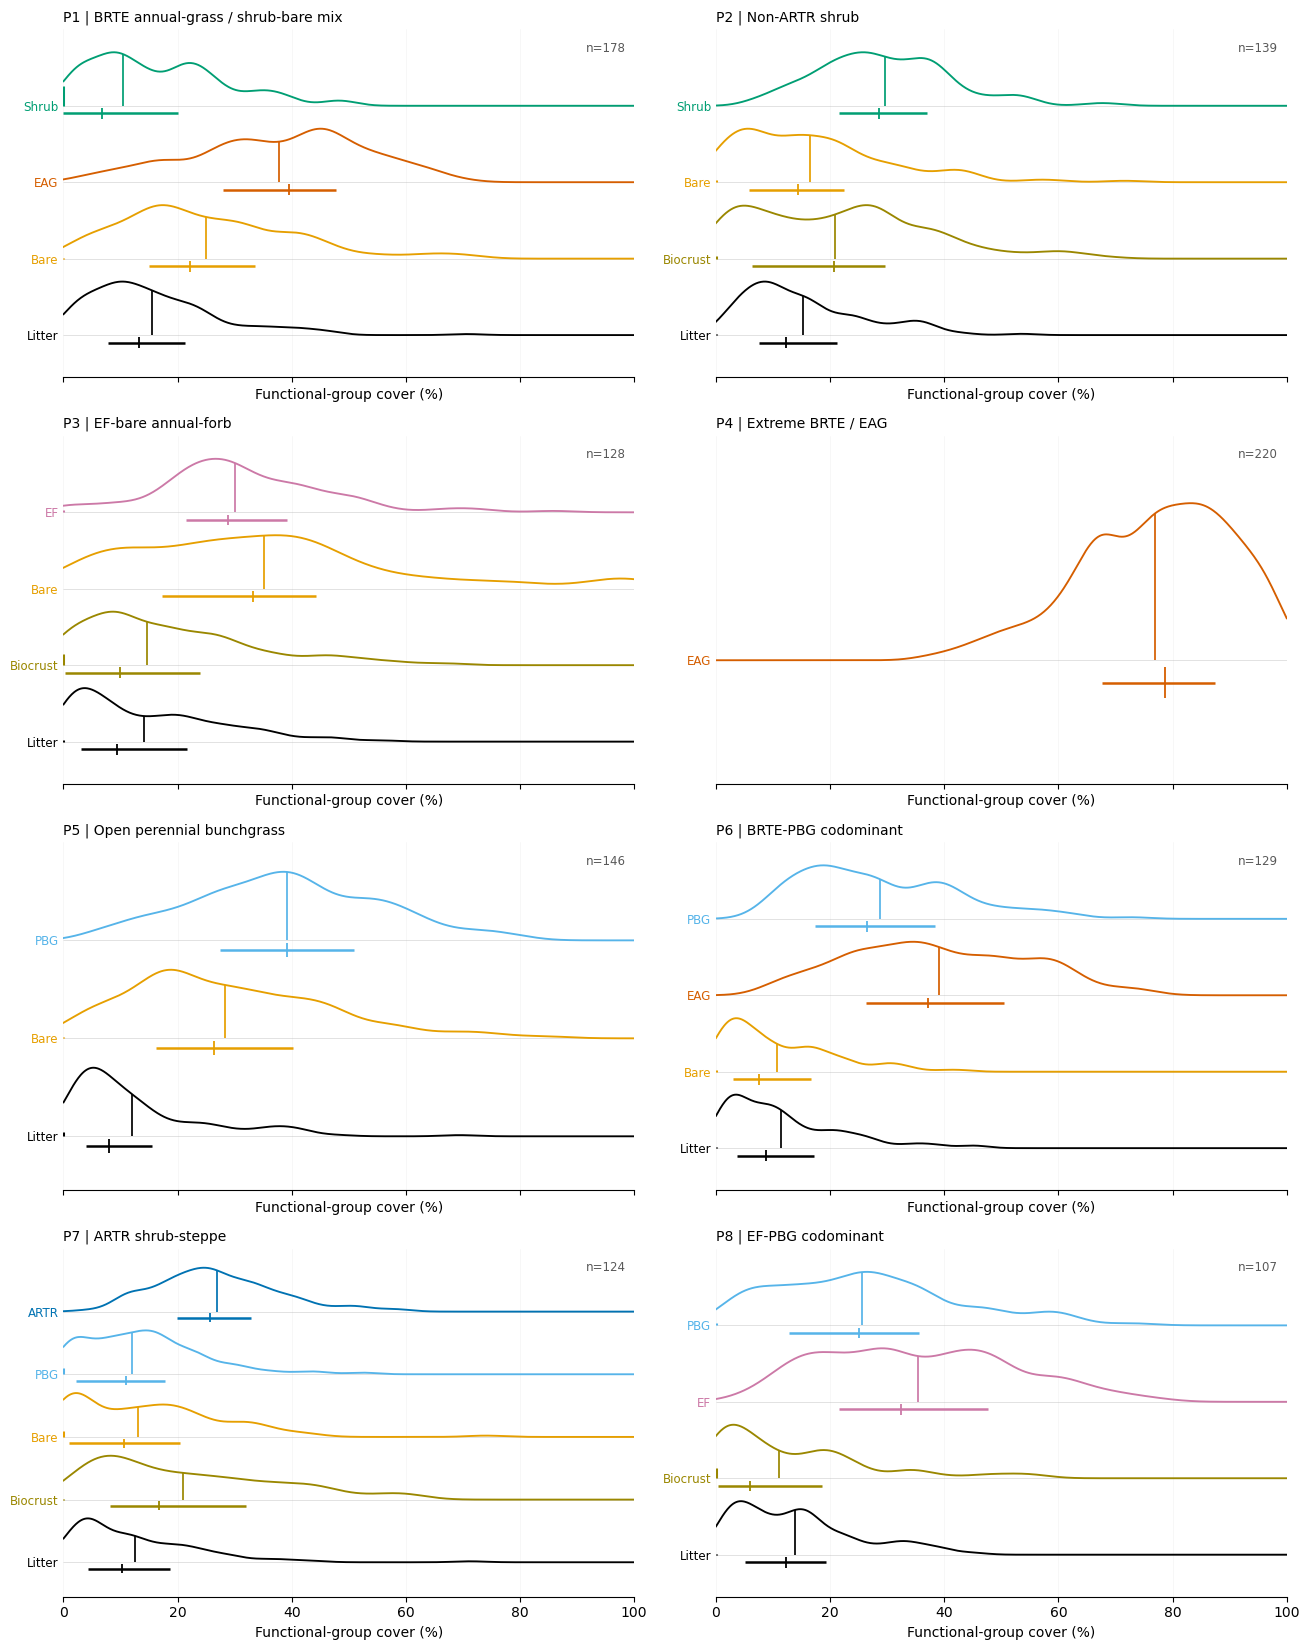

In [32]:

# =============================================================================
# 9. FIGURE 1 — PARENT CLUSTERS
# =============================================================================

parent_figs = tufte_ridge_atlas(
    veg_parent,
    group_col="parent_cluster",
    label_col="parent_label",
    fg_cols=RIDGE_FGS,
    mean_threshold=RIDGE_MEAN_THRESHOLD,
    bw_method=RIDGE_BW,
    ridge_height=0.70,
    ncols=2,
    panels_per_fig=8,
    n_placement=N_PLACEMENT_PARENT,
    figure_stem="Figure_01_Tufte_Parent_Clusters",
    panel_title_prefix="P",
)

plt.show()



## Figure 2 — final vegetation-state/subcluster Tufte ridges

The BG surface class is excluded because it is not a vegetation state. The plot uses all observations projected into each final vegetation state, while Table 3 separately reports the high-membership reference sample count.


Wrote: C:\NCA_DATA\Vegetation Data\Clustering_Veg\Figures\Figure_02_Tufte_Subclusters.pdf


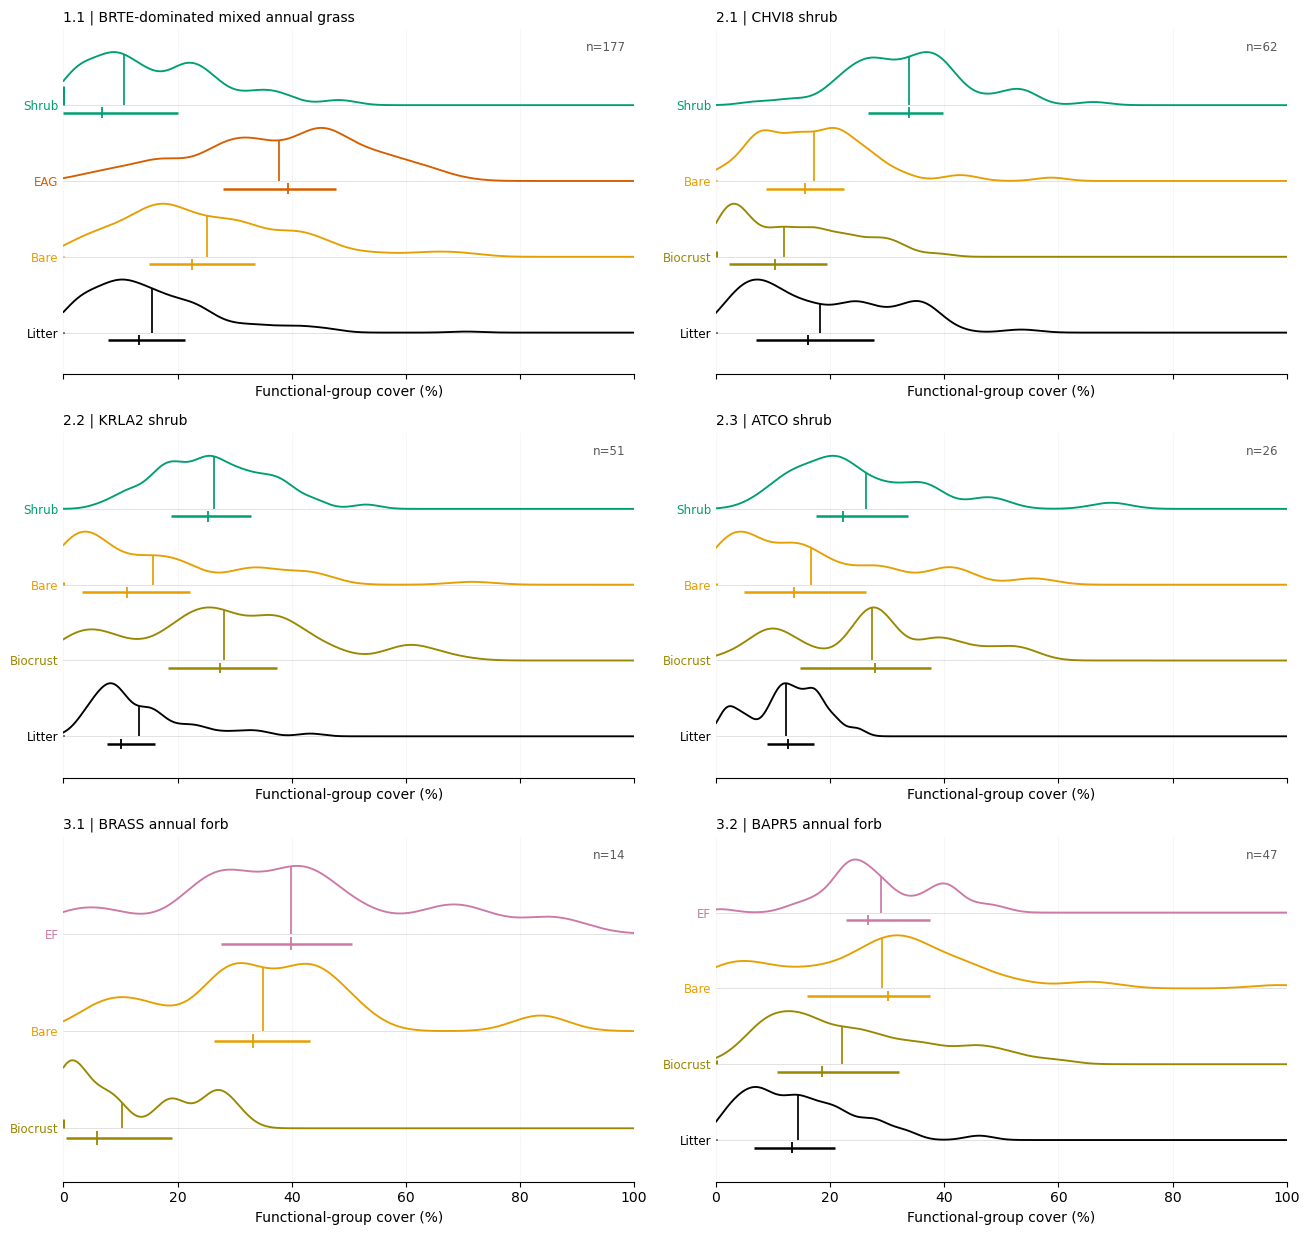

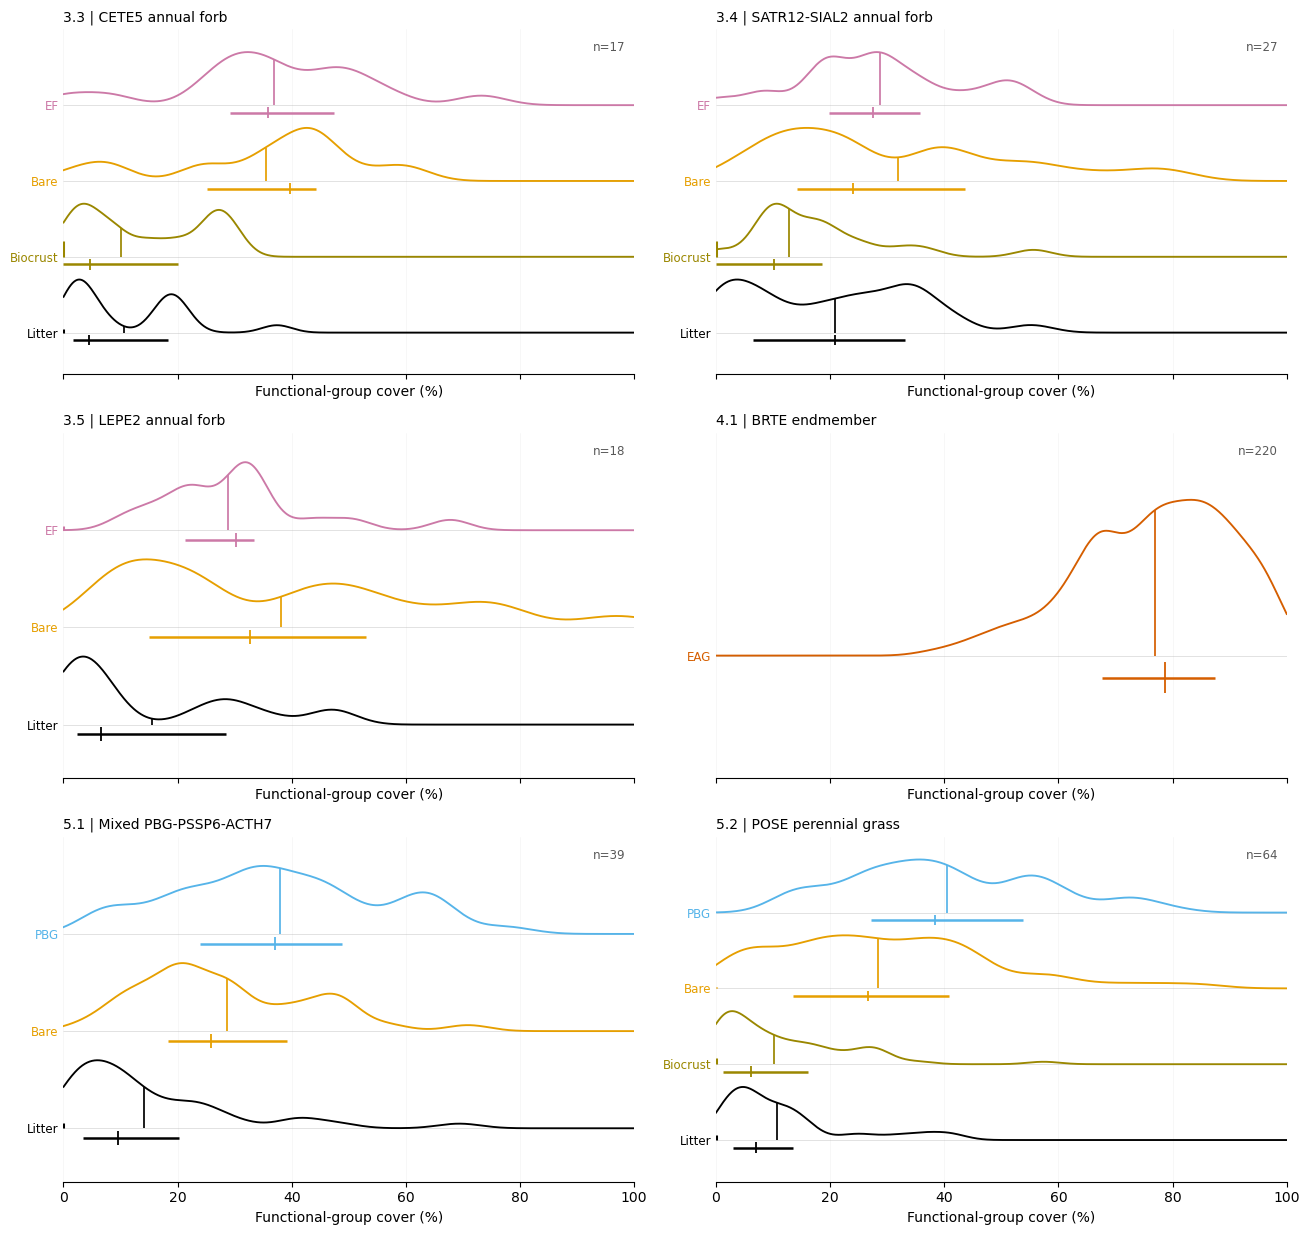

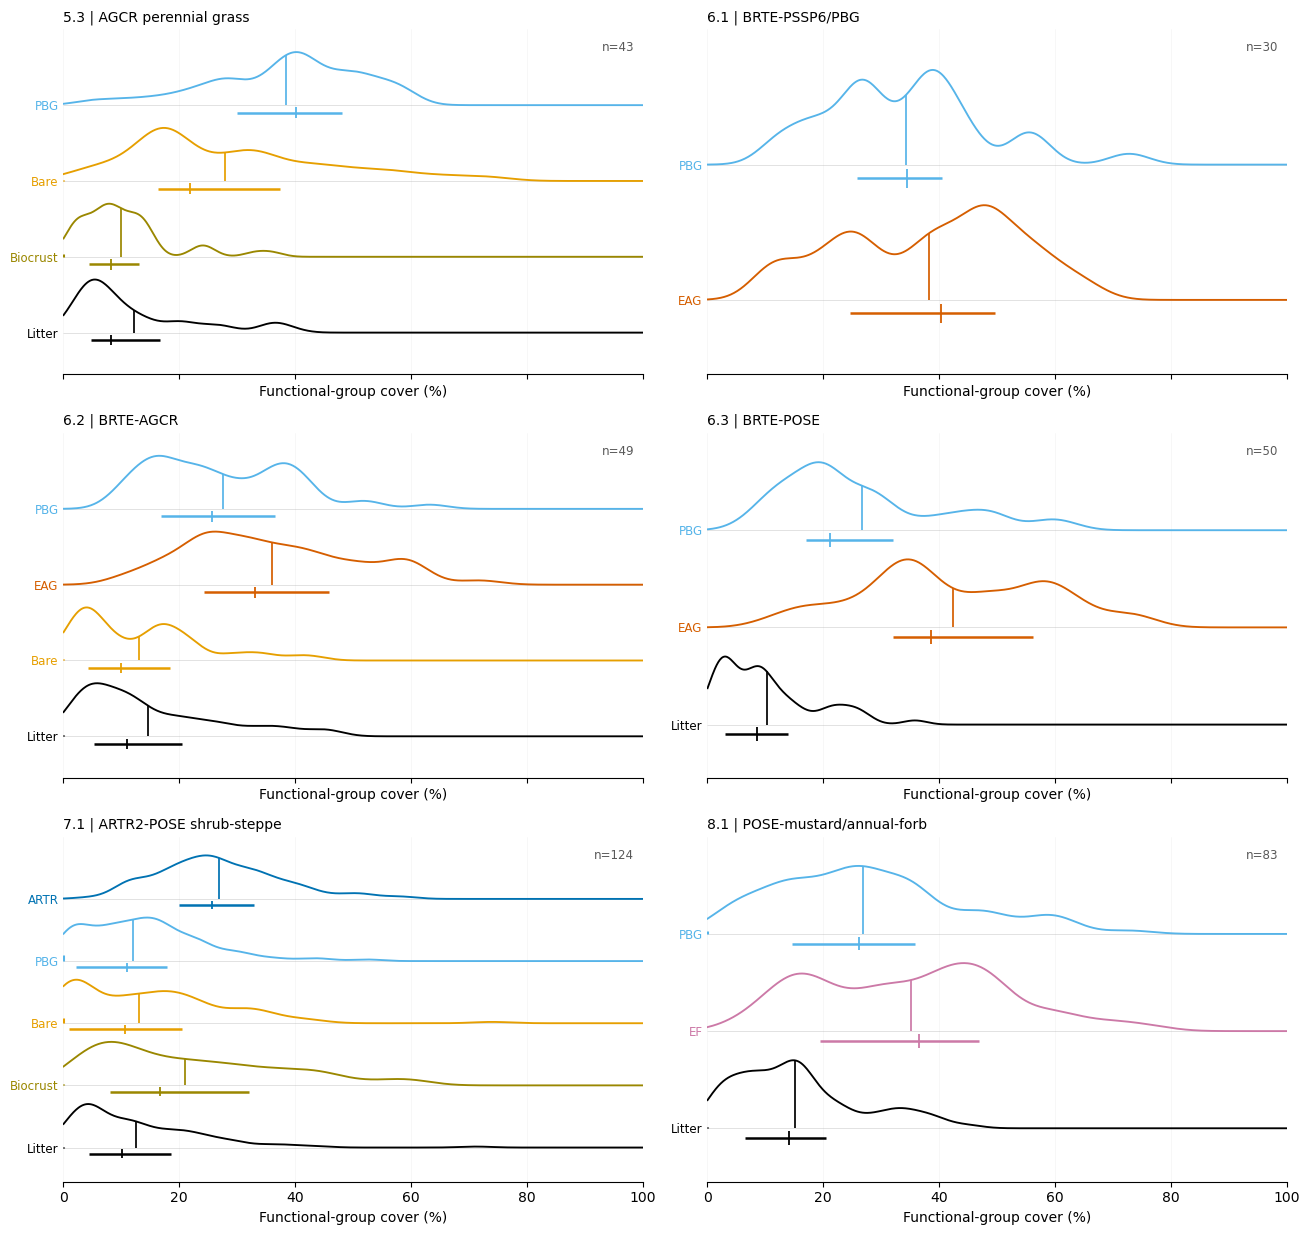

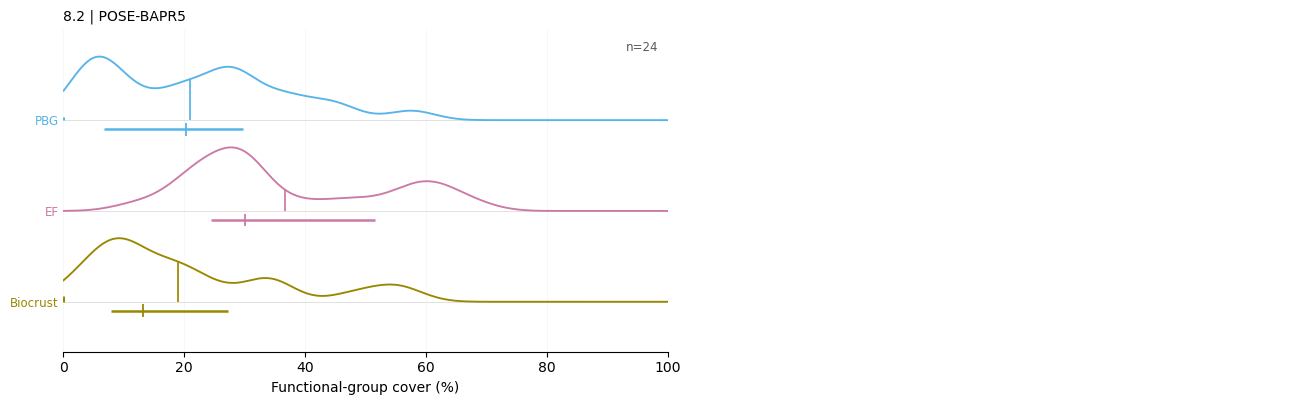

In [10]:

# =============================================================================
# 10. FIGURE 2 — FINAL VEGETATION SUBCLUSTERS / STATES
# =============================================================================

subcluster_figs = tufte_ridge_atlas(
    veg_only,
    group_col="state_id",
    label_col="state_label",
    fg_cols=RIDGE_FGS,
    mean_threshold=RIDGE_MEAN_THRESHOLD,
    bw_method=RIDGE_BW,
    ridge_height=0.70,
    ncols=2,
    panels_per_fig=6,
    n_placement=N_PLACEMENT_SUBCLUSTER,
    figure_stem="Figure_02_Tufte_Subclusters",
    panel_title_prefix="",
)

plt.show()


In [42]:
# =============================================================================
# PREVIEW ONLY: STACKED TUFTE RIDGES FOR PARENT CLUSTERS
# 2 columns x 4 rows, no export
# =============================================================================

from math import ceil
from scipy.stats import gaussian_kde


def preview_stacked_tufte_parent_ridges_grid(
    data,
    cluster_col="parent_cluster",
    label_col="parent_label",
    fg_cols=None,
    mean_threshold=10.0,
    x_max=100,
    x_ticks=np.arange(0, 101, 20),
    ncols=2,
    bw_method=0.25,
):
    if fg_cols is None:
        fg_cols = FG_ALL

    fg_pretty = {
        "ARTR_FG": "ARTR",
        "SHRUB_FG": "Shrub",
        "PBG_FG": "PBG",
        "EAG_FG": "EAG",
        "EF_FG": "EF",
        "BAREGROUND_FG": "Bare",
        "BIOCRUST_FG": "Biocrust",
        "LITTER_FG": "Litter",
        "OTHER_FG": "Other",
        "NPF_FG": "NPF",
    }

    # Okabe-Ito palette
    fg_colors = {
        "ARTR_FG": "#0072B2",
        "SHRUB_FG": "#009E73",
        "PBG_FG": "#56B4E9",
        "EAG_FG": "#D55E00",
        "EF_FG": "#CC79A7",
        "BAREGROUND_FG": "#E69F00",
        "BIOCRUST_FG": "#999000",
        "LITTER_FG": "#000000",
        "OTHER_FG": "#666666",
        "NPF_FG": "#444444",
    }

    parents = sorted(
        data[cluster_col]
        .dropna()
        .unique()
    )

    n_panels = len(parents)
    nrows = ceil(n_panels / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(12, 14),
        sharex=True,
    )

    axes = np.atleast_1d(axes).ravel()

    for ax, parent in zip(axes, parents):

        d = data.loc[
            data[cluster_col] == parent
        ].copy()

        parent_name = (
            d[label_col]
            .dropna()
            .iloc[0]
        )

        n_parent = len(d)

        # -------------------------------------------------------------
        # Display-only filtering by observed mean FG cover
        # -------------------------------------------------------------

        fg_means = (
            d[fg_cols]
            .apply(pd.to_numeric, errors="coerce")
            .mean()
        )

        if mean_threshold is None:
            keep_fgs = list(fg_cols)
        else:
            keep_fgs = [
                fg for fg in fg_cols
                if fg_means[fg] > mean_threshold
            ]

        if len(keep_fgs) == 0:
            keep_fgs = [fg_means.idxmax()]

        # Higher FG appears higher in panel
        offsets = (
            np.arange(len(keep_fgs))[::-1]
            * 1.10
        )

        for offset, fg in zip(
            offsets,
            keep_fgs,
        ):

            x = (
                pd.to_numeric(
                    d[fg],
                    errors="coerce"
                )
                .dropna()
                .to_numpy(dtype=float)
            )

            if len(x) == 0:
                continue

            color = fg_colors.get(
                fg,
                "black"
            )

            # ---------------------------------------------------------
            # Thin baseline
            # ---------------------------------------------------------

            ax.hlines(
                offset,
                0,
                x_max,
                color="0.86",
                linewidth=0.7,
                zorder=0,
            )

            # ---------------------------------------------------------
            # Positive-cover KDE
            # ---------------------------------------------------------

            positive = x[x > 0]

            xx = np.linspace(
                0.01,
                x_max,
                600
            )

            ridge = None
            yy_raw = None

            if (
                len(positive) >= 5
                and len(np.unique(positive)) >= 3
            ):
                try:
                    kde = gaussian_kde(
                        positive,
                        bw_method=bw_method
                    )

                    yy_raw = kde(xx)

                    if (
                        np.isfinite(yy_raw).all()
                        and yy_raw.max() > 0
                    ):
                        yy = (
                            yy_raw
                            / yy_raw.max()
                        )

                        ridge = offset + yy

                        # Line only — no fill
                        ax.plot(
                            xx,
                            ridge,
                            color=color,
                            linewidth=1.6,
                            zorder=3,
                        )

                except np.linalg.LinAlgError:
                    ridge = None

            # ---------------------------------------------------------
            # Explicit zero mass
            # ---------------------------------------------------------

            zero_fraction = np.mean(
                x == 0
            )

            if zero_fraction > 0:
                ax.vlines(
                    0,
                    offset,
                    offset + zero_fraction,
                    color=color,
                    linewidth=2.0,
                    zorder=4,
                    clip_on=False,
                )

            # ---------------------------------------------------------
            # IQR + median from complete observed distribution
            # ---------------------------------------------------------

            q25, median, q75 = np.quantile(
                x,
                [0.25, 0.50, 0.75]
            )

            ax.hlines(
                offset - 0.10,
                q25,
                q75,
                color=color,
                linewidth=1.6,
                zorder=5,
            )

            ax.vlines(
                median,
                offset - 0.17,
                offset - 0.03,
                color=color,
                linewidth=1.2,
                zorder=5,
            )

            # ---------------------------------------------------------
            # Mean line — baseline to top of its own KDE curve
            # ---------------------------------------------------------

            mean_x = float(np.mean(x))

            if ridge is not None:
                mean_top = float(
                    np.interp(
                        mean_x,
                        xx,
                        ridge
                    )
                )
            else:
                mean_top = (
                    offset + 0.16
                )

            ax.vlines(
                mean_x,
                offset,
                mean_top,
                color=color,
                linewidth=1.3,
                zorder=6,
            )

            # ---------------------------------------------------------
            # Direct FG label
            # ---------------------------------------------------------

            ax.text(
                -2.5,
                offset,
                fg_pretty.get(
                    fg,
                    fg
                ),
                ha="right",
                va="center",
                fontsize=9.5,
                color=color,
            )

        # -------------------------------------------------------------
        # Panel formatting
        # -------------------------------------------------------------

        ax.set_xlim(
            0,
            x_max
        )

        ax.set_xticks(
            x_ticks
        )

        ax.set_xticklabels(
            [
                str(int(t))
                for t in x_ticks
            ]
        )

        # Force labels on every panel despite sharex=True
        ax.tick_params(
            axis="x",
            labelbottom=True
        )

        ax.set_yticks([])

        ax.set_ylim(
            -0.45,
            offsets.max() + 1.10
        )

        ax.set_title(
            f"P{parent} | {parent_name}",
            loc="left",
            fontsize=11.5,
            pad=6,
        )

        ax.text(
            0.98,
            0.94,
            f"n={n_parent}",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=9,
            color="0.35",
        )

        ax.set_xlabel(
            "Functional-group cover (%)",
            fontsize=9.5,
        )

        # Tufte-style reduction of non-data ink
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(False)

        ax.tick_params(
            axis="y",
            length=0
        )

        ax.grid(
            axis="x",
            linewidth=0.45,
            alpha=0.12,
        )

    # Hide unused axes if necessary
    for ax in axes[n_panels:]:
        ax.axis("off")

    fig.suptitle(
        "Preview: stacked Tufte ridge plots for parent clusters",
        fontsize=14,
        y=0.995,
    )

    fig.tight_layout()

    # PREVIEW ONLY — no savefig()
    plt.show()

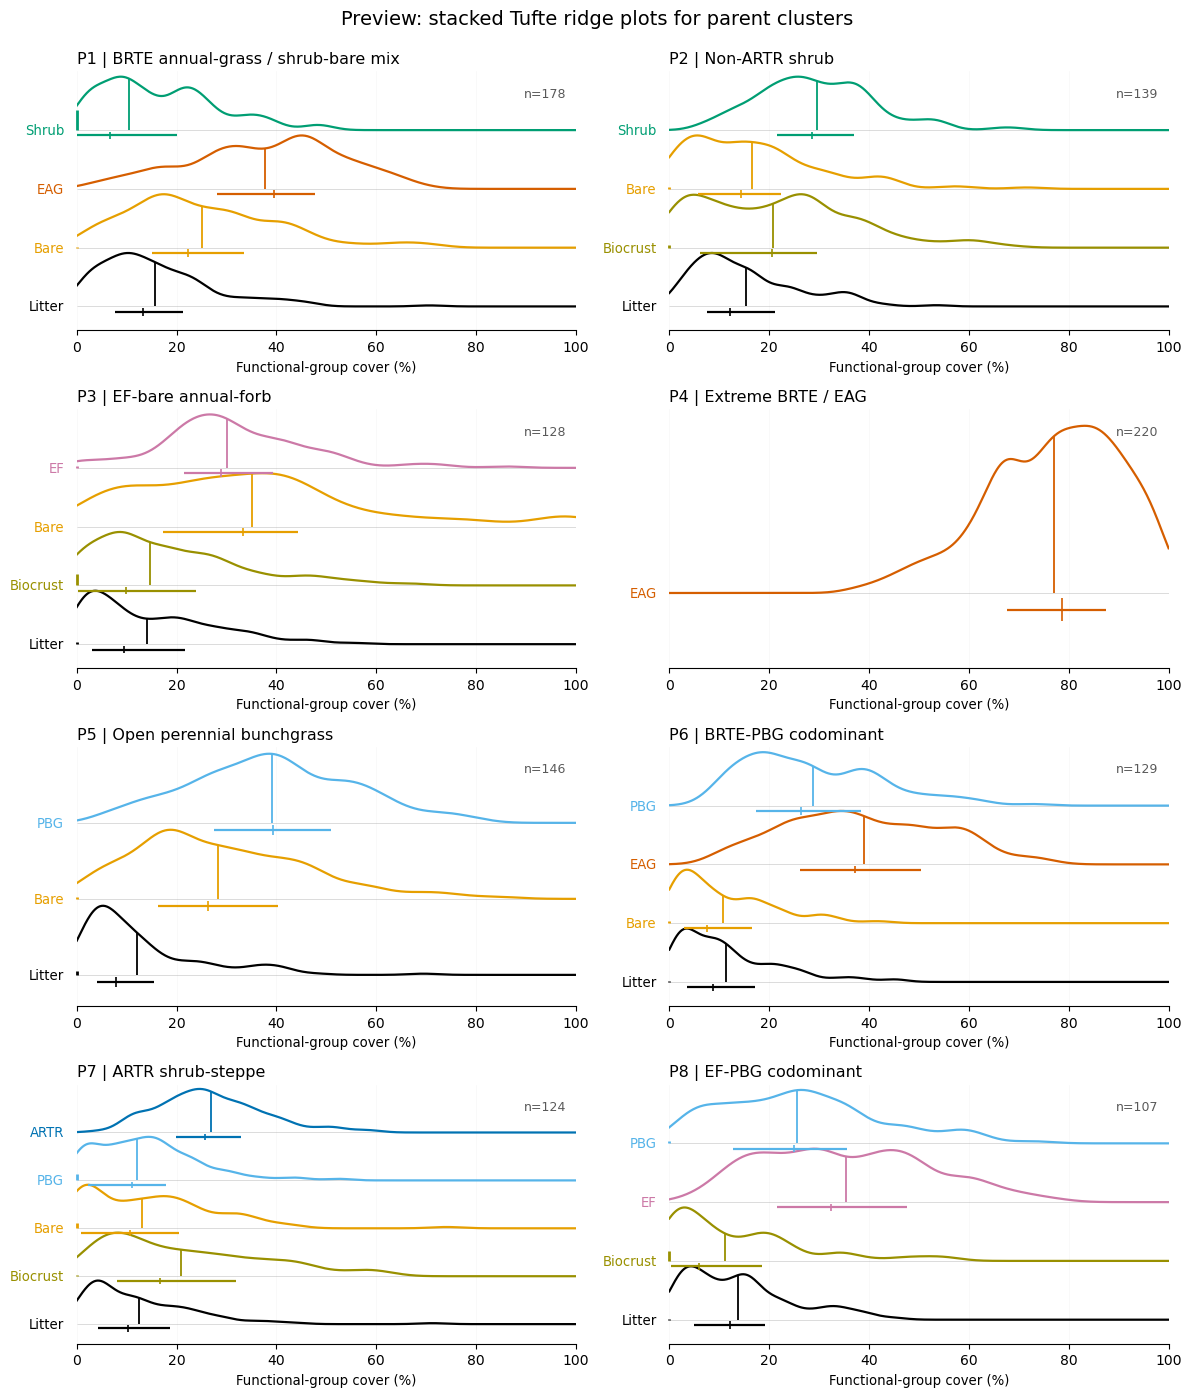

In [44]:
preview_stacked_tufte_parent_ridges_grid(
    data=veg_parent,
    cluster_col="parent_cluster",
    label_col="parent_label",
    fg_cols=FG_ALL,
    mean_threshold=10.0,
    bw_method=0.25,
)

In [51]:
# =============================================================================
# PREVIEW ONLY: OVERLAID SINGLE-BASELINE TUFTE DENSITIES
# 2 columns x 4 rows
# Taller panels + legends outside plotting region
# NO EXPORT
# =============================================================================

from math import ceil
from scipy.stats import gaussian_kde
from matplotlib.lines import Line2D


def preview_overlaid_tufte_parent_densities_v2(
    data,
    cluster_col="parent_cluster",
    label_col="parent_label",
    fg_cols=None,
    mean_threshold=10.0,
    x_max=100,
    x_ticks=np.arange(0, 101, 20),
    ncols=2,
    bw_method=0.25,
    show_iqr=True,
    show_zero_ticks=True,
):

    if fg_cols is None:
        fg_cols = FG_ALL

    fg_pretty = {
        "ARTR_FG": "ARTR",
        "SHRUB_FG": "Shrub",
        "PBG_FG": "PBG",
        "EAG_FG": "EAG",
        "EF_FG": "EF",
        "BAREGROUND_FG": "Bare",
        "BIOCRUST_FG": "Biocrust",
        "LITTER_FG": "Litter",
        "OTHER_FG": "Other",
        "NPF_FG": "NPF",
    }

    # Okabe-Ito
    fg_colors = {
        "ARTR_FG": "#0072B2",
        "SHRUB_FG": "#009E73",
        "PBG_FG": "#56B4E9",
        "EAG_FG": "#D55E00",
        "EF_FG": "#CC79A7",
        "BAREGROUND_FG": "#E69F00",
        "BIOCRUST_FG": "#999000",
        "LITTER_FG": "#000000",
        "OTHER_FG": "#666666",
        "NPF_FG": "#444444",
    }

    parents = sorted(
        data[cluster_col]
        .dropna()
        .unique()
    )

    n_panels = len(parents)
    nrows = ceil(n_panels / ncols)

    # Taller than previous version
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(13, 17),
        sharex=True,
        sharey=False,
    )

    axes = np.atleast_1d(axes).ravel()

    xx = np.linspace(
        0.01,
        x_max,
        700
    )

    for ax, parent in zip(axes, parents):

        d = data.loc[
            data[cluster_col] == parent
        ].copy()

        parent_name = (
            d[label_col]
            .dropna()
            .iloc[0]
        )

        n_parent = len(d)

        # -------------------------------------------------------------
        # Display-only FG filter
        # -------------------------------------------------------------

        fg_means = (
            d[fg_cols]
            .apply(pd.to_numeric, errors="coerce")
            .mean()
        )

        if mean_threshold is None:
            keep_fgs = list(fg_cols)
        else:
            keep_fgs = [
                fg for fg in fg_cols
                if fg_means[fg] > mean_threshold
            ]

        if len(keep_fgs) == 0:
            keep_fgs = [fg_means.idxmax()]

        # -------------------------------------------------------------
        # Shared baseline
        # -------------------------------------------------------------

        ax.axhline(
            0,
            color="0.80",
            linewidth=0.8,
            zorder=0
        )

        # IQR bars occupy separate shallow rows below baseline
        if show_iqr:
            iqr_offsets = np.linspace(
                -0.10,
                -0.30,
                len(keep_fgs)
            )

        legend_handles = []

        # -------------------------------------------------------------
        # Functional-group distributions
        # -------------------------------------------------------------

        for i, fg in enumerate(keep_fgs):

            x = (
                pd.to_numeric(
                    d[fg],
                    errors="coerce"
                )
                .dropna()
                .to_numpy(dtype=float)
            )

            if len(x) == 0:
                continue

            color = fg_colors[fg]

            positive = x[x > 0]

            ridge_drawn = False
            yy_scaled = None

            if (
                len(positive) >= 5
                and len(np.unique(positive)) >= 3
            ):
                try:
                    kde = gaussian_kde(
                        positive,
                        bw_method=bw_method
                    )

                    yy_raw = kde(xx)

                    if (
                        np.isfinite(yy_raw).all()
                        and yy_raw.max() > 0
                    ):
                        yy_scaled = (
                            yy_raw /
                            yy_raw.max()
                        )

                        ax.plot(
                            xx,
                            yy_scaled,
                            color=color,
                            linewidth=1.7,
                            alpha=0.97,
                            zorder=3,
                        )

                        ridge_drawn = True

                except np.linalg.LinAlgError:
                    pass

            # ---------------------------------------------------------
            # Mean line
            # ---------------------------------------------------------

            mean_x = float(
                np.mean(x)
            )

            if ridge_drawn:
                mean_top = float(
                    np.interp(
                        mean_x,
                        xx,
                        yy_scaled
                    )
                )
            else:
                mean_top = 0.15

            ax.vlines(
                mean_x,
                0,
                mean_top,
                color=color,
                linewidth=1.25,
                zorder=4,
            )

            # ---------------------------------------------------------
            # Explicit zero mass
            # ---------------------------------------------------------

            if show_zero_ticks:

                zero_fraction = np.mean(
                    x == 0
                )

                if zero_fraction > 0:
                    ax.vlines(
                        0,
                        0,
                        min(zero_fraction, 0.24),
                        color=color,
                        linewidth=2.0,
                        zorder=5,
                        clip_on=False,
                    )

            # ---------------------------------------------------------
            # IQR + median below baseline
            # ---------------------------------------------------------

            if show_iqr:

                q25, median, q75 = np.quantile(
                    x,
                    [0.25, 0.50, 0.75]
                )

                y_iqr = iqr_offsets[i]

                ax.hlines(
                    y_iqr,
                    q25,
                    q75,
                    color=color,
                    linewidth=1.6,
                    zorder=4,
                )

                ax.vlines(
                    median,
                    y_iqr - 0.027,
                    y_iqr + 0.027,
                    color=color,
                    linewidth=1.15,
                    zorder=4,
                )

            legend_handles.append(
                Line2D(
                    [0],
                    [0],
                    color=color,
                    lw=2,
                    label=fg_pretty[fg],
                )
            )

        # -------------------------------------------------------------
        # Axes
        # -------------------------------------------------------------

        ax.set_xlim(
            0,
            x_max
        )

        ax.set_xticks(
            x_ticks
        )

        ax.set_xticklabels(
            [str(int(t)) for t in x_ticks]
        )

        ax.tick_params(
            axis="x",
            labelbottom=True,
            labelsize=9
        )

        # Slightly more vertical space for the density shape itself
        ax.set_ylim(
            -0.36,
            1.10
        )

        ax.set_yticks([])

        ax.set_xlabel(
            "Functional-group cover (%)",
            fontsize=9.5,
        )

        # -------------------------------------------------------------
        # Panel header
        # -------------------------------------------------------------

        ax.set_title(
            f"P{parent} | {parent_name}",
            loc="left",
            fontsize=12,
            pad=35,
        )

        # Legend OUTSIDE plotting region
        ax.legend(
            handles=legend_handles,
            frameon=False,
            loc="lower left",
            bbox_to_anchor=(0.0, 1.015),
            borderaxespad=0,
            ncol=len(legend_handles),   # force one row
            fontsize=8.0,
            handlelength=1.5,
            handletextpad=0.35,
            columnspacing=0.75,
        )

        # Sample size in same header strip
        ax.text(
            1.0,
            1.035,
            f"n={n_parent}",
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=9,
            color="0.35",
            clip_on=False,
        )

        # -------------------------------------------------------------
        # Minimal styling
        # -------------------------------------------------------------

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(False)

        ax.grid(
            axis="x",
            linewidth=0.45,
            alpha=0.12,
        )

    # unused axes
    for ax in axes[n_panels:]:
        ax.axis("off")

    fig.suptitle(
        "Functional-group distributions by parent cluster",
        fontsize=15,
        y=0.998,
    )

    # More vertical separation to accommodate external legends
    fig.subplots_adjust(
        top=0.94,
        bottom=0.05,
        left=0.06,
        right=0.985,
        hspace=0.62,
        wspace=0.18,
    )

    # PREVIEW ONLY
    plt.show()

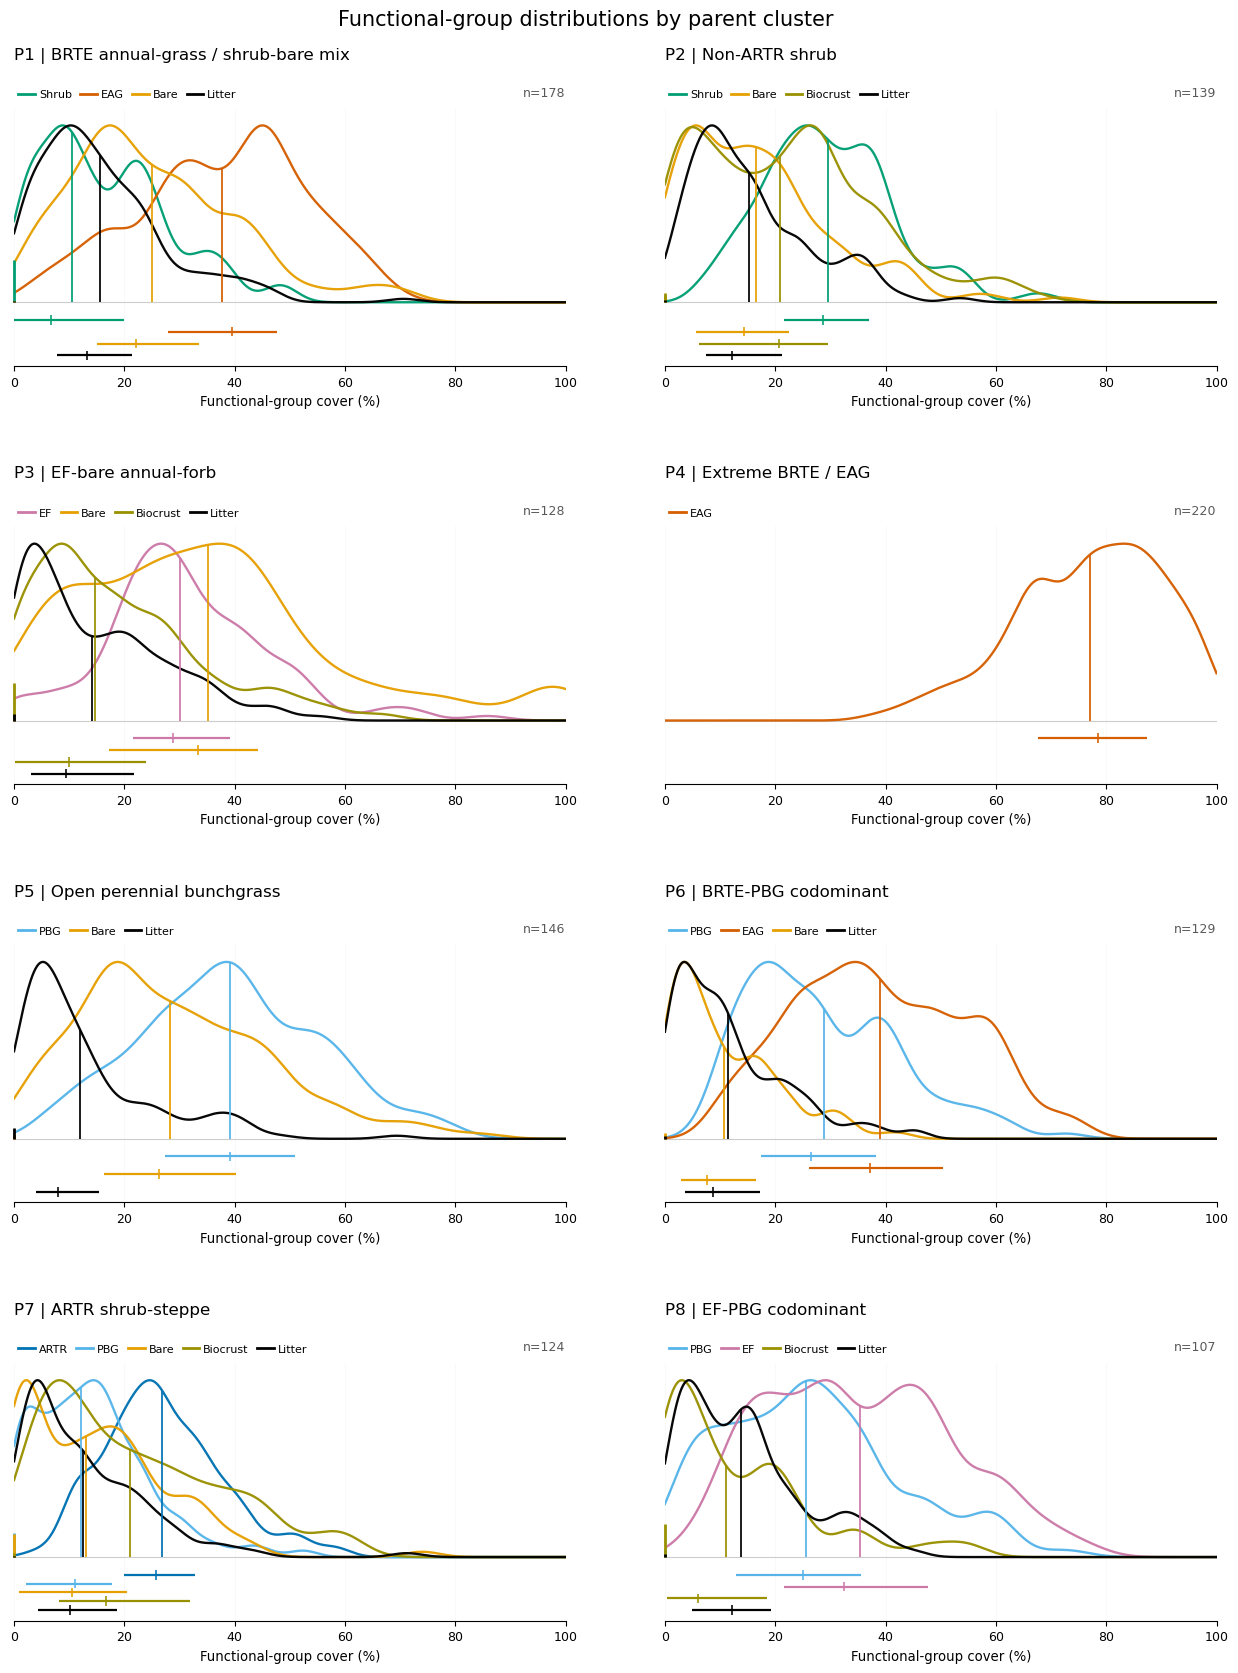

In [52]:
preview_overlaid_tufte_parent_densities_v2(
    data=veg_parent,
    cluster_col="parent_cluster",
    label_col="parent_label",
    fg_cols=FG_ALL,
    mean_threshold=10.0,
    bw_method=0.25,
)

In [53]:
# =============================================================================
# OVERLAID SINGLE-BASELINE TUFTE DENSITIES BY PARENT CLUSTER
# SINGLE-COLUMN VERSION: wider + shorter panels
# PREVIEW ONLY
# =============================================================================

from math import ceil
from scipy.stats import gaussian_kde
from matplotlib.lines import Line2D


def preview_overlaid_tufte_parent_densities_singlecol(
    data,
    cluster_col="parent_cluster",
    label_col="parent_label",
    fg_cols=None,
    mean_threshold=10.0,
    x_max=100,
    x_ticks=np.arange(0, 101, 20),
    ncols=1,
    bw_method=0.25,
    show_iqr=True,
    show_zero_ticks=True,
):

    if fg_cols is None:
        fg_cols = FG_ALL

    fg_pretty = {
        "ARTR_FG": "ARTR",
        "SHRUB_FG": "Shrub",
        "PBG_FG": "PBG",
        "EAG_FG": "EAG",
        "EF_FG": "EF",
        "BAREGROUND_FG": "Bare",
        "BIOCRUST_FG": "BSC",
        "LITTER_FG": "Litter",
        "OTHER_FG": "Other",
        "NPF_FG": "NPF",
    }

    # Updated palette: Bare and BSC separated more clearly
    fg_colors = {
        "ARTR_FG": "#0072B2",        # blue
        "SHRUB_FG": "#009E73",       # green
        "PBG_FG": "#56B4E9",         # sky blue
        "EAG_FG": "#D55E00",         # vermillion
        "EF_FG": "#CC79A7",          # magenta
        "BAREGROUND_FG": "#8C564B",  # brown
        "BIOCRUST_FG": "#6B8E23",    # olive green
        "LITTER_FG": "#000000",      # black
        "OTHER_FG": "#666666",
        "NPF_FG": "#444444",
    }

    parents = sorted(
        data[cluster_col]
        .dropna()
        .unique()
    )

    n_panels = len(parents)
    nrows = ceil(n_panels / ncols)

    # Wider and shorter panels
    panel_width = 13
    panel_height = 2.25

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(panel_width, panel_height * nrows + 1.0),
        sharex=True,
        sharey=False,
    )

    axes = np.atleast_1d(axes).ravel()

    xx = np.linspace(0.01, x_max, 700)

    for ax, parent in zip(axes, parents):

        d = data.loc[
            data[cluster_col] == parent
        ].copy()

        parent_name = (
            d[label_col]
            .dropna()
            .iloc[0]
        )

        n_parent = len(d)

        fg_means = (
            d[fg_cols]
            .apply(pd.to_numeric, errors="coerce")
            .mean()
        )

        if mean_threshold is None:
            keep_fgs = list(fg_cols)
        else:
            keep_fgs = [
                fg for fg in fg_cols
                if fg_means[fg] > mean_threshold
            ]

        if len(keep_fgs) == 0:
            keep_fgs = [fg_means.idxmax()]

        # shared baseline
        ax.axhline(
            0,
            color="0.82",
            linewidth=0.8,
            zorder=0
        )

        if show_iqr:
            iqr_offsets = np.linspace(
                -0.08,
                -0.22,
                len(keep_fgs)
            )

        legend_handles = []

        for i, fg in enumerate(keep_fgs):

            x = (
                pd.to_numeric(
                    d[fg],
                    errors="coerce"
                )
                .dropna()
                .to_numpy(dtype=float)
            )

            if len(x) == 0:
                continue

            color = fg_colors[fg]
            positive = x[x > 0]

            ridge_drawn = False
            yy_scaled = None

            if (
                len(positive) >= 5
                and len(np.unique(positive)) >= 3
            ):
                try:
                    kde = gaussian_kde(
                        positive,
                        bw_method=bw_method
                    )

                    yy_raw = kde(xx)

                    if (
                        np.isfinite(yy_raw).all()
                        and yy_raw.max() > 0
                    ):
                        yy_scaled = yy_raw / yy_raw.max()

                        ax.plot(
                            xx,
                            yy_scaled,
                            color=color,
                            linewidth=1.7,
                            alpha=0.97,
                            zorder=3,
                        )

                        ridge_drawn = True

                except np.linalg.LinAlgError:
                    pass

            mean_x = float(np.mean(x))

            if ridge_drawn:
                mean_top = float(
                    np.interp(
                        mean_x,
                        xx,
                        yy_scaled
                    )
                )
            else:
                mean_top = 0.15

            ax.vlines(
                mean_x,
                0,
                mean_top,
                color=color,
                linewidth=1.25,
                zorder=4,
            )

            if show_zero_ticks:
                zero_fraction = np.mean(x == 0)
                if zero_fraction > 0:
                    ax.vlines(
                        0,
                        0,
                        min(zero_fraction, 0.20),
                        color=color,
                        linewidth=2.0,
                        zorder=5,
                        clip_on=False,
                    )

            if show_iqr:
                q25, median, q75 = np.quantile(
                    x,
                    [0.25, 0.50, 0.75]
                )

                y_iqr = iqr_offsets[i]

                ax.hlines(
                    y_iqr,
                    q25,
                    q75,
                    color=color,
                    linewidth=1.5,
                    zorder=4,
                )

                ax.vlines(
                    median,
                    y_iqr - 0.020,
                    y_iqr + 0.020,
                    color=color,
                    linewidth=1.1,
                    zorder=4,
                )

            legend_handles.append(
                Line2D(
                    [0],
                    [0],
                    color=color,
                    lw=2,
                    label=fg_pretty[fg],
                )
            )

        ax.set_xlim(0, x_max)
        ax.set_xticks(x_ticks)
        ax.set_xticklabels([str(int(t)) for t in x_ticks])
        ax.tick_params(axis="x", labelbottom=True, labelsize=9)

        ax.set_ylim(-0.27, 1.05)
        ax.set_yticks([])

        ax.set_xlabel(
            "Functional-group cover (%)",
            fontsize=9.5,
        )

        ax.set_title(
            f"P{parent} | {parent_name}",
            loc="left",
            fontsize=12,
            pad=28,
        )

        ax.legend(
            handles=legend_handles,
            frameon=False,
            loc="lower left",
            bbox_to_anchor=(0.0, 1.01),
            borderaxespad=0,
            ncol=len(legend_handles),
            fontsize=8.2,
            handlelength=1.5,
            handletextpad=0.35,
            columnspacing=0.8,
        )

        ax.text(
            1.0,
            1.02,
            f"n={n_parent}",
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=9,
            color="0.35",
            clip_on=False,
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(False)

        ax.grid(
            axis="x",
            linewidth=0.45,
            alpha=0.12,
        )

    for ax in axes[n_panels:]:
        ax.axis("off")

    fig.suptitle(
        "Functional-group distributions by parent cluster",
        fontsize=15,
        y=0.998,
    )

    fig.subplots_adjust(
        top=0.965,
        bottom=0.04,
        left=0.07,
        right=0.985,
        hspace=0.55,
    )

    plt.show()

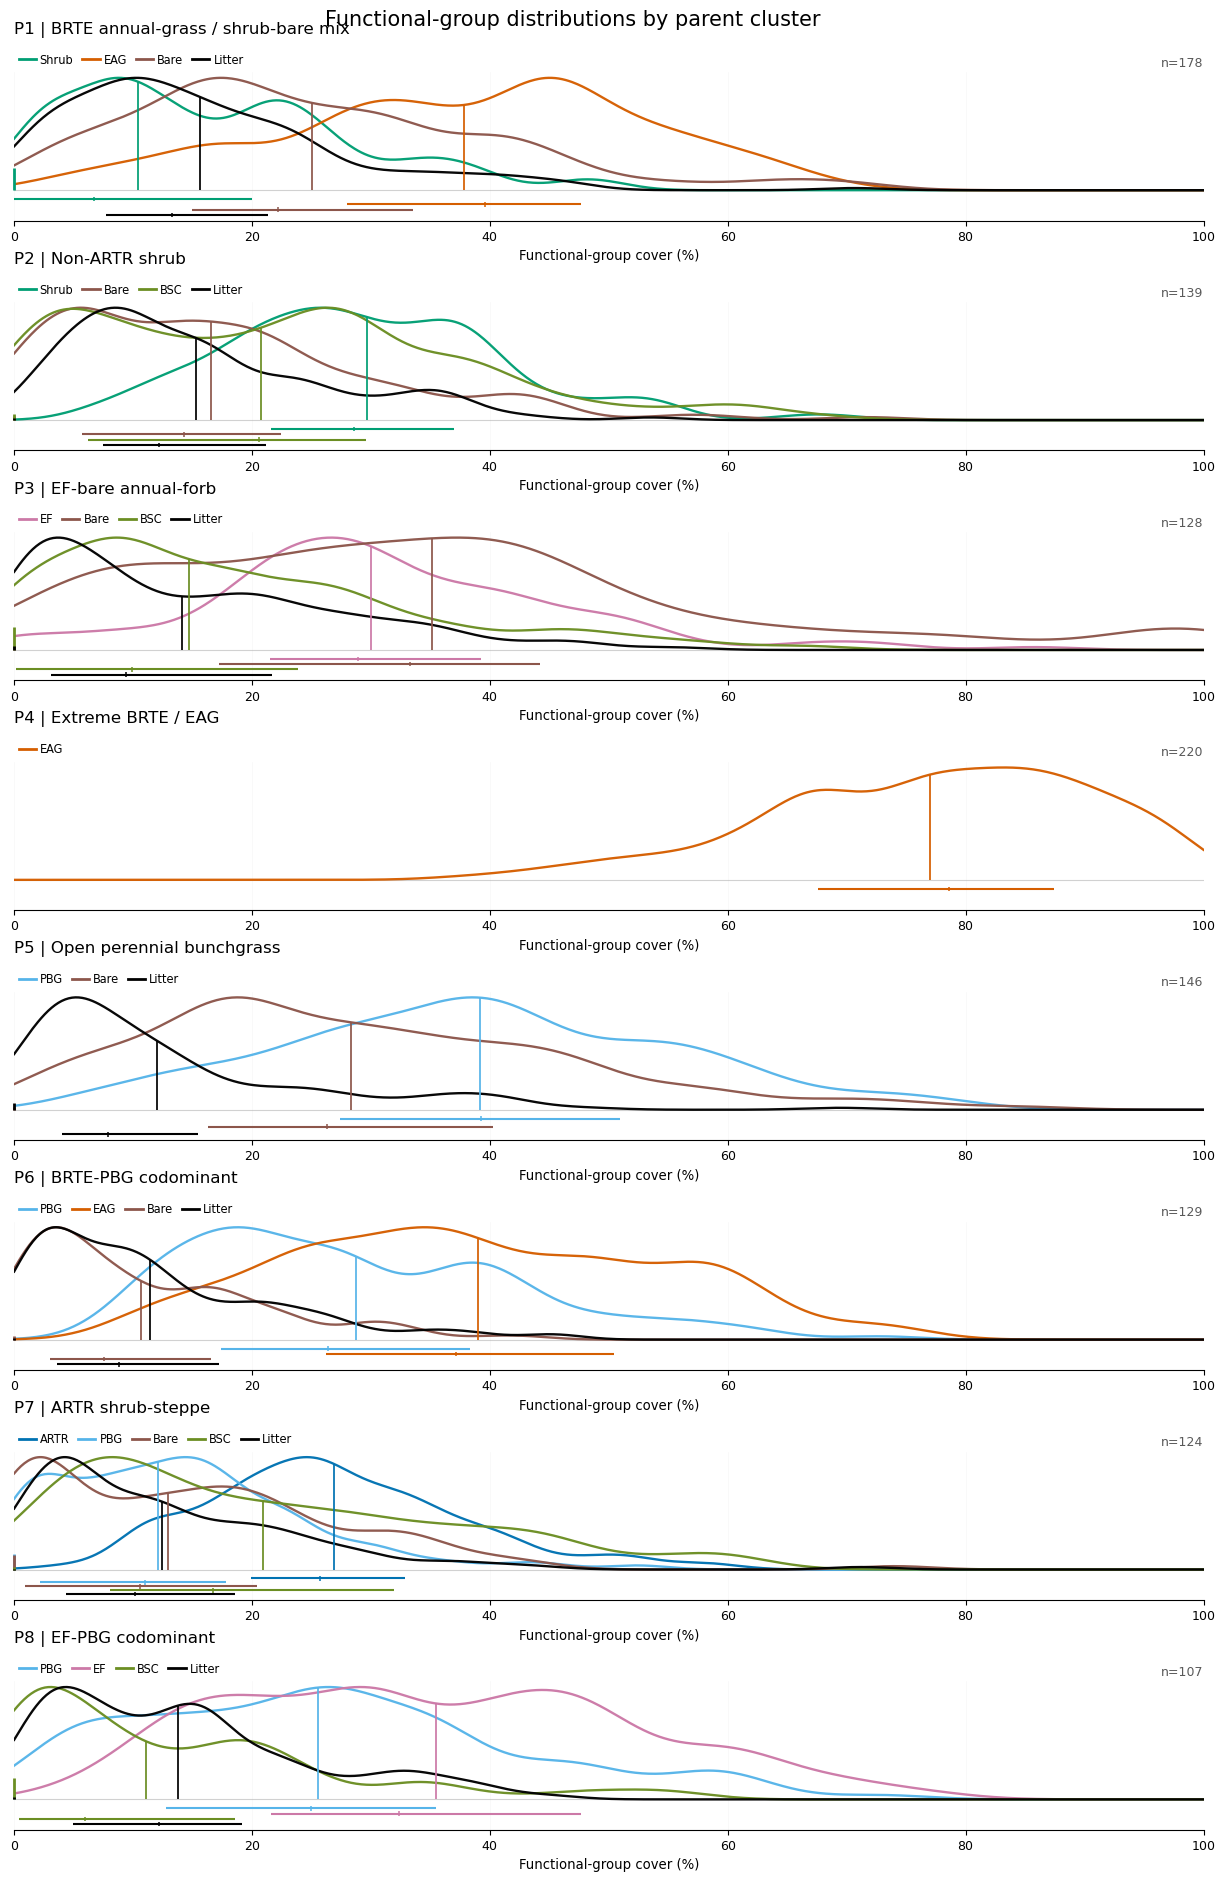

In [54]:
preview_overlaid_tufte_parent_densities_singlecol(
    data=veg_parent,
    cluster_col="parent_cluster",
    label_col="parent_label",
    fg_cols=FG_ALL,
    mean_threshold=10.0,
    bw_method=0.25,
)

In [55]:
# =============================================================================
# OVERLAID SINGLE-BASELINE TUFTE DENSITIES BY SUBCLUSTER / STATE
# SINGLE-COLUMN VERSION
# PREVIEW ONLY
# =============================================================================

from math import ceil
from scipy.stats import gaussian_kde
from matplotlib.lines import Line2D


def preview_overlaid_tufte_state_densities_singlecol(
    data,
    cluster_col="state_id",
    label_col="state_label",
    fg_cols=None,
    state_type_col="state_type",
    exclude_nonvegetated=True,
    mean_threshold=10.0,
    x_max=100,
    x_ticks=np.arange(0, 101, 20),
    ncols=1,
    bw_method=0.25,
    show_iqr=True,
    show_zero_ticks=True,
    panel_width=13,
    panel_height=2.10,
):

    if fg_cols is None:
        fg_cols = FG_ALL

    fg_pretty = {
        "ARTR_FG": "ARTR",
        "SHRUB_FG": "Shrub",
        "PBG_FG": "PBG",
        "EAG_FG": "EAG",
        "EF_FG": "EF",
        "BAREGROUND_FG": "Bare",
        "BIOCRUST_FG": "BSC",
        "LITTER_FG": "Litter",
        "OTHER_FG": "Other",
        "NPF_FG": "NPF",
    }

    # Updated palette with better separation for Bare vs BSC
    fg_colors = {
        "ARTR_FG": "#0072B2",        # blue
        "SHRUB_FG": "#009E73",       # green
        "PBG_FG": "#56B4E9",         # sky blue
        "EAG_FG": "#D55E00",         # vermillion
        "EF_FG": "#CC79A7",          # magenta
        "BAREGROUND_FG": "#8C564B",  # brown
        "BIOCRUST_FG": "#6B8E23",    # olive
        "LITTER_FG": "#000000",      # black
        "OTHER_FG": "#666666",
        "NPF_FG": "#444444",
    }

    plot_data = data.copy()

    if exclude_nonvegetated and state_type_col in plot_data.columns:
        plot_data = plot_data.loc[
            plot_data[state_type_col] == "vegetation_state"
        ].copy()

    def state_sort_key(x):
        if pd.isna(x):
            return (999, 999)
        if x == "BG":
            return (999, 999)
        parts = str(x).split(".")
        if len(parts) == 2:
            return (int(parts[0]), int(parts[1]))
        return (999, 999)

    states = sorted(
        plot_data[cluster_col].dropna().unique(),
        key=state_sort_key
    )

    n_panels = len(states)
    nrows = ceil(n_panels / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(panel_width, panel_height * nrows + 1.0),
        sharex=True,
        sharey=False,
    )

    axes = np.atleast_1d(axes).ravel()
    xx = np.linspace(0.01, x_max, 700)

    for ax, state in zip(axes, states):

        d = plot_data.loc[
            plot_data[cluster_col] == state
        ].copy()

        state_name = (
            d[label_col]
            .dropna()
            .iloc[0]
        )

        n_state = len(d)

        fg_means = (
            d[fg_cols]
            .apply(pd.to_numeric, errors="coerce")
            .mean()
        )

        if mean_threshold is None:
            keep_fgs = list(fg_cols)
        else:
            keep_fgs = [
                fg for fg in fg_cols
                if fg_means[fg] > mean_threshold
            ]

        if len(keep_fgs) == 0:
            keep_fgs = [fg_means.idxmax()]

        # Shared baseline
        ax.axhline(
            0,
            color="0.82",
            linewidth=0.8,
            zorder=0
        )

        if show_iqr:
            iqr_offsets = np.linspace(
                -0.08,
                -0.22,
                len(keep_fgs)
            )

        legend_handles = []

        for i, fg in enumerate(keep_fgs):

            x = (
                pd.to_numeric(
                    d[fg],
                    errors="coerce"
                )
                .dropna()
                .to_numpy(dtype=float)
            )

            if len(x) == 0:
                continue

            color = fg_colors[fg]
            positive = x[x > 0]

            ridge_drawn = False
            yy_scaled = None

            if (
                len(positive) >= 5
                and len(np.unique(positive)) >= 3
            ):
                try:
                    kde = gaussian_kde(
                        positive,
                        bw_method=bw_method
                    )

                    yy_raw = kde(xx)

                    if (
                        np.isfinite(yy_raw).all()
                        and yy_raw.max() > 0
                    ):
                        yy_scaled = yy_raw / yy_raw.max()

                        ax.plot(
                            xx,
                            yy_scaled,
                            color=color,
                            linewidth=1.7,
                            alpha=0.97,
                            zorder=3,
                        )

                        ridge_drawn = True

                except np.linalg.LinAlgError:
                    pass

            mean_x = float(np.mean(x))

            if ridge_drawn:
                mean_top = float(
                    np.interp(mean_x, xx, yy_scaled)
                )
            else:
                mean_top = 0.15

            ax.vlines(
                mean_x,
                0,
                mean_top,
                color=color,
                linewidth=1.25,
                zorder=4,
            )

            if show_zero_ticks:
                zero_fraction = np.mean(x == 0)
                if zero_fraction > 0:
                    ax.vlines(
                        0,
                        0,
                        min(zero_fraction, 0.20),
                        color=color,
                        linewidth=2.0,
                        zorder=5,
                        clip_on=False,
                    )

            if show_iqr:
                q25, median, q75 = np.quantile(
                    x,
                    [0.25, 0.50, 0.75]
                )

                y_iqr = iqr_offsets[i]

                ax.hlines(
                    y_iqr,
                    q25,
                    q75,
                    color=color,
                    linewidth=1.5,
                    zorder=4,
                )

                ax.vlines(
                    median,
                    y_iqr - 0.020,
                    y_iqr + 0.020,
                    color=color,
                    linewidth=1.1,
                    zorder=4,
                )

            legend_handles.append(
                Line2D(
                    [0], [0],
                    color=color,
                    lw=2,
                    label=fg_pretty[fg],
                )
            )

        ax.set_xlim(0, x_max)
        ax.set_xticks(x_ticks)
        ax.set_xticklabels([str(int(t)) for t in x_ticks])
        ax.tick_params(axis="x", labelbottom=True, labelsize=9)

        ax.set_ylim(-0.27, 1.05)
        ax.set_yticks([])

        ax.set_xlabel(
            "Functional-group cover (%)",
            fontsize=9.5,
        )

        ax.set_title(
            f"S{state} | {state_name}",
            loc="left",
            fontsize=11.5,
            pad=24,
        )

        ax.legend(
            handles=legend_handles,
            frameon=False,
            loc="lower left",
            bbox_to_anchor=(0.0, 1.01),
            borderaxespad=0,
            ncol=len(legend_handles),
            fontsize=7.8,
            handlelength=1.4,
            handletextpad=0.32,
            columnspacing=0.75,
        )

        ax.text(
            1.0,
            1.02,
            f"n={n_state}",
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=8.8,
            color="0.35",
            clip_on=False,
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(False)

        ax.grid(
            axis="x",
            linewidth=0.45,
            alpha=0.12,
        )

    for ax in axes[n_panels:]:
        ax.axis("off")

    fig.suptitle(
        "Functional-group distributions by vegetation state",
        fontsize=15,
        y=0.998,
    )

    fig.subplots_adjust(
        top=0.985,
        bottom=0.03,
        left=0.08,
        right=0.985,
        hspace=0.48,
    )

    plt.show()

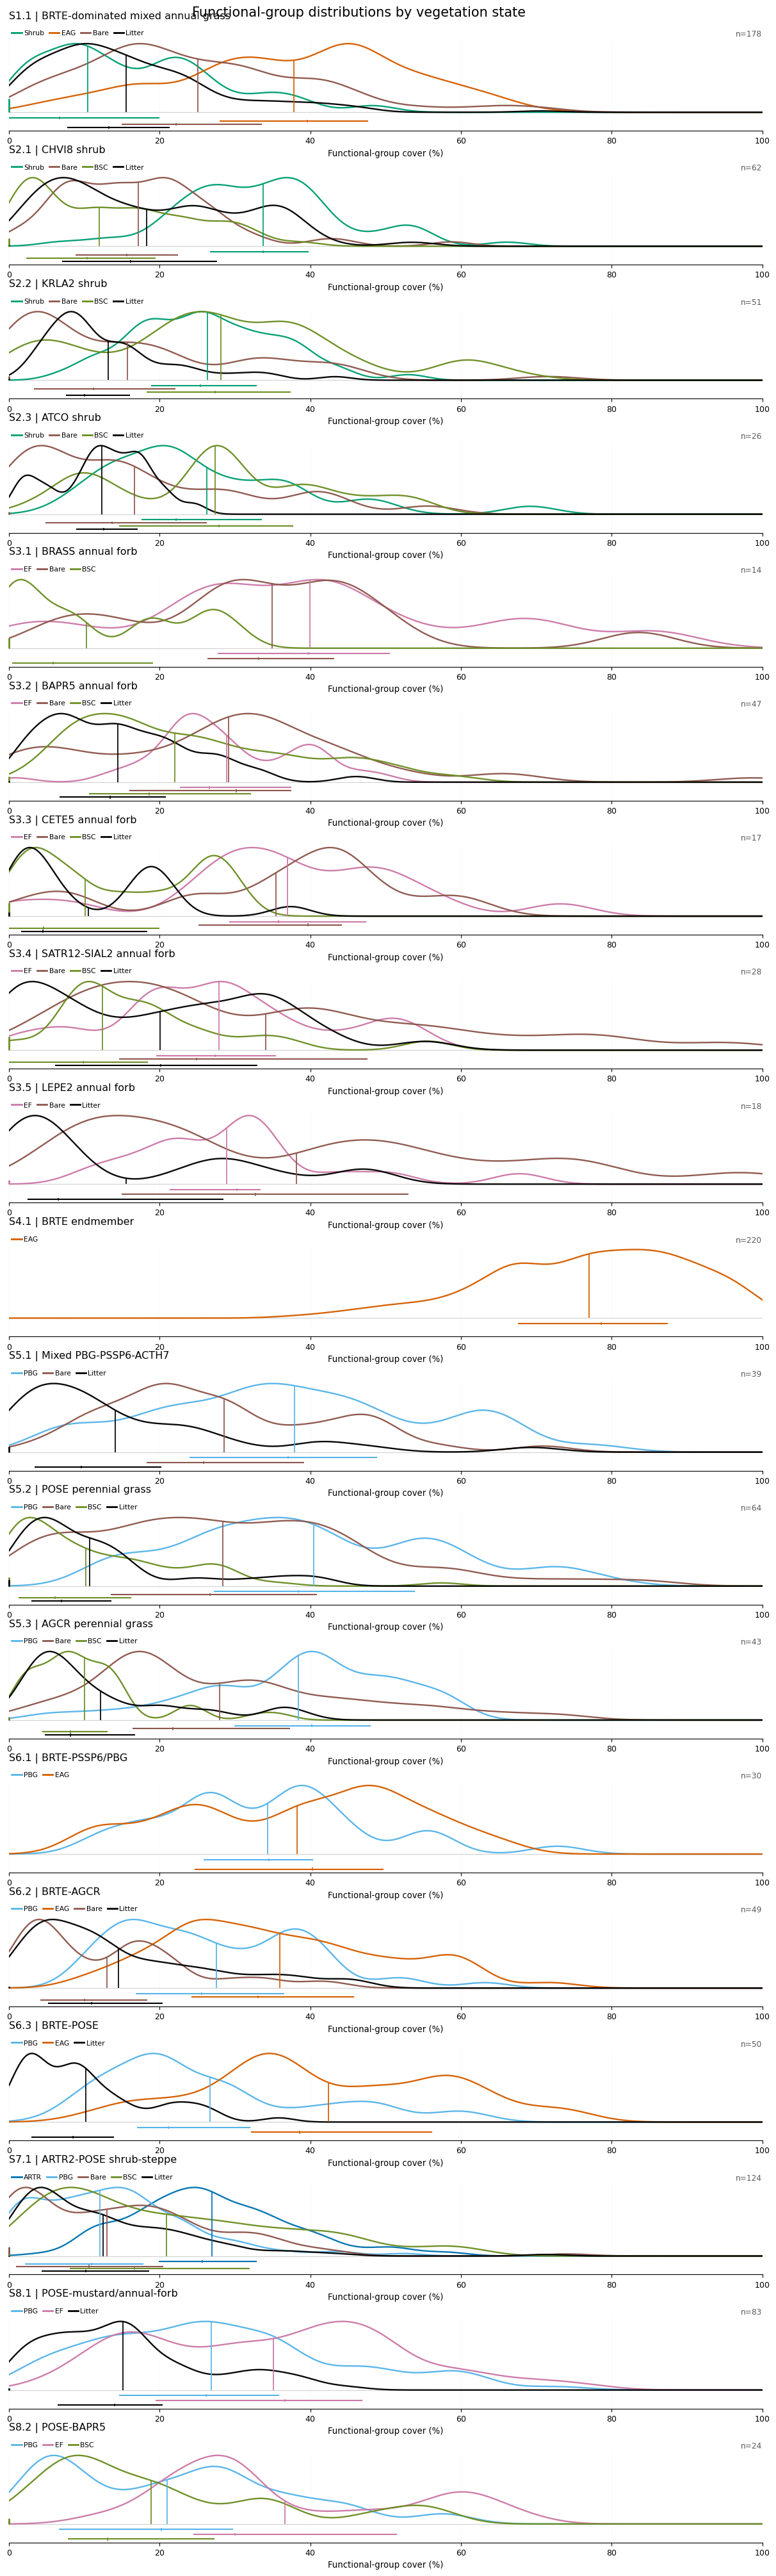

In [56]:
preview_overlaid_tufte_state_densities_singlecol(
    data=veg_states,
    cluster_col="state_id",
    label_col="state_label",
    fg_cols=FG_ALL,
    exclude_nonvegetated=True,
    mean_threshold=10.0,
    bw_method=0.25,
)

In [69]:
# =============================================================================
# PREVIEW ONLY: IQR-CLIPPED HALF-EYE FG DISTRIBUTIONS
# SINGLE-COLUMN, NARROWER VERSION
# Solid line = mean
# Dashed line = median
# Shrub = olive, BSC = green
# NO EXPORT
# =============================================================================

from scipy.stats import gaussian_kde
from matplotlib.patches import Patch


def preview_halfeye_iqr_singlecol(
    data,
    cluster_col,
    label_col,
    fg_cols=None,
    mean_threshold=10.0,
    x_max=100,
    x_ticks=np.arange(0, 101, 20),
    bw_method=0.25,
    show_zero_ticks=True,
    zero_tick_scale=0.18,
    panel_width=10.0,
    panel_height=1.85,
    title="Functional-group distributions",
    sort_key=None,
):
    """
    Draw compact half-eye panels:
      - one panel per cluster/state
      - one half-eye per retained FG
      - density clipped to the IQR [q25, q75]
      - solid vertical line = mean
      - dashed vertical line = median
      - optional zero-mass tick at x = 0
    """

    if fg_cols is None:
        fg_cols = FG_ALL

    fg_pretty = {
        "ARTR_FG": "ARTR",
        "SHRUB_FG": "Shrub",
        "PBG_FG": "PBG",
        "EAG_FG": "EAG",
        "EF_FG": "EF",
        "BAREGROUND_FG": "Bare",
        "BIOCRUST_FG": "BSC",
        "LITTER_FG": "Litter",
        "OTHER_FG": "Other",
        "NPF_FG": "NPF",
    }

    # Updated palette
    fg_colors = {
        "ARTR_FG": "#0072B2",        # blue
        "SHRUB_FG": "#6B8E23",       # olive
        "PBG_FG": "#56B4E9",         # sky blue
        "EAG_FG": "#D55E00",         # vermillion
        "EF_FG": "#CC79A7",          # reddish purple
        "BAREGROUND_FG": "#8C564B",  # brown
        "BIOCRUST_FG": "#009E73",    # green
        "LITTER_FG": "#000000",      # black
        "OTHER_FG": "#666666",
        "NPF_FG": "#444444",
    }

    ids = list(
        data[cluster_col]
        .dropna()
        .unique()
    )

    if sort_key is not None:
        ids = sorted(ids, key=sort_key)
    else:
        ids = sorted(ids)

    n_panels = len(ids)

    fig, axes = plt.subplots(
        nrows=n_panels,
        ncols=1,
        figsize=(
            panel_width,
            panel_height * n_panels + 0.8
        ),
        sharex=True,
        sharey=False,
    )

    axes = np.atleast_1d(axes).ravel()

    xx = np.linspace(
        0.001,
        x_max,
        800
    )

    for ax, gid in zip(axes, ids):

        d = data.loc[
            data[cluster_col] == gid
        ].copy()

        n_group = len(d)

        group_label = (
            d[label_col]
            .dropna()
            .iloc[0]
        )

        # -------------------------------------------------------------
        # Select FGs for display only
        # -------------------------------------------------------------

        fg_means = (
            d[fg_cols]
            .apply(pd.to_numeric, errors="coerce")
            .mean()
        )

        if mean_threshold is None:
            keep_fgs = list(fg_cols)
        else:
            keep_fgs = [
                fg for fg in fg_cols
                if fg_means[fg] > mean_threshold
            ]

        if len(keep_fgs) == 0:
            keep_fgs = [fg_means.idxmax()]

        # -------------------------------------------------------------
        # Vertical layout within each panel
        # -------------------------------------------------------------

        n_show = len(keep_fgs)

        y_positions = (
            np.arange(n_show, 0, -1)
            * 1.0
        )

        # -------------------------------------------------------------
        # Functional-group half-eyes
        # -------------------------------------------------------------

        legend_handles = []

        for fg, y0 in zip(
            keep_fgs,
            y_positions
        ):

            x = (
                pd.to_numeric(
                    d[fg],
                    errors="coerce"
                )
                .dropna()
                .to_numpy(dtype=float)
            )

            if len(x) == 0:
                continue

            color = fg_colors[fg]

            # baseline
            ax.hlines(
                y0,
                0,
                x_max,
                color="0.84",
                linewidth=0.7,
                zorder=0,
            )

            # direct FG label
            ax.text(
                -1.8,
                y0,
                fg_pretty[fg],
                ha="right",
                va="center",
                fontsize=9.5,
                color=color,
                clip_on=False,
            )

            # zero mass
            if show_zero_ticks:
                zero_fraction = np.mean(x == 0)

                if zero_fraction > 0:
                    ax.vlines(
                        0,
                        y0,
                        y0 + min(
                            zero_fraction,
                            zero_tick_scale
                        ),
                        color=color,
                        linewidth=2.0,
                        zorder=4,
                        clip_on=False,
                    )

            positive = x[x > 0]

            # ---------------------------------------------------------
            # Summary statistics from complete observed distribution
            # ---------------------------------------------------------

            q25, median, q75 = np.quantile(
                x,
                [0.25, 0.50, 0.75]
            )

            mean_x = float(np.mean(x))

            # ---------------------------------------------------------
            # KDE over positive-cover observations
            # ---------------------------------------------------------

            if (
                len(positive) >= 5
                and len(np.unique(positive)) >= 3
            ):

                try:
                    kde = gaussian_kde(
                        positive,
                        bw_method=bw_method
                    )

                    yy_raw = kde(xx)

                    if (
                        np.isfinite(yy_raw).all()
                        and yy_raw.max() > 0
                    ):

                        yy = (
                            yy_raw
                            / yy_raw.max()
                        )

                        # ---------------------------------------------
                        # Clip half-eye horizontally to observed IQR
                        # ---------------------------------------------

                        mask = (
                            (xx >= q25)
                            & (xx <= q75)
                        )

                        xx_clip = xx[mask]
                        yy_clip = yy[mask]

                        if len(xx_clip) > 1:

                            ax.fill_between(
                                xx_clip,
                                y0,
                                y0 + yy_clip,
                                facecolor=color,
                                edgecolor="none",
                                alpha=0.22,
                                zorder=2,
                            )

                            ax.plot(
                                xx_clip,
                                y0 + yy_clip,
                                color=color,
                                linewidth=1.35,
                                zorder=3,
                            )

                            # -----------------------------------------
                            # Mean = solid
                            # Median = dashed
                            # -----------------------------------------

                            def height_at(x0):
                                if (
                                    x0 < q25
                                    or x0 > q75
                                ):
                                    return 0.35

                                return float(
                                    np.interp(
                                        x0,
                                        xx_clip,
                                        yy_clip
                                    )
                                )

                            mean_h = height_at(mean_x)
                            median_h = height_at(median)

                            ax.vlines(
                                mean_x,
                                y0,
                                y0 + mean_h,
                                color=color,
                                linewidth=1.45,
                                linestyle="-",
                                zorder=5,
                            )

                            ax.vlines(
                                median,
                                y0,
                                y0 + median_h,
                                color=color,
                                linewidth=1.35,
                                linestyle="--",
                                zorder=5,
                            )

                except np.linalg.LinAlgError:
                    pass

            else:
                # -----------------------------------------------------
                # Fallback when KDE is poorly supported
                # -----------------------------------------------------

                ax.hlines(
                    y0,
                    q25,
                    q75,
                    color=color,
                    linewidth=5,
                    alpha=0.22,
                    zorder=2,
                )

                ax.vlines(
                    mean_x,
                    y0,
                    y0 + 0.35,
                    color=color,
                    linewidth=1.45,
                    linestyle="-",
                    zorder=5,
                )

                ax.vlines(
                    median,
                    y0,
                    y0 + 0.35,
                    color=color,
                    linewidth=1.35,
                    linestyle="--",
                    zorder=5,
                )

            legend_handles.append(
                Patch(
                    facecolor=color,
                    edgecolor=color,
                    alpha=0.22,
                    label=fg_pretty[fg],
                )
            )

        # -------------------------------------------------------------
        # Panel formatting
        # -------------------------------------------------------------

        ax.set_xlim(
            0,
            x_max
        )

        ax.set_xticks(
            x_ticks
        )

        ax.set_xticklabels(
            [
                str(int(v))
                for v in x_ticks
            ],
            fontsize=8.5,
        )

        ax.tick_params(
            axis="x",
            labelbottom=True
        )

        ax.set_ylim(
            0.65,
            y_positions.max() + 1.05
        )

        ax.set_yticks([])

        ax.set_title(
            f"{gid} | {group_label}",
            loc="left",
            fontsize=11.5,
            pad=18,
        )

        ax.text(
            1.0,
            1.02,
            f"n={n_group}",
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=8.8,
            color="0.35",
            clip_on=False,
        )

        ax.legend(
            handles=legend_handles,
            frameon=False,
            loc="lower left",
            bbox_to_anchor=(0.0, 1.01),
            borderaxespad=0,
            ncol=min(
                len(legend_handles),
                5
            ),
            fontsize=7.8,
            handlelength=1.25,
            handletextpad=0.30,
            columnspacing=0.70,
        )

        ax.set_xlabel(
            "Functional-group cover (%)",
            fontsize=9,
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(False)

        ax.grid(
            axis="x",
            linewidth=0.40,
            alpha=0.12,
        )

    # -------------------------------------------------------------
    # Figure formatting
    # -------------------------------------------------------------

    fig.suptitle(
        title,
        fontsize=14,
        y=0.998,
    )

    fig.subplots_adjust(
        top=0.985,
        bottom=0.03,
        left=0.11,
        right=0.98,
        hspace=0.52,
    )

    # PREVIEW ONLY
    plt.show()

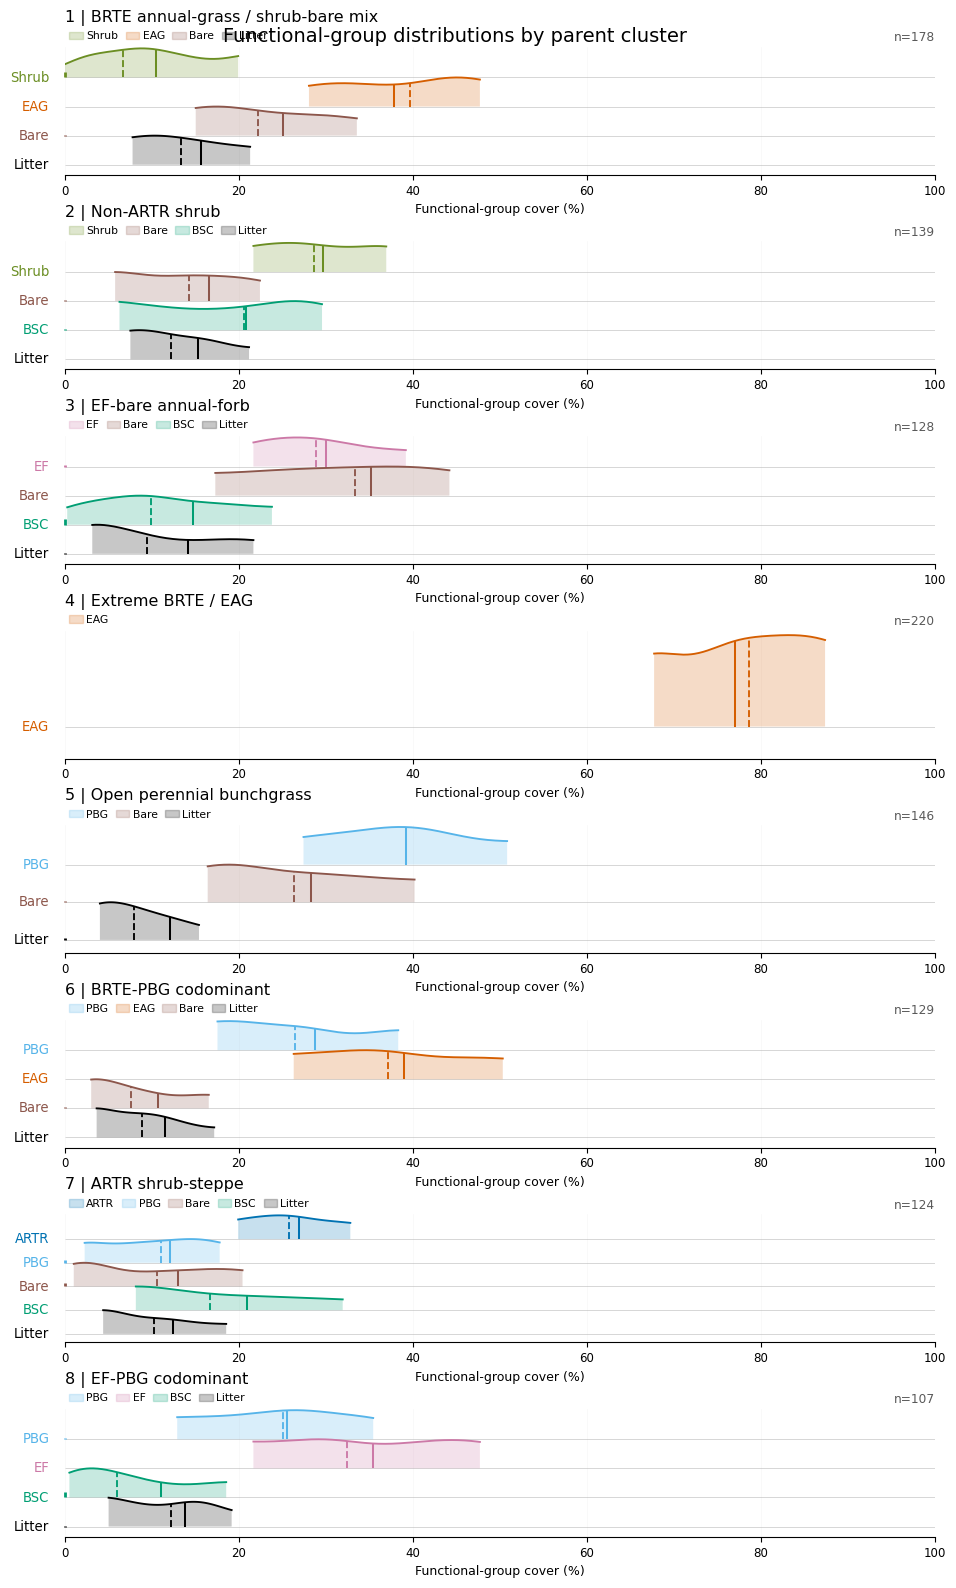

In [70]:
preview_halfeye_iqr_singlecol(
    data=veg_parent,
    cluster_col="parent_cluster",
    label_col="parent_label",
    fg_cols=FG_ALL,
    mean_threshold=10.0,
    bw_method=0.25,
    panel_width=10.0,
    panel_height=1.85,
    title="Functional-group distributions by parent cluster",
)

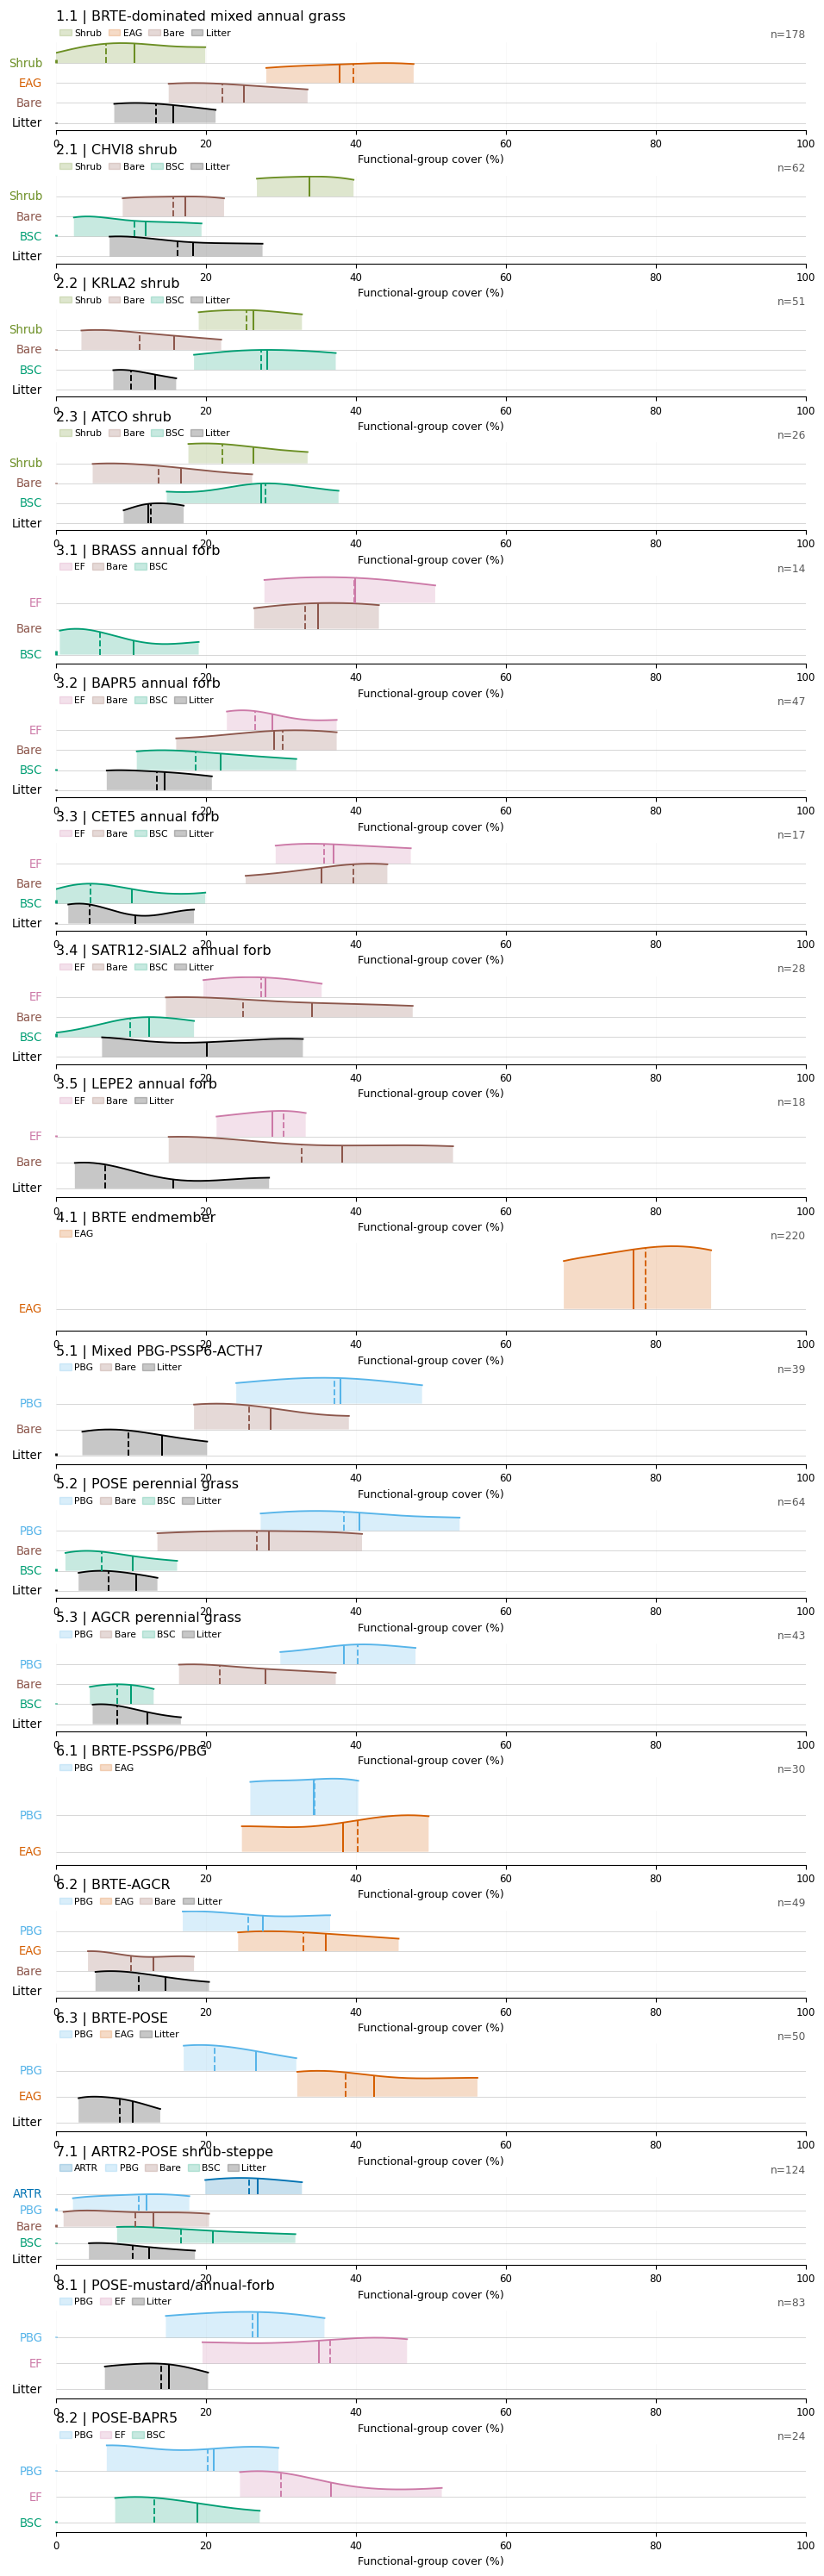

In [74]:
# =============================================================================
# PREVIEW ONLY: IQR-CLIPPED HALF-EYE FG DISTRIBUTIONS
# FINAL VEGETATION STATES / SUBCLUSTERS
# Solid line = mean
# Dashed line = median
# BG excluded
# NO EXPORT
# =============================================================================

def state_sort_key(x):
    if pd.isna(x):
        return (999, 999)

    x = str(x)

    if x == "BG":
        return (999, 999)

    parent, sub = x.split(".")
    return (int(parent), int(sub))


veg_states_plot = veg_states.loc[
    veg_states["state_type"] == "vegetation_state"
].copy()


preview_halfeye_iqr_singlecol(
    data=veg_states_plot,
    cluster_col="state_id",
    label_col="state_label",
    fg_cols=FG_ALL,
    mean_threshold=10.0,
    bw_method=0.4,
    panel_width=10.0,
    panel_height=1.55,
    title=" ",
    sort_key=state_sort_key,
)

In [79]:
# =============================================================================
# PREVIEW ONLY: MONDRIAN COMPOSITION PANELS
#
# Rectangle area = mean FG cover
# White area     = all FG means not displayed (>10% threshold not met)
# Hue            = FG identity only
# Dark inset     = IQR (Q25-Q75)
# Dashed tick    = median
#
# NO EXPORT
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import to_rgb


# -----------------------------------------------------------------------------
# Visual definitions
# -----------------------------------------------------------------------------

MONDRIAN_FGS = [
    "ARTR_FG",
    "SHRUB_FG",
    "PBG_FG",
    "EAG_FG",
    "EF_FG",
    "BAREGROUND_FG",
    "BIOCRUST_FG",
    "LITTER_FG",
]

FG_LABELS_MONDRIAN = {
    "ARTR_FG": "ARTR",
    "SHRUB_FG": "Shrub",
    "PBG_FG": "PBG",
    "EAG_FG": "EAG",
    "EF_FG": "EF",
    "BAREGROUND_FG": "Bare",
    "BIOCRUST_FG": "BSC",
    "LITTER_FG": "Litter",
}

FG_COLORS_MONDRIAN = {
    "ARTR_FG": "#0072B2",        # blue
    "SHRUB_FG": "#6B8E23",       # olive
    "PBG_FG": "#56B4E9",         # sky blue
    "EAG_FG": "#D55E00",         # vermillion
    "EF_FG": "#CC79A7",          # magenta
    "BAREGROUND_FG": "#8C564B",  # brown
    "BIOCRUST_FG": "#009E73",    # green
    "LITTER_FG": "#000000",      # black
}


def blend_with_white(color, amount=0.25):
    rgb = np.array(to_rgb(color))
    return tuple(
        rgb * (1 - amount)
        + np.ones(3) * amount
    )


# -----------------------------------------------------------------------------
# Recursive Mondrian / guillotine partition
# -----------------------------------------------------------------------------

def mondrian_partition(items, x, y, w, h, vertical=True):
    """
    Recursively divide a rectangle.

    items:
        list of dictionaries containing:
        {"name": ..., "weight": ...}

    Rectangle AREA is proportional to weight.
    """

    if len(items) == 1:
        item = items[0].copy()
        item.update({
            "x": x,
            "y": y,
            "w": w,
            "h": h,
        })
        return [item]

    total = sum(item["weight"] for item in items)

    # Find the split closest to half the total weight
    cumulative = np.cumsum([
        item["weight"]
        for item in items
    ])

    split_idx = np.argmin(
        np.abs(cumulative - total / 2)
    ) + 1

    # Prevent an empty side
    split_idx = min(
        max(split_idx, 1),
        len(items) - 1
    )

    left_items = items[:split_idx]
    right_items = items[split_idx:]

    left_weight = sum(
        item["weight"]
        for item in left_items
    )

    fraction = left_weight / total

    if vertical:

        w1 = w * fraction
        w2 = w - w1

        return (
            mondrian_partition(
                left_items,
                x,
                y,
                w1,
                h,
                vertical=False,
            )
            +
            mondrian_partition(
                right_items,
                x + w1,
                y,
                w2,
                h,
                vertical=False,
            )
        )

    else:

        h1 = h * fraction
        h2 = h - h1

        return (
            mondrian_partition(
                left_items,
                x,
                y,
                w,
                h1,
                vertical=True,
            )
            +
            mondrian_partition(
                right_items,
                x,
                y + h1,
                w,
                h2,
                vertical=True,
            )
        )


# -----------------------------------------------------------------------------
# Main plotting function
# -----------------------------------------------------------------------------

def preview_mondrian_clusters(
    data,
    cluster_col,
    label_col,
    fg_cols=MONDRIAN_FGS,
    mean_threshold=10.0,
    sort_key=None,
    ncols=2,
    panel_size=4.6,
    title="Functional-group composition",
):

    cluster_ids = list(
        data[cluster_col]
        .dropna()
        .unique()
    )

    if sort_key is not None:
        cluster_ids = sorted(
            cluster_ids,
            key=sort_key
        )
    else:
        cluster_ids = sorted(cluster_ids)

    n_panels = len(cluster_ids)
    nrows = int(
        np.ceil(n_panels / ncols)
    )

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(
            panel_size * ncols,
            panel_size * nrows
        )
    )

    axes = np.atleast_1d(
        axes
    ).ravel()

    for ax, cluster_id in zip(
        axes,
        cluster_ids
    ):

        d = data.loc[
            data[cluster_col]
            == cluster_id
        ].copy()

        label = (
            d[label_col]
            .dropna()
            .iloc[0]
        )

        n = len(d)

        # -------------------------------------------------------------
        # Calculate FG statistics
        # -------------------------------------------------------------

        stats = {}

        for fg in fg_cols:

            values = (
                pd.to_numeric(
                    d[fg],
                    errors="coerce"
                )
                .dropna()
                .to_numpy(dtype=float)
            )

            if len(values) == 0:
                continue

            stats[fg] = {
                "mean": float(
                    np.mean(values)
                ),
                "median": float(
                    np.median(values)
                ),
                "q25": float(
                    np.quantile(
                        values,
                        0.25
                    )
                ),
                "q75": float(
                    np.quantile(
                        values,
                        0.75
                    )
                ),
            }

        # -------------------------------------------------------------
        # Only major structural FGs receive colored area
        # -------------------------------------------------------------

        retained = [
            fg
            for fg in fg_cols
            if (
                fg in stats
                and stats[fg]["mean"]
                > mean_threshold
            )
        ]

        retained_total = sum(
            stats[fg]["mean"]
            for fg in retained
        )

        # Anything not represented by a >10% FG stays white.
        white_weight = max(
            0.0,
            100.0 - retained_total
        )

        items = [
            {
                "name": fg,
                "weight": stats[fg]["mean"],
            }
            for fg in retained
        ]

        if white_weight > 0:
            items.append({
                "name": "__WHITE__",
                "weight": white_weight,
            })

        # Keep ecological FG order rather than sorting by magnitude.
        # This makes corresponding colors more spatially stable.
        tiles = mondrian_partition(
            items,
            x=0,
            y=0,
            w=1,
            h=1,
            vertical=True,
        )

        # -------------------------------------------------------------
        # Draw Mondrian geometry
        # -------------------------------------------------------------

        for tile in tiles:

            name = tile["name"]

            x0 = tile["x"]
            y0 = tile["y"]
            w = tile["w"]
            h = tile["h"]

            if name == "__WHITE__":

                ax.add_patch(
                    Rectangle(
                        (x0, y0),
                        w,
                        h,
                        facecolor="white",
                        edgecolor="black",
                        linewidth=2.2,
                    )
                )

                continue

            color = FG_COLORS_MONDRIAN[name]
            s = stats[name]

            # ---------------------------------------------------------
            # Primary rectangle
            #
            # AREA = mean cover
            # ---------------------------------------------------------

            ax.add_patch(
                Rectangle(
                    (x0, y0),
                    w,
                    h,
                    facecolor=blend_with_white(
                        color,
                        0.18
                    ),
                    edgecolor="black",
                    linewidth=2.2,
                    zorder=1,
                )
            )

            # ---------------------------------------------------------
            # Distribution ruler inside bottom of each tile
            #
            # Position is on a LOCAL 0-100% scale.
            # Dark segment = IQR.
            # Dashed tick = median.
            # ---------------------------------------------------------

            pad_x = w * 0.08

            ruler_x0 = x0 + pad_x
            ruler_w = w - 2 * pad_x

            # only draw if tile is large enough
            if w > 0.08 and h > 0.08:

                ruler_y = y0 + h * 0.10
                ruler_h = max(
                    h * 0.09,
                    0.012
                )

                # faint full 0-100 track
                ax.add_patch(
                    Rectangle(
                        (
                            ruler_x0,
                            ruler_y
                        ),
                        ruler_w,
                        ruler_h,
                        facecolor=blend_with_white(
                            color,
                            0.60
                        ),
                        edgecolor="none",
                        zorder=2,
                    )
                )

                # IQR segment
                q25_x = (
                    ruler_x0
                    + ruler_w
                    * s["q25"] / 100
                )

                q75_x = (
                    ruler_x0
                    + ruler_w
                    * s["q75"] / 100
                )

                ax.add_patch(
                    Rectangle(
                        (
                            q25_x,
                            ruler_y
                        ),
                        max(
                            q75_x - q25_x,
                            0.002
                        ),
                        ruler_h,
                        facecolor=color,
                        edgecolor="none",
                        zorder=3,
                    )
                )

                # Median
                median_x = (
                    ruler_x0
                    + ruler_w
                    * s["median"] / 100
                )

                ax.vlines(
                    median_x,
                    ruler_y - ruler_h * 0.25,
                    ruler_y + ruler_h * 1.25,
                    color="black",
                    linewidth=1.1,
                    linestyle="--",
                    zorder=4,
                )

            # ---------------------------------------------------------
            # FG label + mean
            # ---------------------------------------------------------

            area = w * h

            if area > 0.055:

                ax.text(
                    x0 + w / 2,
                    y0 + h / 2,
                    (
                        f"{FG_LABELS_MONDRIAN[name]}\n"
                        f"{s['mean']:.0f}%"
                    ),
                    ha="center",
                    va="center",
                    fontsize=9,
                    color=(
                        "white"
                        if name == "LITTER_FG"
                        else "black"
                    ),
                    zorder=5,
                )

        # -------------------------------------------------------------
        # Panel formatting
        # -------------------------------------------------------------

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

        ax.set_aspect(
            "equal",
            adjustable="box"
        )

        ax.set_xticks([])
        ax.set_yticks([])

        for spine in ax.spines.values():
            spine.set_visible(False)

        ax.set_title(
            f"{cluster_id} | {label}",
            loc="left",
            fontsize=11,
            pad=8,
        )

        ax.text(
            1.0,
            1.015,
            f"n={n}",
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=8.5,
            color="0.35",
        )

    # hide unused panels
    for ax in axes[n_panels:]:
        ax.axis("off")

    fig.suptitle(
        title,
        fontsize=15,
        y=0.995,
    )

    fig.subplots_adjust(
        top=0.95,
        bottom=0.03,
        left=0.04,
        right=0.98,
        hspace=0.28,
        wspace=0.20,
    )

    plt.show()

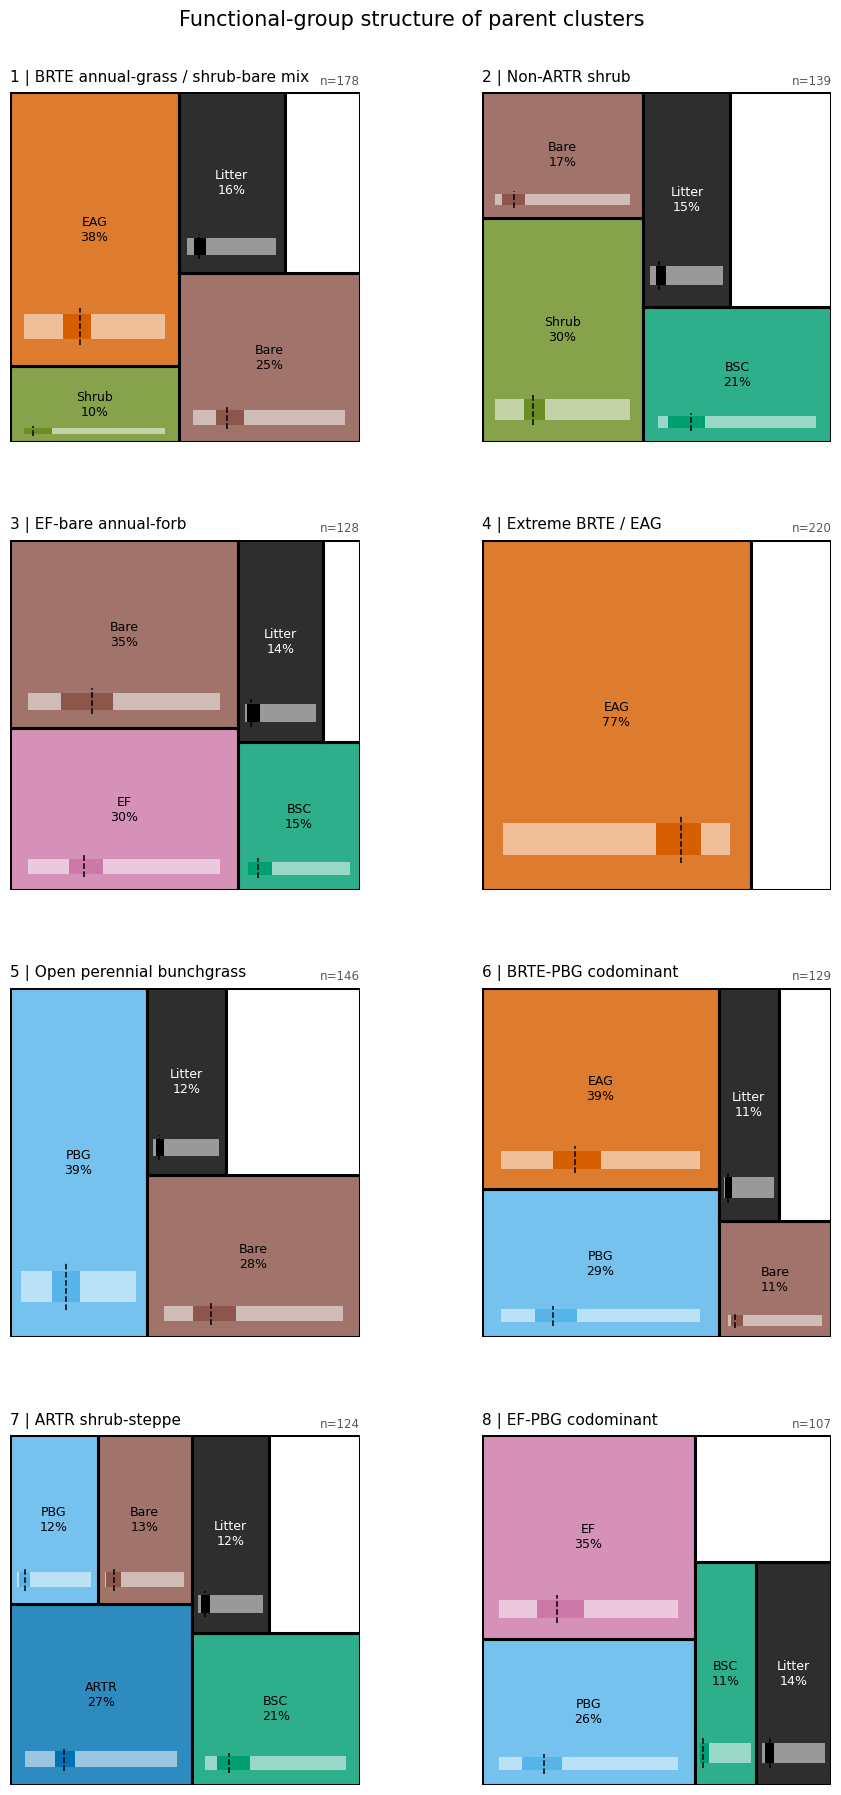

In [80]:
preview_mondrian_clusters(
    data=veg_parent,
    cluster_col="parent_cluster",
    label_col="parent_label",
    fg_cols=MONDRIAN_FGS,
    mean_threshold=10.0,
    ncols=2,
    panel_size=4.6,
    title="Functional-group structure of parent clusters",
)

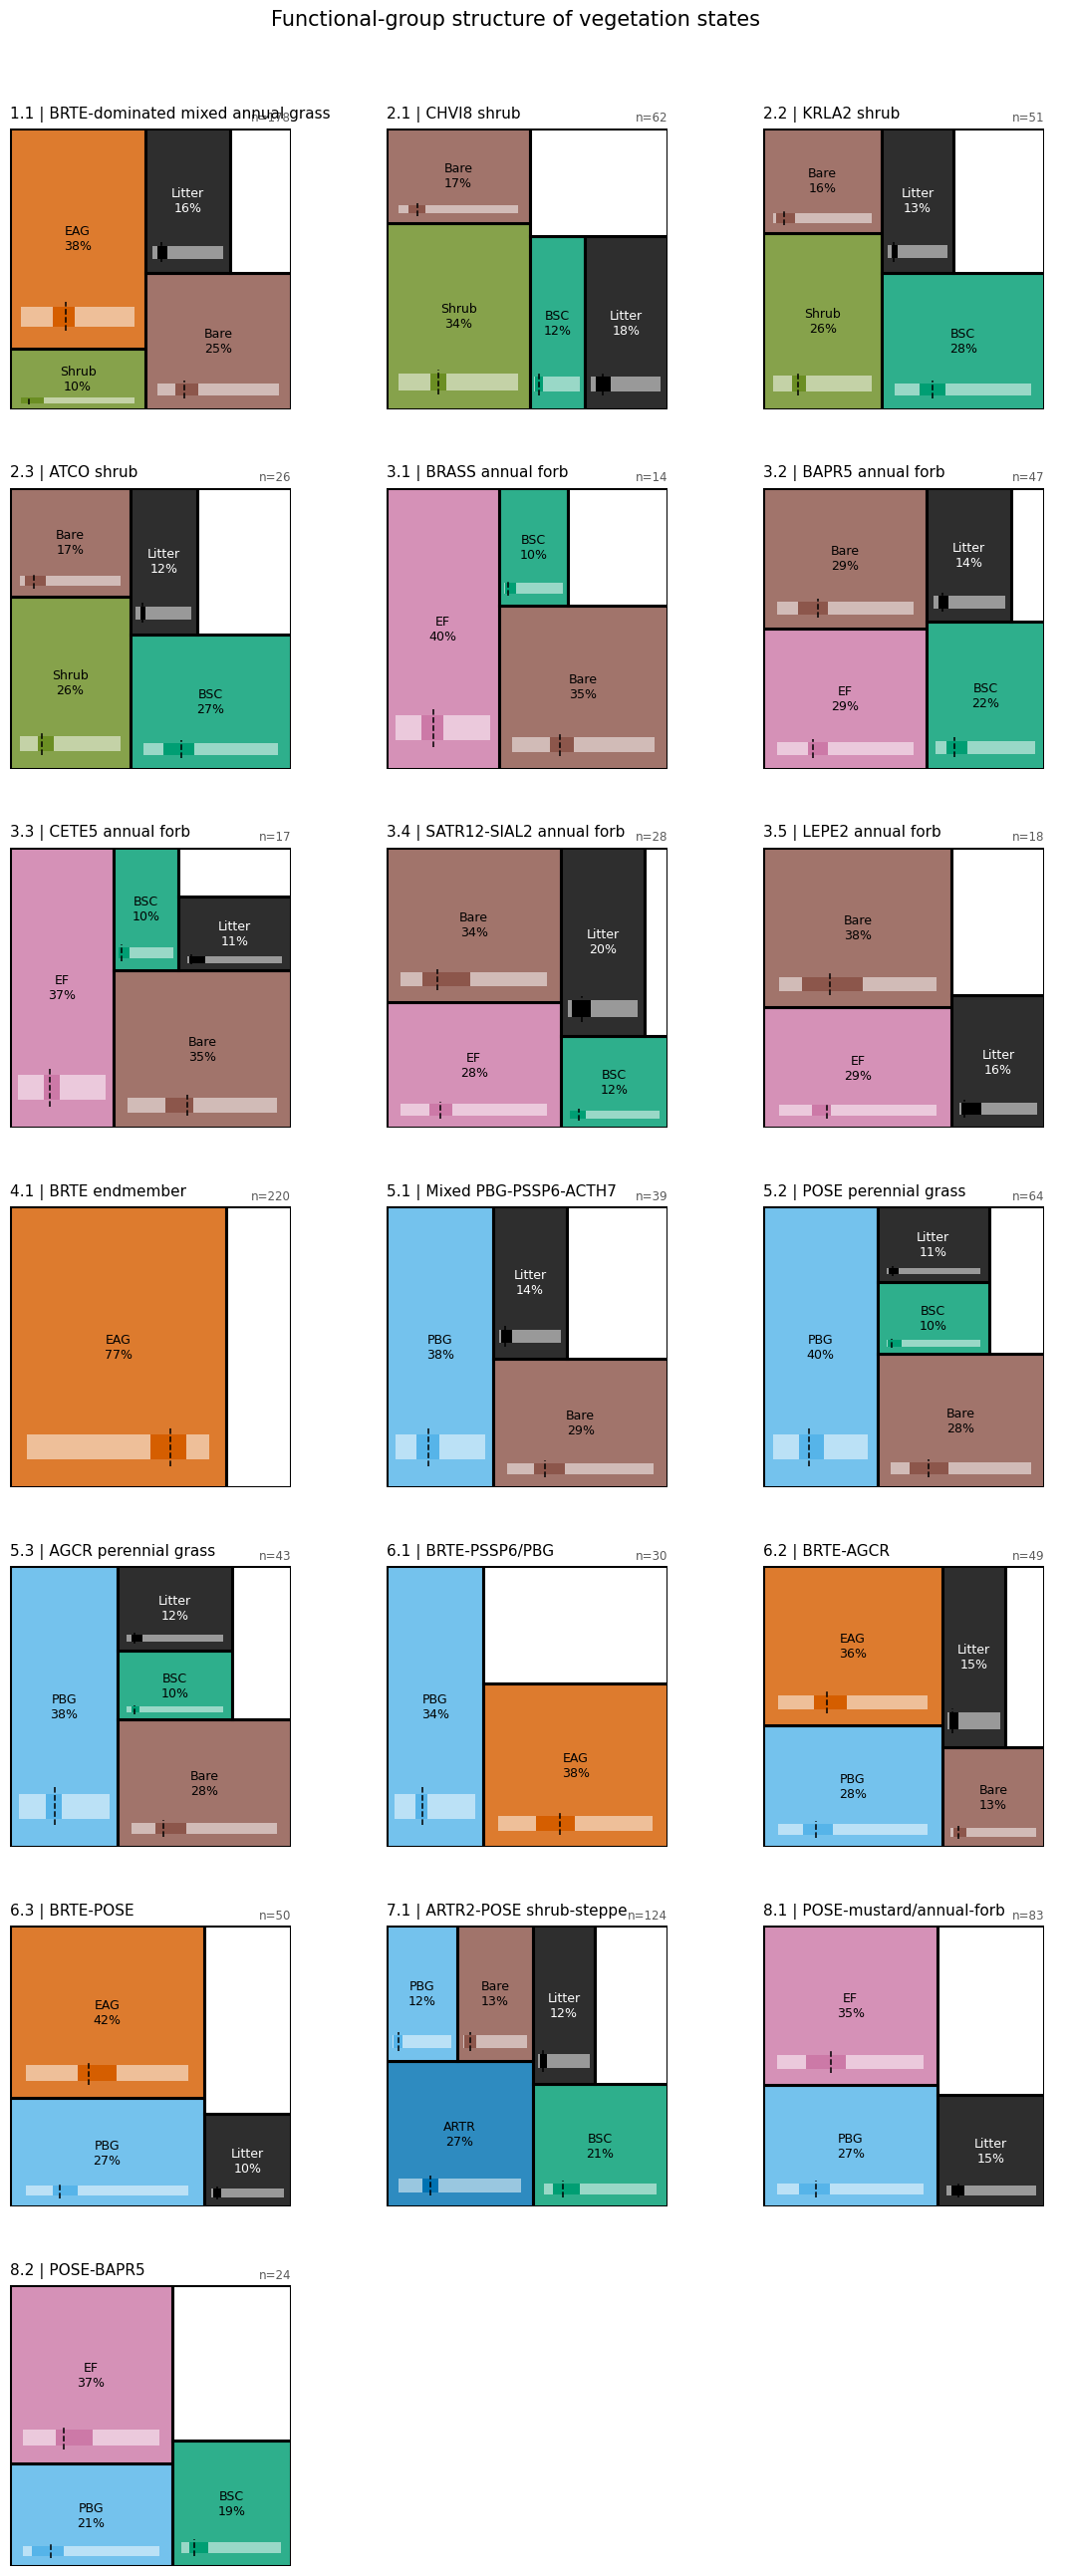

In [81]:
# =============================================================================
# PREVIEW ONLY: MONDRIAN COMPOSITION PANELS
# FINAL VEGETATION STATES / SUBCLUSTERS
#
# Rectangle area = mean FG cover
# White area     = FGs omitted by >10% display threshold
# Hue            = FG identity
# Dark inset     = IQR
# Dashed tick    = median
#
# BG excluded
# NO EXPORT
# =============================================================================

def state_sort_key(x):
    if pd.isna(x):
        return (999, 999)

    x = str(x)

    if x == "BG":
        return (999, 999)

    parent, sub = x.split(".")
    return (int(parent), int(sub))


veg_states_plot = veg_states.loc[
    veg_states["state_type"] == "vegetation_state"
].copy()


preview_mondrian_clusters(
    data=veg_states_plot,
    cluster_col="state_id",
    label_col="state_label",
    fg_cols=MONDRIAN_FGS,
    mean_threshold=10.0,
    sort_key=state_sort_key,
    ncols=3,
    panel_size=3.8,
    title="Functional-group structure of vegetation states",
)

In [84]:
# =============================================================================
# HIERARCHICAL MONDRIAN ATLAS — CLEAN LAYOUT VERSION
#
# Fixes:
# - removes legend
# - removes median/IQR marks inside tiles
# - wraps long child titles
# - improves margins and spacing
# - keeps one large parent panel + smaller child panels on same row
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.patches import Rectangle
import textwrap


# -----------------------------------------------------------------------------
# Display definitions
# -----------------------------------------------------------------------------

MONDRIAN_FGS = [
    "ARTR_FG",
    "SHRUB_FG",
    "PBG_FG",
    "EAG_FG",
    "EF_FG",
    "BAREGROUND_FG",
    "BIOCRUST_FG",
    "LITTER_FG",
]

FG_LABELS_MONDRIAN = {
    "ARTR_FG": "ARTR",
    "SHRUB_FG": "Shrub",
    "PBG_FG": "PBG",
    "EAG_FG": "EAG",
    "EF_FG": "EF",
    "BAREGROUND_FG": "Bare",
    "BIOCRUST_FG": "BSC",
    "LITTER_FG": "Litter",
}

# Okabe-Ito derived / high contrast set
FG_COLORS_MONDRIAN = {
    "ARTR_FG": "#0072B2",        # blue
    "SHRUB_FG": "#6B8E23",       # olive green
    "PBG_FG": "#56B4E9",         # sky blue
    "EAG_FG": "#D55E00",         # vermillion
    "EF_FG": "#CC79A7",          # reddish purple
    "BAREGROUND_FG": "#8C564B",  # brown
    "BIOCRUST_FG": "#009E73",    # bluish green
    "LITTER_FG": "#222222",      # near-black
}


def blend_with_white(color, amount=0.18):
    from matplotlib.colors import to_rgb
    rgb = np.array(to_rgb(color))
    return tuple(rgb * (1 - amount) + np.ones(3) * amount)


# -----------------------------------------------------------------------------
# Recursive Mondrian partition
# -----------------------------------------------------------------------------

def mondrian_partition(items, x, y, w, h, vertical=True):
    """
    Recursively partition a rectangle so area is proportional to item weight.
    """
    if len(items) == 1:
        item = items[0].copy()
        item.update({"x": x, "y": y, "w": w, "h": h})
        return [item]

    total = sum(item["weight"] for item in items)
    cumulative = np.cumsum([item["weight"] for item in items])

    split_idx = np.argmin(np.abs(cumulative - total / 2)) + 1
    split_idx = min(max(split_idx, 1), len(items) - 1)

    first = items[:split_idx]
    second = items[split_idx:]

    first_weight = sum(item["weight"] for item in first)
    frac = first_weight / total if total > 0 else 0.5

    if vertical:
        w1 = w * frac
        return (
            mondrian_partition(first, x, y, w1, h, vertical=False)
            + mondrian_partition(second, x + w1, y, w - w1, h, vertical=False)
        )
    else:
        h1 = h * frac
        return (
            mondrian_partition(first, x, y, w, h1, vertical=True)
            + mondrian_partition(second, x, y + h1, w, h - h1, vertical=True)
        )


# -----------------------------------------------------------------------------
# Draw one Mondrian panel
# -----------------------------------------------------------------------------

def draw_mondrian_panel_clean(
    ax,
    data,
    fg_cols=MONDRIAN_FGS,
    mean_threshold=10.0,
    title="",
    n_value=None,
    child=False,
    title_wrap=None,
):
    if len(data) == 0:
        ax.axis("off")
        return

    # -------------------------------------------------------------------------
    # Summary stats
    # -------------------------------------------------------------------------
    stats = {}

    for fg in fg_cols:
        vals = (
            pd.to_numeric(data[fg], errors="coerce")
            .dropna()
            .to_numpy(dtype=float)
        )
        if len(vals) == 0:
            continue

        stats[fg] = {
            "mean": float(np.mean(vals)),
            "median": float(np.median(vals)),
            "q25": float(np.quantile(vals, 0.25)),
            "q75": float(np.quantile(vals, 0.75)),
        }

    retained = [
        fg for fg in fg_cols
        if fg in stats and stats[fg]["mean"] > mean_threshold
    ]

    retained_total = sum(stats[fg]["mean"] for fg in retained)
    white_weight = max(0.0, 100.0 - retained_total)

    items = [{"name": fg, "weight": stats[fg]["mean"]} for fg in retained]
    if white_weight > 0:
        items.append({"name": "__WHITE__", "weight": white_weight})

    # Sort large to small generally helps label placement/readability
    items = sorted(items, key=lambda d: d["weight"], reverse=True)

    tiles = mondrian_partition(items, x=0, y=0, w=1, h=1, vertical=True)

    # Styling
    border_width = 1.8 if not child else 1.15
    label_fs = 8.0 if not child else 6.2

    # -------------------------------------------------------------------------
    # Draw tiles
    # -------------------------------------------------------------------------
    for tile in tiles:
        name = tile["name"]
        x0, y0, w, h = tile["x"], tile["y"], tile["w"], tile["h"]

        if name == "__WHITE__":
            ax.add_patch(
                Rectangle(
                    (x0, y0), w, h,
                    facecolor="white",
                    edgecolor="black",
                    linewidth=border_width,
                )
            )
            continue

        face = blend_with_white(FG_COLORS_MONDRIAN[name], amount=0.15)

        ax.add_patch(
            Rectangle(
                (x0, y0), w, h,
                facecolor=face,
                edgecolor="black",
                linewidth=border_width,
            )
        )

        # Only label if there is enough room
        area = w * h
        min_area = 0.050 if not child else 0.080

        if area >= min_area:
            txt = f"{FG_LABELS_MONDRIAN[name]}\n{stats[name]['mean']:.0f}%"
            ax.text(
                x0 + w / 2,
                y0 + h / 2,
                txt,
                ha="center",
                va="center",
                fontsize=label_fs,
                color="white" if name == "LITTER_FG" else "black",
                linespacing=0.95,
                clip_on=False,
            )

    # -------------------------------------------------------------------------
    # Panel formatting
    # -------------------------------------------------------------------------
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal", adjustable="box")

    for spine in ax.spines.values():
        spine.set_visible(False)

    # Title wrapping
    title_text = title
    if title_wrap is not None:
        title_text = "\n".join(
            textwrap.wrap(title, width=title_wrap, break_long_words=False)
        )

    title_fs = 12 if not child else 7.6
    ax.set_title(
        title_text,
        loc="left",
        fontsize=title_fs,
        pad=6 if not child else 4,
    )

    # Separate n label
    if n_value is None:
        n_value = len(data)

    ax.text(
        1.0,
        1.03,
        f"n={n_value}",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=8 if not child else 6.4,
        color="0.35",
        clip_on=False,
    )


# -----------------------------------------------------------------------------
# Hierarchical figure
# -----------------------------------------------------------------------------

def preview_hierarchical_mondrian_clean(
    parent_data,
    state_data,
    parent_col="parent_cluster",
    parent_label_col="parent_label",
    state_col="state_id",
    state_label_col="state_label",
    fg_cols=MONDRIAN_FGS,
    mean_threshold=10.0,
    suppress_singletons=True,
):
    """
    One row per parent cluster.
    Left: larger parent panel
    Right: smaller child state panels
    """

    state_plot = state_data.loc[
        state_data["state_type"] == "vegetation_state"
    ].copy()

    parents = sorted(parent_data[parent_col].dropna().unique())

    # Find maximum number of *displayed* child states in any parent
    child_lists = {}
    for p in parents:
        children = (
            state_plot.loc[state_plot["parent_cluster"] == p, state_col]
            .dropna()
            .unique()
            .tolist()
        )
        children = sorted(
            children,
            key=lambda s: tuple(int(v) for v in str(s).split("."))
        )

        if suppress_singletons and len(children) == 1:
            children = []

        child_lists[p] = children

    max_children = max(max(len(v), 1) for v in child_lists.values())

    nrows = len(parents)
    ncols = 1 + max_children

    # Wider page, slightly shorter height than previous version
    fig = plt.figure(figsize=(16, 21))
    gs = fig.add_gridspec(
        nrows=nrows,
        ncols=ncols,
        width_ratios=[1.25] + [0.85] * max_children,
        height_ratios=[1] * nrows,
        wspace=0.28,
        hspace=0.42,
    )

    for r, parent in enumerate(parents):
        parent_subset = parent_data.loc[parent_data[parent_col] == parent].copy()
        parent_label = parent_subset[parent_label_col].dropna().iloc[0]

        # Parent panel
        ax_parent = fig.add_subplot(gs[r, 0])
        draw_mondrian_panel_clean(
            ax_parent,
            parent_subset,
            fg_cols=fg_cols,
            mean_threshold=mean_threshold,
            title=f"P{int(parent)} | {parent_label}",
            n_value=len(parent_subset),
            child=False,
            title_wrap=32,
        )

        # Child panels
        children = child_lists[parent]

        for j in range(max_children):
            ax_child = fig.add_subplot(gs[r, j + 1])

            if j < len(children):
                sid = children[j]
                child_subset = state_plot.loc[state_plot[state_col] == sid].copy()
                child_label = child_subset[state_label_col].dropna().iloc[0]

                draw_mondrian_panel_clean(
                    ax_child,
                    child_subset,
                    fg_cols=fg_cols,
                    mean_threshold=mean_threshold,
                    title=f"{sid} | {child_label}",
                    n_value=len(child_subset),
                    child=True,
                    title_wrap=20,
                )
            else:
                ax_child.axis("off")

    fig.suptitle(
        "Hierarchical functional-group structure",
        fontsize=20,
        y=0.985,
    )

    fig.text(
        0.115, 0.967,
        "Parent cluster",
        ha="center",
        va="bottom",
        fontsize=10,
        color="0.35",
    )

    fig.text(
        0.57, 0.967,
        "Taxonomic vegetation states",
        ha="center",
        va="bottom",
        fontsize=10,
        color="0.35",
    )

    fig.text(
        0.5,
        0.012,
        f"Colored area = mean FG cover for components > {mean_threshold:.0f}%   |   white = remaining composition",
        ha="center",
        fontsize=8.5,
        color="0.35",
    )

    fig.subplots_adjust(
        left=0.08,
        right=0.985,
        top=0.955,
        bottom=0.03,
    )

    plt.show()

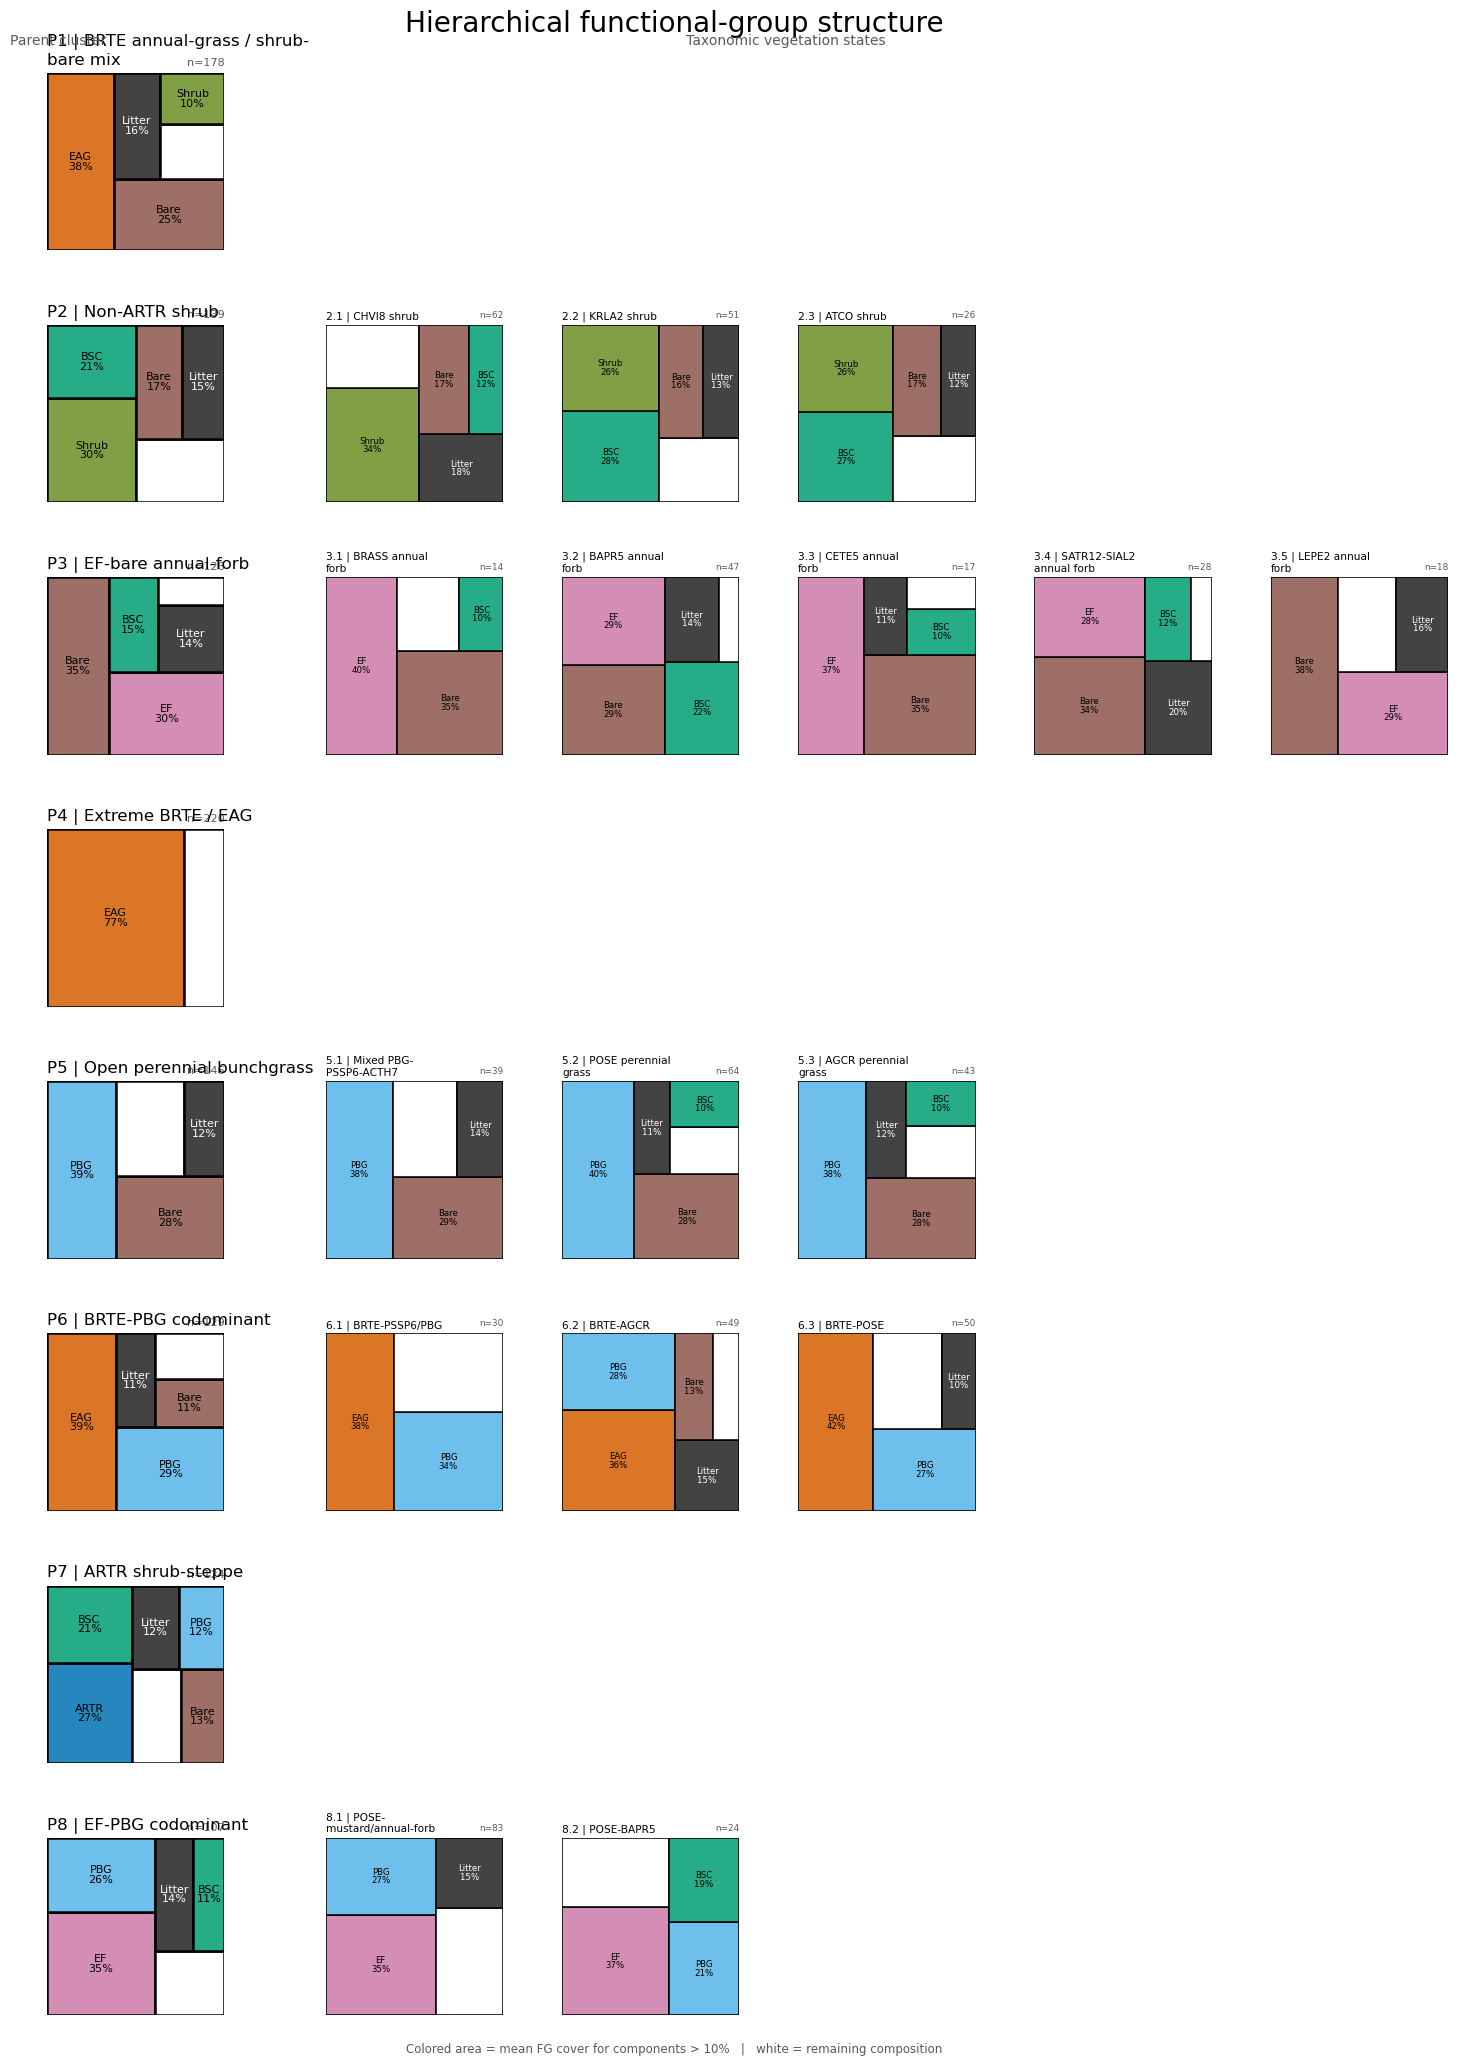

In [85]:
preview_hierarchical_mondrian_clean(
    parent_data=veg_parent,
    state_data=veg_states,
    parent_col="parent_cluster",
    parent_label_col="parent_label",
    state_col="state_id",
    state_label_col="state_label",
    fg_cols=MONDRIAN_FGS,
    mean_threshold=10.0,
    suppress_singletons=True,
)

In [99]:
# =============================================================================
# PREVIEW ONLY: HIERARCHICAL MONDRIAN STRUCTURE
# - parent label rotated 90° on the left side of each parent square
# - n= placed beneath bottom-right corner of EVERY square
# - children kept compact and aligned
# - NO EXPORT
# =============================================================================

import math
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.patches import Rectangle


def draw_mondrian_panel_clean(
    ax,
    data,
    fg_cols=MONDRIAN_FGS,
    mean_threshold=10.0,
    show_fg_names=True,
    tile_fontsize=8.0,
    border_width=1.1,
):
    """Draw a Mondrian-like panel using mean FG cover > threshold."""
    if len(data) == 0:
        ax.axis("off")
        return

    means = {}
    for fg in fg_cols:
        vals = pd.to_numeric(data[fg], errors="coerce").dropna().to_numpy(dtype=float)
        if len(vals):
            means[fg] = float(np.mean(vals))

    retained = [fg for fg in fg_cols if fg in means and means[fg] > mean_threshold]
    retained_total = sum(means[fg] for fg in retained)
    white_weight = max(0.0, 100.0 - retained_total)

    items = [{"name": fg, "weight": means[fg]} for fg in retained]
    if white_weight > 0:
        items.append({"name": "__WHITE__", "weight": white_weight})

    items = sorted(items, key=lambda x: x["weight"], reverse=True)

    tiles = mondrian_partition(
        items,
        x=0,
        y=0,
        w=1,
        h=1,
        vertical=True,
    )

    for tile in tiles:
        name = tile["name"]
        x0, y0, w, h = tile["x"], tile["y"], tile["w"], tile["h"]

        if name == "__WHITE__":
            face = "white"
        else:
            face = blend_with_white(FG_COLORS_MONDRIAN[name], amount=0.10)

        ax.add_patch(
            Rectangle(
                (x0, y0),
                w,
                h,
                facecolor=face,
                edgecolor="black",
                linewidth=border_width,
            )
        )

        if name == "__WHITE__":
            continue

        area = w * h
        min_area = 0.055 if show_fg_names else 0.07
        if area < min_area:
            continue

        if show_fg_names:
            txt = f"{FG_LABELS_MONDRIAN[name]}\n{means[name]:.0f}%"
        else:
            txt = f"{means[name]:.0f}%"

        ax.text(
            x0 + w / 2,
            y0 + h / 2,
            txt,
            ha="center",
            va="center",
            fontsize=tile_fontsize,
            linespacing=0.90,
            color="white" if name == "LITTER_FG" else "black",
        )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal", adjustable="box")

    for spine in ax.spines.values():
        spine.set_visible(False)


def preview_hierarchical_mondrian_rotated_parent_labels(
    parent_data,
    state_data,
    parent_col="parent_cluster",
    parent_label_col="parent_label",
    state_col="state_id",
    state_label_col="state_label",
    fg_cols=MONDRIAN_FGS,
    mean_threshold=10.0,
    suppress_singletons=True,
    figure_width=7.6,
    parent_size=1.30,
    child_scale=0.52,
    parent_child_gap=0.28,
    child_gap=0.14,
    row_gap=0.34,
    label_gutter=0.34,
):
    """
    Parent panels in first column.
    Children aligned to a fixed global child grid.
    Parent labels rotated 90° and placed left of parent square.
    n labels placed below bottom-right of each square.
    """

    state_plot = state_data.loc[state_data["state_type"] == "vegetation_state"].copy()

    parents = sorted(parent_data[parent_col].dropna().unique())

    child_lists = {}
    for parent in parents:
        children = (
            state_plot.loc[state_plot[parent_col] == parent, state_col]
            .dropna()
            .unique()
            .tolist()
        )
        children = sorted(
            children,
            key=lambda s: tuple(int(v) for v in str(s).split("."))
        )
        if suppress_singletons and len(children) == 1:
            children = []
        child_lists[parent] = children

    max_children = max(len(v) for v in child_lists.values()) if child_lists else 0

    child_size = parent_size * child_scale

    # Compact but readable figure geometry in inches
    header_h = 0.55
    footer_h = 0.30
    row_h = max(parent_size, child_size + 0.22) + row_gap
    fig_h = header_h + len(parents) * row_h + footer_h

    fig = plt.figure(figsize=(figure_width, fig_h))

    # Physical positions (inches)
    left_margin = 0.20
    top_margin = 0.42
    bottom_margin = 0.28

    parent_x = left_margin + label_gutter
    child_start_x = parent_x + parent_size + parent_child_gap

    # Title
    fig.suptitle(
        " ",
        fontsize=16,
        y=0.992,
    )
    fig.text(
        0.74,
        0.975,
        " ",
        ha="center",
        va="center",
        fontsize=10,
        color="0.4",
    )

    for row_i, parent in enumerate(parents):
        row_top = top_margin + row_i * row_h
        parent_bottom = fig_h - row_top - parent_size

        parent_subset = parent_data.loc[parent_data[parent_col] == parent].copy()
        parent_label = parent_subset[parent_label_col].dropna().iloc[0]

        # ---------------------------------------------------------------------
        # Parent axis
        # ---------------------------------------------------------------------
        ax_parent = fig.add_axes([
            parent_x / figure_width,
            parent_bottom / fig_h,
            parent_size / figure_width,
            parent_size / fig_h,
        ])

        draw_mondrian_panel_clean(
            ax=ax_parent,
            data=parent_subset,
            fg_cols=fg_cols,
            mean_threshold=mean_threshold,
            show_fg_names=True,
            tile_fontsize=8.0,
            border_width=1.15,
        )

        # Rotated parent label on left side
        parent_text = f"P{int(parent)} | {parent_label}"
        parent_text = "\n".join(
            textwrap.wrap(parent_text, width=22, break_long_words=False)
        )

        fig.text(
            (parent_x - 0.10) / figure_width,
            (parent_bottom + parent_size / 2) / fig_h,
            parent_text,
            ha="center",
            va="center",
            rotation=90,
            fontsize=8.8,
            linespacing=0.95,
        )

        # n below parent panel, bottom-right
        fig.text(
            (parent_x + parent_size) / figure_width,
            (parent_bottom - 0.035) / fig_h,
            f"n={len(parent_subset)}",
            ha="right",
            va="top",
            fontsize=6.6,
            color="0.45",
        )

        # ---------------------------------------------------------------------
        # Children
        # ---------------------------------------------------------------------
        children = child_lists[parent]
        child_bottom = parent_bottom + (parent_size - child_size) / 2

        for child_col, sid in enumerate(children):
            child_subset = state_plot.loc[state_plot[state_col] == sid].copy()
            child_label = child_subset[state_label_col].dropna().iloc[0]

            child_x = child_start_x + child_col * (child_size + child_gap)

            ax_child = fig.add_axes([
                child_x / figure_width,
                child_bottom / fig_h,
                child_size / figure_width,
                child_size / fig_h,
            ])

            draw_mondrian_panel_clean(
                ax=ax_child,
                data=child_subset,
                fg_cols=fg_cols,
                mean_threshold=mean_threshold,
                show_fg_names=False,
                tile_fontsize=5.8,
                border_width=0.9,
            )

            # Child title above square
            child_title = f"{sid} | {child_label}"
            child_title = "\n".join(
                textwrap.wrap(
                    child_title,
                    width=15,
                    break_long_words=False,
                    break_on_hyphens=True,
                )
            )

            fig.text(
                child_x / figure_width,
                (child_bottom + child_size + 0.03) / fig_h,
                child_title,
                ha="left",
                va="bottom",
                fontsize=5.7,
                linespacing=0.92,
            )

            # n below child square, bottom-right
            fig.text(
                (child_x + child_size) / figure_width,
                (child_bottom - 0.028) / fig_h,
                f"n={len(child_subset)}",
                ha="right",
                va="top",
                fontsize=4.8,
                color="0.45",
            )

#    fig.text(
 #       0.5,
  #      0.010,
       # f"Colored area = mean FG cover for components > {mean_threshold:.0f}%  |  white = remaining composition",
   #     ha="center",
     #   fontsize=7,
    #    color="0.4",
   # )

    plt.show()

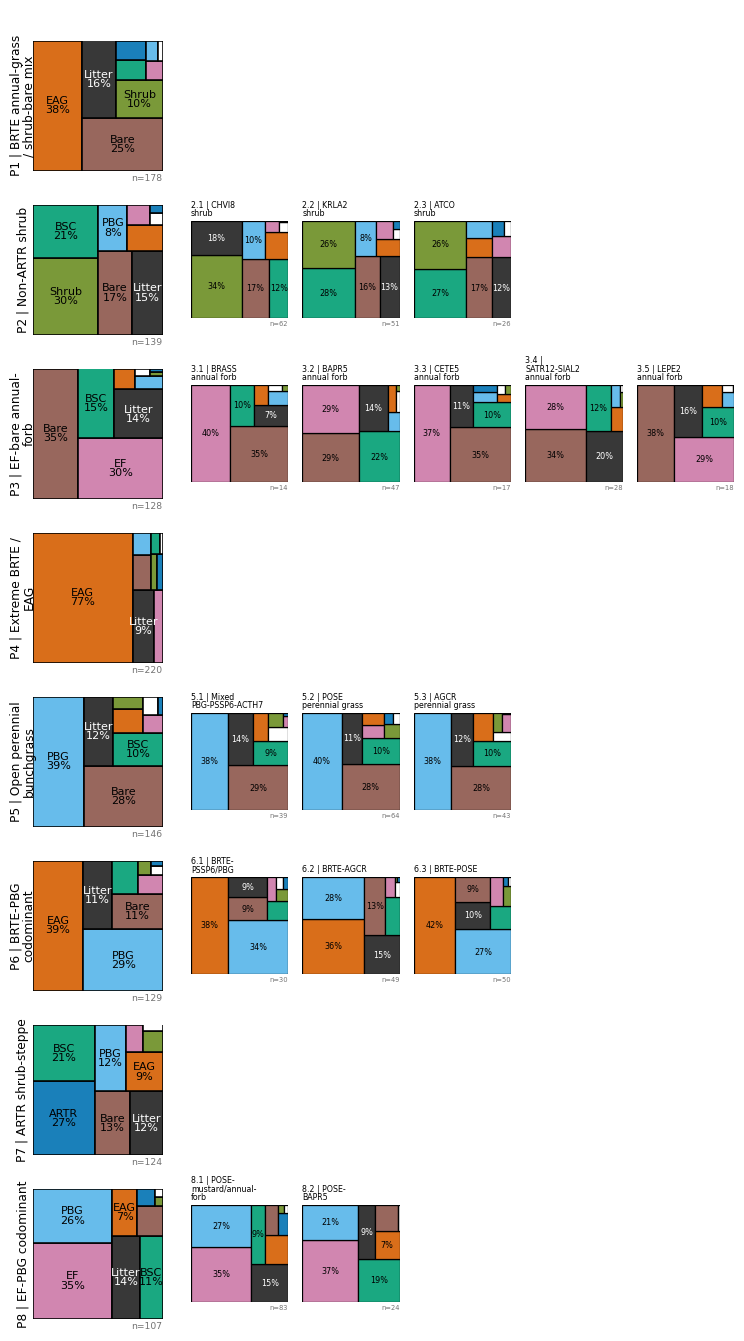

In [102]:
preview_hierarchical_mondrian_rotated_parent_labels(
    parent_data=veg_parent,
    state_data=veg_states,
    parent_col="parent_cluster",
    parent_label_col="parent_label",
    state_col="state_id",
    state_label_col="state_label",
    fg_cols=MONDRIAN_FGS,
    mean_threshold=0,
    suppress_singletons=True,
    figure_width=8,
    parent_size=1.30,
    child_scale=0.75,
    parent_child_gap=0.28,
    child_gap=0.14,
    row_gap=0.34,
    label_gutter=0.34,
)


## Output manifest and reproducibility checks

The final reporting products are written to `Tables`, `Figures`, and `Derived` under `Clustering_Veg`.

The most important QA checks are:

- 1,171 observations in the combined master
- selected parent solution is K=8, m=1.33
- 8 canonical parent clusters
- 19 vegetation states
- the known zero-species observations remain outside the vegetation hierarchy as BG
- Table 2 contains model-defined parent centroids
- Table 3 contains observed final-state FG means


In [103]:

# =============================================================================
# 11. FINAL MANIFEST
# =============================================================================

print("=" * 78)
print("FINAL VEGETATION CLUSTERING REPORT OUTPUTS")
print("=" * 78)

print("\nTABLES")
for p in sorted(TABLE_DIR.glob("*")):
    print(" ", p)

print("\nFIGURES")
for p in sorted(FIG_DIR.glob("*")):
    print(" ", p)

print("\nDERIVED CHECKPOINTS")
for p in sorted(DERIVED_DIR.glob("*")):
    print(" ", p)

print("\nQA")
print(f"  master rows:                {len(master):,}")
print(f"  parent FCM rows:            {len(veg_parent):,}")
print(f"  parent clusters:            {veg_parent['parent_cluster'].nunique()}")
print(f"  reference/core rows:        {int(veg_parent['is_reference'].sum()):,}")
print(
    "  final vegetation states:   "
    f"{veg_states.loc[veg_states['state_type']=='vegetation_state', 'state_id'].nunique()}"
)
print(
    "  BG/nonvegetated rows:       "
    f"{int((veg_states['state_type']=='nonvegetated').sum())}"
)
print(f"  selected best seed:         {parent_fit['seed']}")
print(f"  selected objective:         {parent_fit['objective']:.6f}")


FINAL VEGETATION CLUSTERING REPORT OUTPUTS

TABLES
  C:\NCA_DATA\Vegetation Data\Clustering_Veg\Tables\Table_01_K8_m_sensitivity_1p25_1p40.csv
  C:\NCA_DATA\Vegetation Data\Clustering_Veg\Tables\Table_02_Parent_FG_membership.csv
  C:\NCA_DATA\Vegetation Data\Clustering_Veg\Tables\Table_03_Subcluster_FG_membership.csv

FIGURES
  C:\NCA_DATA\Vegetation Data\Clustering_Veg\Figures\Figure_01_Tufte_Parent_Clusters.pdf
  C:\NCA_DATA\Vegetation Data\Clustering_Veg\Figures\Figure_01_Tufte_Parent_Clusters_page01.png
  C:\NCA_DATA\Vegetation Data\Clustering_Veg\Figures\Figure_02_Tufte_Subclusters.pdf
  C:\NCA_DATA\Vegetation Data\Clustering_Veg\Figures\Figure_02_Tufte_Subclusters_page01.png
  C:\NCA_DATA\Vegetation Data\Clustering_Veg\Figures\Figure_02_Tufte_Subclusters_page02.png
  C:\NCA_DATA\Vegetation Data\Clustering_Veg\Figures\Figure_02_Tufte_Subclusters_page03.png
  C:\NCA_DATA\Vegetation Data\Clustering_Veg\Figures\Figure_02_Tufte_Subclusters_page04.png

DERIVED CHECKPOINTS
  C:\NCA_DATA